### **Data Tables**

In [1]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
category_plan = {
    "Automotive": 55,
    "Tools & Hardware": 60,
    "Outdoor Living": 45,
    "Sports & Recreation": 35,
    "Home Essentials": 45,
    "Seasonal Winter": 30,
    "Seasonal Summer": 30
}

subcategory_map = {
    "Automotive": [
        "Motor Oil", "Car Cleaning", "Battery Accessories", "Winter Accessories",
        "Tire Care", "Wipers", "Floor Mats"
    ],
    "Tools & Hardware": [
        "Hand Tools", "Power Tools", "Fasteners", "Storage", "Paint Supplies",
        "Measuring Tools", "Safety Gear"
    ],
    "Outdoor Living": [
        "BBQ", "Patio Furniture", "Garden Tools", "Outdoor Decor",
        "Lighting", "Planters"
    ],
    "Sports & Recreation": [
        "Fitness", "Cycling", "Camping", "Team Sports", "Winter Sports", "Outdoor Games"
    ],
    "Home Essentials": [
        "Cleaning Supplies", "Kitchen Tools", "Storage & Organization",
        "Laundry", "Bathroom Accessories", "Small Home Items"
    ],
    "Seasonal Winter": [
        "Snow Shovels", "Ice Melt", "Snow Brushes", "Winter Safety", "Heaters"
    ],
    "Seasonal Summer": [
        "Fans", "Coolers", "Water Toys", "Summer Accessories", "Portable Shade"
    ]
}

brand_map = {
    "Automotive": ["MotoMax", "RoadPro", "AutoShield", "TorqueLine"],
    "Tools & Hardware": ["CraftEdge", "SteelCore", "ToolWorks", "PowerForge"],
    "Outdoor Living": ["PatioNova", "GrillMaster", "GardenGlow", "OutdoorEase"],
    "Sports & Recreation": ["ActivePeak", "TrailFlex", "Sportiva", "MotionCore"],
    "Home Essentials": ["HomeNest", "CleanWave", "DailyEase", "UrbanHome"],
    "Seasonal Winter": ["SnowPro", "FrostGuard", "WinterEdge", "ColdCore"],
    "Seasonal Summer": ["SummerFlow", "HeatEase", "CoolBreeze", "SunTrail"]
}

# Category behavior matrix
category_behavior = {
    "Automotive": {
        "seasonality_type": "winter",
        "base_price_range": (8, 120),
        "cost_ratio_range": (0.50, 0.72),
        "base_demand_range": (3, 18),
        "promo_sensitivity_range": (0.8, 1.2),
        "price_sensitivity_range": (0.7, 1.1),
        "weather_sensitivity_range": (1.0, 1.5),
        "seasonality_strength_range": (0.8, 1.3),
        "private_label_prob": 0.20,
        "shelf_space_range": (2, 12)
    },
    "Tools & Hardware": {
        "seasonality_type": "all_season",
        "base_price_range": (5, 250),
        "cost_ratio_range": (0.45, 0.68),
        "base_demand_range": (2, 14),
        "promo_sensitivity_range": (0.6, 1.0),
        "price_sensitivity_range": (0.8, 1.2),
        "weather_sensitivity_range": (0.2, 0.6),
        "seasonality_strength_range": (0.2, 0.6),
        "private_label_prob": 0.15,
        "shelf_space_range": (2, 10)
    },
    "Outdoor Living": {
        "seasonality_type": "summer",
        "base_price_range": (10, 600),
        "cost_ratio_range": (0.48, 0.70),
        "base_demand_range": (1, 10),
        "promo_sensitivity_range": (1.1, 1.6),
        "price_sensitivity_range": (0.9, 1.4),
        "weather_sensitivity_range": (1.1, 1.7),
        "seasonality_strength_range": (1.2, 2.0),
        "private_label_prob": 0.25,
        "shelf_space_range": (3, 20)
    },
    "Sports & Recreation": {
        "seasonality_type": "all_season",
        "base_price_range": (8, 350),
        "cost_ratio_range": (0.45, 0.67),
        "base_demand_range": (1, 9),
        "promo_sensitivity_range": (1.0, 1.5),
        "price_sensitivity_range": (0.8, 1.2),
        "weather_sensitivity_range": (0.6, 1.1),
        "seasonality_strength_range": (0.5, 1.1),
        "private_label_prob": 0.18,
        "shelf_space_range": (2, 14)
    },
    "Home Essentials": {
        "seasonality_type": "all_season",
        "base_price_range": (3, 80),
        "cost_ratio_range": (0.50, 0.75),
        "base_demand_range": (4, 22),
        "promo_sensitivity_range": (0.5, 0.9),
        "price_sensitivity_range": (0.8, 1.1),
        "weather_sensitivity_range": (0.1, 0.3),
        "seasonality_strength_range": (0.1, 0.4),
        "private_label_prob": 0.35,
        "shelf_space_range": (3, 15)
    },
    "Seasonal Winter": {
        "seasonality_type": "winter",
        "base_price_range": (6, 220),
        "cost_ratio_range": (0.48, 0.70),
        "base_demand_range": (1, 8),
        "promo_sensitivity_range": (0.7, 1.1),
        "price_sensitivity_range": (0.5, 0.9),
        "weather_sensitivity_range": (1.4, 2.2),
        "seasonality_strength_range": (1.5, 2.5),
        "private_label_prob": 0.22,
        "shelf_space_range": (2, 16)
    },
    "Seasonal Summer": {
        "seasonality_type": "summer",
        "base_price_range": (5, 180),
        "cost_ratio_range": (0.48, 0.72),
        "base_demand_range": (1, 8),
        "promo_sensitivity_range": (1.0, 1.5),
        "price_sensitivity_range": (0.7, 1.1),
        "weather_sensitivity_range": (1.3, 2.0),
        "seasonality_strength_range": (1.5, 2.4),
        "private_label_prob": 0.20,
        "shelf_space_range": (2, 14)
    }
}

# Optional product adjectives/naming tokens
name_prefixes = [
    "Ultra", "Max", "Pro", "Smart", "Eco", "Heavy-Duty", "Compact",
    "Premium", "Essential", "All-Weather", "Quick", "Deluxe"
]

name_suffixes = [
    "Kit", "Set", "Pack", "Solution", "Series", "Model", "Edition", "Plus"
]

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def random_date(start="2021-01-01", end="2025-06-30"):
    start_ts = pd.Timestamp(start).value // 10**9
    end_ts = pd.Timestamp(end).value // 10**9
    random_ts = np.random.randint(start_ts, end_ts)
    return pd.to_datetime(random_ts, unit="s").date()

def maybe_discontinued(prob=0.07):
    return np.random.rand() < prob

def generate_product_name(category, subcategory, brand):
    use_prefix = np.random.rand() < 0.7
    use_suffix = np.random.rand() < 0.45

    parts = [brand]
    if use_prefix:
        parts.append(np.random.choice(name_prefixes))
    parts.append(subcategory)
    if use_suffix:
        parts.append(np.random.choice(name_suffixes))
    return " ".join(parts)

def sample_float(low, high, decimals=2):
    return round(np.random.uniform(low, high), decimals)

def sample_int(low, high):
    return int(np.random.randint(low, high + 1))

# -----------------------------
# 3. GENERATE PRODUCTS
# -----------------------------
products = []
product_id_counter = 10001

for category, count in category_plan.items():
    behavior = category_behavior[category]

    for _ in range(count):
        subcategory = np.random.choice(subcategory_map[category])
        brand = np.random.choice(brand_map[category])
        product_name = f"{generate_product_name(category, subcategory, brand)} {np.random.randint(100, 999)}"

        base_price = sample_float(*behavior["base_price_range"])
        cost_ratio = sample_float(*behavior["cost_ratio_range"], decimals=3)
        cost = round(base_price * cost_ratio, 2)

        base_daily_demand = sample_float(*behavior["base_demand_range"])
        promo_sensitivity = sample_float(*behavior["promo_sensitivity_range"])
        price_sensitivity = sample_float(*behavior["price_sensitivity_range"])
        weather_sensitivity = sample_float(*behavior["weather_sensitivity_range"])
        seasonality_strength = sample_float(*behavior["seasonality_strength_range"])

        shelf_space_units = sample_int(*behavior["shelf_space_range"])
        is_private_label = np.random.rand() < behavior["private_label_prob"]
        launch_date = random_date()
        discontinue_flag = maybe_discontinued()

        products.append({
            "product_id": product_id_counter,
            "product_name": product_name,
            "category": category,
            "subcategory": subcategory,
            "brand": brand,
            "seasonality_type": behavior["seasonality_type"],
            "base_price": base_price,
            "cost": cost,
            "base_daily_demand": base_daily_demand,
            "promo_sensitivity": promo_sensitivity,
            "price_sensitivity": price_sensitivity,
            "weather_sensitivity": weather_sensitivity,
            "seasonality_strength": seasonality_strength,
            "shelf_space_units": shelf_space_units,
            "is_private_label": is_private_label,
            "launch_date": launch_date,
            "discontinue_flag": discontinue_flag
        })

        product_id_counter += 1

products_df = pd.DataFrame(products)

# -----------------------------
# 4. DATA TYPE CLEANUP
# -----------------------------
products_df["product_id"] = products_df["product_id"].astype("int64")
products_df["product_name"] = products_df["product_name"].astype("string")
products_df["category"] = products_df["category"].astype("string")
products_df["subcategory"] = products_df["subcategory"].astype("string")
products_df["brand"] = products_df["brand"].astype("string")
products_df["seasonality_type"] = products_df["seasonality_type"].astype("string")
products_df["base_price"] = products_df["base_price"].astype("float64")
products_df["cost"] = products_df["cost"].astype("float64")
products_df["base_daily_demand"] = products_df["base_daily_demand"].astype("float64")
products_df["promo_sensitivity"] = products_df["promo_sensitivity"].astype("float64")
products_df["price_sensitivity"] = products_df["price_sensitivity"].astype("float64")
products_df["weather_sensitivity"] = products_df["weather_sensitivity"].astype("float64")
products_df["seasonality_strength"] = products_df["seasonality_strength"].astype("float64")
products_df["shelf_space_units"] = products_df["shelf_space_units"].astype("int64")
products_df["is_private_label"] = products_df["is_private_label"].astype("bool")
products_df["launch_date"] = pd.to_datetime(products_df["launch_date"])
products_df["discontinue_flag"] = products_df["discontinue_flag"].astype("bool")

# -----------------------------
# 5. QUICK VALIDATION
# -----------------------------
print("Products table shape:", products_df.shape)
print("\nCategory counts:")
print(products_df["category"].value_counts())

print("\nSample rows:")
print(products_df.head())

print("\nData types:")
print(products_df.dtypes)

Products table shape: (300, 17)

Category counts:
category
Tools & Hardware       60
Automotive             55
Outdoor Living         45
Home Essentials        45
Sports & Recreation    35
Seasonal Winter        30
Seasonal Summer        30
Name: count, dtype: Int64

Sample rows:
   product_id                                product_name    category  \
0       10001                   TorqueLine Floor Mats 800  Automotive   
1       10002                 TorqueLine Car Cleaning 413  Automotive   
2       10003                AutoShield Max Tire Care 487  Automotive   
3       10004  RoadPro Smart Winter Accessories Model 576  Automotive   
4       10005             RoadPro Essential Tire Care 863  Automotive   

          subcategory       brand seasonality_type  base_price   cost  \
0          Floor Mats  TorqueLine           winter       74.85  44.76   
1        Car Cleaning  TorqueLine           winter       66.77  39.73   
2           Tire Care  AutoShield           winter      113.5

In [2]:
# -----------------------------
# SMALL MODE CONFIG
# -----------------------------
SMALL_MODE = True

N_PRODUCTS = 0.2   # 10%
N_STORES = 0.2    # 10%
#START_DATE = "2024-01-01"
#END_DATE = "2024-06-30"  # 6 months

In [3]:
if SMALL_MODE:
    products_df = products_df.sample(frac=N_PRODUCTS, random_state=42).reset_index(drop=True)

print("Products:", len(products_df))

Products: 60


In [4]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
province_store_plan = {
    "Ontario": 22,
    "Alberta": 10,
    "British Columbia": 9,
    "Quebec": 10,
    "Manitoba": 4,
    "Nova Scotia": 5
}

city_map = {
    "Ontario": ["Toronto", "Ottawa", "Mississauga", "Hamilton", "London"],
    "Alberta": ["Calgary", "Edmonton", "Red Deer"],
    "British Columbia": ["Vancouver", "Burnaby", "Surrey", "Kelowna"],
    "Quebec": ["Montreal", "Quebec City", "Laval"],
    "Manitoba": ["Winnipeg", "Brandon"],
    "Nova Scotia": ["Halifax", "Sydney"]
}

province_region_map = {
    "Ontario": "Central",
    "Alberta": "West",
    "British Columbia": "West",
    "Quebec": "East",
    "Manitoba": "Prairies",
    "Nova Scotia": "Atlantic"
}

trade_area_distribution = {
    "urban": 0.30,
    "suburban": 0.50,
    "rural": 0.20
}

store_format_distribution = {
    "large_format": 0.35,
    "standard": 0.50,
    "urban_small": 0.15
}

banner_options = ["Canadian Tire"]
ownership_options = ["owned", "leased", "dealer"]

# Approximate lat/lon by city
city_geo = {
    "Toronto": (43.6532, -79.3832),
    "Ottawa": (45.4215, -75.6972),
    "Mississauga": (43.5890, -79.6441),
    "Hamilton": (43.2557, -79.8711),
    "London": (42.9849, -81.2453),
    "Calgary": (51.0447, -114.0719),
    "Edmonton": (53.5461, -113.4938),
    "Red Deer": (52.2681, -113.8112),
    "Vancouver": (49.2827, -123.1207),
    "Burnaby": (49.2488, -122.9805),
    "Surrey": (49.1913, -122.8490),
    "Kelowna": (49.8880, -119.4960),
    "Montreal": (45.5017, -73.5673),
    "Quebec City": (46.8139, -71.2080),
    "Laval": (45.6066, -73.7124),
    "Winnipeg": (49.8951, -97.1384),
    "Brandon": (49.8485, -99.9501),
    "Halifax": (44.6488, -63.5752),
    "Sydney": (46.1368, -60.1942)
}

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def weighted_choice(options_dict):
    keys = list(options_dict.keys())
    probs = list(options_dict.values())
    return np.random.choice(keys, p=probs)

def random_opening_date(start="1995-01-01", end="2023-12-31"):
    start_ts = pd.Timestamp(start).value // 10**9
    end_ts = pd.Timestamp(end).value // 10**9
    random_ts = np.random.randint(start_ts, end_ts)
    return pd.to_datetime(random_ts, unit="s").date()

def generate_postal_code():
    letters = list("ABCEGHJKLMNPRSTVXY")
    numbers = list("0123456789")
    return (
        np.random.choice(letters)
        + np.random.choice(numbers)
        + np.random.choice(letters)
        + " "
        + np.random.choice(numbers)
        + np.random.choice(letters)
        + np.random.choice(numbers)
    )

def jitter_geo(lat, lon, max_jitter=0.08):
    return (
        round(lat + np.random.uniform(-max_jitter, max_jitter), 6),
        round(lon + np.random.uniform(-max_jitter, max_jitter), 6)
    )

def store_size_by_format(store_format, trade_area_type):
    if store_format == "large_format":
        if trade_area_type == "urban":
            return int(np.random.randint(55000, 90001))
        elif trade_area_type == "suburban":
            return int(np.random.randint(70000, 120001))
        else:
            return int(np.random.randint(50000, 85001))
    elif store_format == "standard":
        if trade_area_type == "urban":
            return int(np.random.randint(30000, 60001))
        elif trade_area_type == "suburban":
            return int(np.random.randint(40000, 75001))
        else:
            return int(np.random.randint(25000, 55001))
    else:  # urban_small
        return int(np.random.randint(12000, 30001))

def rent_cost_by_store(city, province, trade_area_type, store_size_sqft):
    # base monthly rent per sqft proxy
    high_cost_cities = {"Toronto", "Vancouver", "Montreal"}
    medium_cost_cities = {"Ottawa", "Mississauga", "Burnaby", "Calgary", "Quebec City", "Halifax"}

    if city in high_cost_cities:
        rate = np.random.uniform(2.8, 4.2)
    elif city in medium_cost_cities:
        rate = np.random.uniform(2.0, 3.2)
    else:
        rate = np.random.uniform(1.2, 2.4)

    if trade_area_type == "rural":
        rate *= np.random.uniform(0.75, 0.90)
    elif trade_area_type == "suburban":
        rate *= np.random.uniform(0.90, 1.05)
    else:
        rate *= np.random.uniform(1.00, 1.15)

    monthly_rent = store_size_sqft * rate
    return round(monthly_rent, 2)

def mall_flag_logic(store_format, trade_area_type):
    if store_format == "urban_small":
        return np.random.rand() < 0.45
    if trade_area_type == "urban":
        return np.random.rand() < 0.20
    return np.random.rand() < 0.05

def ownership_type_logic():
    return np.random.choice(ownership_options, p=[0.30, 0.25, 0.45])

# Hidden operational factors to support later projects
def traffic_index(trade_area_type, store_format):
    base = {
        "urban": 1.20,
        "suburban": 1.00,
        "rural": 0.78
    }[trade_area_type]

    format_adj = {
        "large_format": 1.10,
        "standard": 1.00,
        "urban_small": 0.92
    }[store_format]

    return round(base * format_adj * np.random.uniform(0.90, 1.10), 3)

def basket_size_index(trade_area_type):
    base = {
        "urban": 0.90,
        "suburban": 1.12,
        "rural": 1.05
    }[trade_area_type]
    return round(base * np.random.uniform(0.92, 1.08), 3)

def seasonal_affinity_index(trade_area_type):
    base = {
        "urban": 0.82,
        "suburban": 1.18,
        "rural": 1.05
    }[trade_area_type]
    return round(base * np.random.uniform(0.90, 1.10), 3)

def regional_performance_factor(province):
    province_base = {
        "Ontario": 1.06,
        "Alberta": 1.03,
        "British Columbia": 1.02,
        "Quebec": 0.98,
        "Manitoba": 0.95,
        "Nova Scotia": 0.94
    }[province]
    return round(province_base * np.random.uniform(0.92, 1.08), 3)

# -----------------------------
# 3. GENERATE STORES
# -----------------------------
stores = []
store_id_counter = 2001

for province, store_count in province_store_plan.items():
    cities = city_map[province]
    region = province_region_map[province]

    for i in range(store_count):
        city = np.random.choice(cities)
        trade_area_type = weighted_choice(trade_area_distribution)
        store_format = weighted_choice(store_format_distribution)

        # keep urban_small mostly urban/suburban
        if store_format == "urban_small" and trade_area_type == "rural":
            trade_area_type = np.random.choice(["urban", "suburban"], p=[0.7, 0.3])

        # encourage larger formats in suburban/rural
        if trade_area_type == "rural" and store_format == "urban_small":
            store_format = "standard"

        banner = np.random.choice(banner_options)
        store_size_sqft = store_size_by_format(store_format, trade_area_type)
        opening_date = random_opening_date()
        mall_flag = mall_flag_logic(store_format, trade_area_type)
        ownership_type = ownership_type_logic()

        base_lat, base_lon = city_geo[city]
        latitude, longitude = jitter_geo(base_lat, base_lon)

        rent_cost_monthly = rent_cost_by_store(city, province, trade_area_type, store_size_sqft)

        stores.append({
            "store_id": store_id_counter,
            "store_name": f"{banner} {city} Store {i+1}",
            "banner": banner,
            "province": province,
            "city": city,
            "postal_code": generate_postal_code(),
            "region": region,
            "store_format": store_format,
            "store_size_sqft": store_size_sqft,
            "opening_date": opening_date,
            "latitude": latitude,
            "longitude": longitude,
            "trade_area_type": trade_area_type,
            "mall_flag": mall_flag,
            "rent_cost_monthly": rent_cost_monthly,
            "ownership_type": ownership_type,
            # hidden store behavior drivers for later modeling
            "traffic_index": traffic_index(trade_area_type, store_format),
            "basket_size_index": basket_size_index(trade_area_type),
            "seasonal_affinity_index": seasonal_affinity_index(trade_area_type),
            "regional_performance_factor": regional_performance_factor(province)
        })

        store_id_counter += 1

stores_df = pd.DataFrame(stores)

# -----------------------------
# 4. DATA TYPE CLEANUP
# -----------------------------
stores_df["store_id"] = stores_df["store_id"].astype("int64")
stores_df["store_name"] = stores_df["store_name"].astype("string")
stores_df["banner"] = stores_df["banner"].astype("string")
stores_df["province"] = stores_df["province"].astype("string")
stores_df["city"] = stores_df["city"].astype("string")
stores_df["postal_code"] = stores_df["postal_code"].astype("string")
stores_df["region"] = stores_df["region"].astype("string")
stores_df["store_format"] = stores_df["store_format"].astype("string")
stores_df["store_size_sqft"] = stores_df["store_size_sqft"].astype("int64")
stores_df["opening_date"] = pd.to_datetime(stores_df["opening_date"])
stores_df["latitude"] = stores_df["latitude"].astype("float64")
stores_df["longitude"] = stores_df["longitude"].astype("float64")
stores_df["trade_area_type"] = stores_df["trade_area_type"].astype("string")
stores_df["mall_flag"] = stores_df["mall_flag"].astype("bool")
stores_df["rent_cost_monthly"] = stores_df["rent_cost_monthly"].astype("float64")
stores_df["ownership_type"] = stores_df["ownership_type"].astype("string")
stores_df["traffic_index"] = stores_df["traffic_index"].astype("float64")
stores_df["basket_size_index"] = stores_df["basket_size_index"].astype("float64")
stores_df["seasonal_affinity_index"] = stores_df["seasonal_affinity_index"].astype("float64")
stores_df["regional_performance_factor"] = stores_df["regional_performance_factor"].astype("float64")

# -----------------------------
# 5. QUICK VALIDATION
# -----------------------------
print("Stores table shape:", stores_df.shape)

print("\nProvince counts:")
print(stores_df["province"].value_counts())

print("\nTrade area counts:")
print(stores_df["trade_area_type"].value_counts())

print("\nStore format counts:")
print(stores_df["store_format"].value_counts())

print("\nSample rows:")
print(stores_df.head())

print("\nData types:")
print(stores_df.dtypes)

Stores table shape: (60, 20)

Province counts:
province
Ontario             22
Alberta             10
Quebec              10
British Columbia     9
Nova Scotia          5
Manitoba             4
Name: count, dtype: Int64

Trade area counts:
trade_area_type
suburban    36
urban       15
rural        9
Name: count, dtype: Int64

Store format counts:
store_format
standard        36
large_format    15
urban_small      9
Name: count, dtype: Int64

Sample rows:
   store_id                         store_name         banner province  \
0      2001     Canadian Tire Hamilton Store 1  Canadian Tire  Ontario   
1      2002  Canadian Tire Mississauga Store 2  Canadian Tire  Ontario   
2      2003       Canadian Tire Ottawa Store 3  Canadian Tire  Ontario   
3      2004     Canadian Tire Hamilton Store 4  Canadian Tire  Ontario   
4      2005      Canadian Tire Toronto Store 5  Canadian Tire  Ontario   

          city postal_code   region  store_format  store_size_sqft  \
0     Hamilton     B7P 5B4

In [5]:
if SMALL_MODE:
    stores_df = stores_df.sample(frac=N_STORES, random_state=42).reset_index(drop=True)

print("Stores:", len(stores_df))

Stores: 12


In [6]:
# -----------------------------
# 1. CONFIGURATION
# -----------------------------
start_date = "2024-01-01"
end_date = "2025-12-31"

# Approximate Canadian retail-related holidays/events for project purposes
holiday_map = {
    "2024-01-01": "New Year's Day",
    "2024-02-19": "Family Day",
    "2024-03-29": "Good Friday",
    "2024-05-20": "Victoria Day",
    "2024-07-01": "Canada Day",
    "2024-09-02": "Labour Day",
    "2024-10-14": "Thanksgiving",
    "2024-12-25": "Christmas Day",
    "2024-12-26": "Boxing Day",

    "2025-01-01": "New Year's Day",
    "2025-02-17": "Family Day",
    "2025-04-18": "Good Friday",
    "2025-05-19": "Victoria Day",
    "2025-07-01": "Canada Day",
    "2025-09-01": "Labour Day",
    "2025-10-13": "Thanksgiving",
    "2025-12-25": "Christmas Day",
    "2025-12-26": "Boxing Day"
}

# -----------------------------
# 2. CREATE DATE RANGE
# -----------------------------
calendar_df = pd.DataFrame({
    "date": pd.date_range(start=start_date, end=end_date, freq="D")
})

# -----------------------------
# 3. BASIC DATE FEATURES
# -----------------------------
calendar_df["year"] = calendar_df["date"].dt.year
calendar_df["quarter"] = calendar_df["date"].dt.quarter
calendar_df["month"] = calendar_df["date"].dt.month
calendar_df["month_name"] = calendar_df["date"].dt.month_name()
calendar_df["week_of_year"] = calendar_df["date"].dt.isocalendar().week.astype(int)
calendar_df["day_of_week"] = calendar_df["date"].dt.weekday + 1   # Monday=1
calendar_df["day_name"] = calendar_df["date"].dt.day_name()
calendar_df["is_weekend"] = calendar_df["day_of_week"].isin([6, 7])

# -----------------------------
# 4. SEASON MAPPING
# -----------------------------
def assign_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "fall"

calendar_df["season"] = calendar_df["month"].apply(assign_season)

# -----------------------------
# 5. HOLIDAY FLAGS
# -----------------------------
holiday_map_ts = {pd.Timestamp(k): v for k, v in holiday_map.items()}

calendar_df["holiday_name"] = calendar_df["date"].map(holiday_map_ts)
calendar_df["is_holiday"] = calendar_df["holiday_name"].notna()

# -----------------------------
# 6. RETAIL EVENT FLAGS
# -----------------------------
# Black Friday = fourth Friday of November
def get_black_friday(year):
    nov = pd.date_range(start=f"{year}-11-01", end=f"{year}-11-30", freq="D")
    fridays = nov[nov.weekday == 4]
    return fridays[3]  # fourth Friday

black_fridays = [get_black_friday(2024), get_black_friday(2025)]
calendar_df["black_friday_flag"] = calendar_df["date"].isin(black_fridays)

# Boxing Day is already in holiday map, but keep separate flag
calendar_df["boxing_day_flag"] = calendar_df["holiday_name"].eq("Boxing Day")

# Back-to-school period: Aug 15 to Sep 15
calendar_df["back_to_school_flag"] = (
    ((calendar_df["month"] == 8) & (calendar_df["date"].dt.day >= 15)) |
    ((calendar_df["month"] == 9) & (calendar_df["date"].dt.day <= 15))
)

# Spring home improvement season: Apr 1 to Jun 15
calendar_df["spring_home_improvement_flag"] = (
    ((calendar_df["month"] == 4)) |
    ((calendar_df["month"] == 5)) |
    ((calendar_df["month"] == 6) & (calendar_df["date"].dt.day <= 15))
)

# Holiday shopping period: Nov 15 to Dec 24
calendar_df["holiday_shopping_flag"] = (
    ((calendar_df["month"] == 11) & (calendar_df["date"].dt.day >= 15)) |
    ((calendar_df["month"] == 12) & (calendar_df["date"].dt.day <= 24))
)

# -----------------------------
# 7. LONG WEEKEND FLAG
# -----------------------------
holiday_dates = set(calendar_df.loc[calendar_df["is_holiday"], "date"])

def is_long_weekend(row_date):
    weekday = row_date.weekday()  # Monday=0, Sunday=6

    # Friday before Monday holiday
    if weekday == 4 and (row_date + pd.Timedelta(days=3)) in holiday_dates:
        return True
    # Saturday before Monday holiday
    if weekday == 5 and (row_date + pd.Timedelta(days=2)) in holiday_dates:
        return True
    # Sunday before Monday holiday
    if weekday == 6 and (row_date + pd.Timedelta(days=1)) in holiday_dates:
        return True
    # Monday holiday itself
    if row_date in holiday_dates and weekday == 0:
        return True

    return False

calendar_df["long_weekend_flag"] = calendar_df["date"].apply(is_long_weekend)

# -----------------------------
# 8. OPTIONAL HELPER FEATURES
# -----------------------------
calendar_df["is_month_start"] = calendar_df["date"].dt.is_month_start
calendar_df["is_month_end"] = calendar_df["date"].dt.is_month_end

# -----------------------------
# 9. DATA TYPE CLEANUP
# -----------------------------
calendar_df["date"] = pd.to_datetime(calendar_df["date"])
calendar_df["year"] = calendar_df["year"].astype("int64")
calendar_df["quarter"] = calendar_df["quarter"].astype("int64")
calendar_df["month"] = calendar_df["month"].astype("int64")
calendar_df["month_name"] = calendar_df["month_name"].astype("string")
calendar_df["week_of_year"] = calendar_df["week_of_year"].astype("int64")
calendar_df["day_of_week"] = calendar_df["day_of_week"].astype("int64")
calendar_df["day_name"] = calendar_df["day_name"].astype("string")
calendar_df["is_weekend"] = calendar_df["is_weekend"].astype("bool")
calendar_df["season"] = calendar_df["season"].astype("string")
calendar_df["holiday_name"] = calendar_df["holiday_name"].astype("string")
calendar_df["is_holiday"] = calendar_df["is_holiday"].astype("bool")
calendar_df["black_friday_flag"] = calendar_df["black_friday_flag"].astype("bool")
calendar_df["boxing_day_flag"] = calendar_df["boxing_day_flag"].astype("bool")
calendar_df["back_to_school_flag"] = calendar_df["back_to_school_flag"].astype("bool")
calendar_df["spring_home_improvement_flag"] = calendar_df["spring_home_improvement_flag"].astype("bool")
calendar_df["holiday_shopping_flag"] = calendar_df["holiday_shopping_flag"].astype("bool")
calendar_df["long_weekend_flag"] = calendar_df["long_weekend_flag"].astype("bool")
calendar_df["is_month_start"] = calendar_df["is_month_start"].astype("bool")
calendar_df["is_month_end"] = calendar_df["is_month_end"].astype("bool")

# -----------------------------
# 10. QUICK VALIDATION
# -----------------------------
print("Calendar table shape:", calendar_df.shape)

print("\nSample rows:")
print(calendar_df.head(10))

print("\nHoliday rows:")
print(calendar_df.loc[calendar_df["is_holiday"], ["date", "holiday_name"]].head(10))

print("\nBlack Friday rows:")
print(calendar_df.loc[calendar_df["black_friday_flag"], ["date", "black_friday_flag"]])

print("\nData types:")
print(calendar_df.dtypes)

Calendar table shape: (731, 20)

Sample rows:
        date  year  quarter  month month_name  week_of_year  day_of_week  \
0 2024-01-01  2024        1      1    January             1            1   
1 2024-01-02  2024        1      1    January             1            2   
2 2024-01-03  2024        1      1    January             1            3   
3 2024-01-04  2024        1      1    January             1            4   
4 2024-01-05  2024        1      1    January             1            5   
5 2024-01-06  2024        1      1    January             1            6   
6 2024-01-07  2024        1      1    January             1            7   
7 2024-01-08  2024        1      1    January             2            1   
8 2024-01-09  2024        1      1    January             2            2   
9 2024-01-10  2024        1      1    January             2            3   

    day_name  is_weekend  season    holiday_name  is_holiday  \
0     Monday       False  winter  New Year's Day     

In [7]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. CITY / CLIMATE CONFIG
# -----------------------------
city_climate_profiles = {
    "Toronto": {"province": "Ontario", "temp_offset": 0.0, "snow_factor": 0.8, "rain_factor": 1.0},
    "Ottawa": {"province": "Ontario", "temp_offset": -2.0, "snow_factor": 1.3, "rain_factor": 0.9},
    "Mississauga": {"province": "Ontario", "temp_offset": 0.2, "snow_factor": 0.7, "rain_factor": 1.0},
    "Hamilton": {"province": "Ontario", "temp_offset": 0.4, "snow_factor": 0.7, "rain_factor": 1.0},
    "London": {"province": "Ontario", "temp_offset": -0.3, "snow_factor": 1.0, "rain_factor": 1.0},

    "Calgary": {"province": "Alberta", "temp_offset": -2.5, "snow_factor": 1.2, "rain_factor": 0.7},
    "Edmonton": {"province": "Alberta", "temp_offset": -3.5, "snow_factor": 1.4, "rain_factor": 0.7},
    "Red Deer": {"province": "Alberta", "temp_offset": -3.0, "snow_factor": 1.3, "rain_factor": 0.7},

    "Vancouver": {"province": "British Columbia", "temp_offset": 2.0, "snow_factor": 0.2, "rain_factor": 1.6},
    "Burnaby": {"province": "British Columbia", "temp_offset": 1.8, "snow_factor": 0.2, "rain_factor": 1.5},
    "Surrey": {"province": "British Columbia", "temp_offset": 1.7, "snow_factor": 0.2, "rain_factor": 1.5},
    "Kelowna": {"province": "British Columbia", "temp_offset": 0.8, "snow_factor": 0.8, "rain_factor": 0.9},

    "Montreal": {"province": "Quebec", "temp_offset": -1.0, "snow_factor": 1.2, "rain_factor": 1.0},
    "Quebec City": {"province": "Quebec", "temp_offset": -2.2, "snow_factor": 1.5, "rain_factor": 0.9},
    "Laval": {"province": "Quebec", "temp_offset": -1.0, "snow_factor": 1.2, "rain_factor": 1.0},

    "Winnipeg": {"province": "Manitoba", "temp_offset": -4.5, "snow_factor": 1.5, "rain_factor": 0.8},
    "Brandon": {"province": "Manitoba", "temp_offset": -4.2, "snow_factor": 1.4, "rain_factor": 0.8},

    "Halifax": {"province": "Nova Scotia", "temp_offset": 0.3, "snow_factor": 0.9, "rain_factor": 1.2},
    "Sydney": {"province": "Nova Scotia", "temp_offset": -0.2, "snow_factor": 1.0, "rain_factor": 1.2}
}

# Use cities that appear in the stores dataset
cities_in_use = sorted(stores_df["city"].dropna().unique().tolist())

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def seasonal_temp_baseline(day_of_year):
    """
    Smooth annual temperature curve.
    Peak in summer, lowest in winter.
    """
    return 10 + 15 * np.sin(2 * np.pi * (day_of_year - 172) / 365.25)

def seasonal_rain_baseline(month):
    """
    Mild monthly rainfall pattern.
    """
    if month in [11, 12, 1, 2]:
        return 2.5
    elif month in [3, 4, 5]:
        return 2.0
    elif month in [6, 7, 8]:
        return 1.8
    else:
        return 2.2

def classify_weather(avg_temp, snowfall_cm, rainfall_mm, storm_flag):
    if storm_flag and snowfall_cm > 3:
        return "snowstorm"
    if storm_flag and rainfall_mm > 10:
        return "rainstorm"
    if snowfall_cm > 1:
        return "snow"
    if rainfall_mm > 5:
        return "rain"
    if avg_temp >= 28:
        return "hot"
    if avg_temp <= -10:
        return "extreme_cold"
    if rainfall_mm > 0.5:
        return "cloudy_rain_mix"
    return "clear"

# -----------------------------
# 3. GENERATE WEATHER
# -----------------------------
weather_rows = []

for _, row in calendar_df.iterrows():
    current_date = row["date"]
    day_of_year = current_date.dayofyear
    month = current_date.month

    for city in cities_in_use:
        profile = city_climate_profiles[city]
        province = profile["province"]

        # Temperature generation
        base_temp = seasonal_temp_baseline(day_of_year)
        avg_temp = base_temp + profile["temp_offset"] + np.random.normal(0, 4)

        # Min / max temperatures
        min_temp = avg_temp - np.random.uniform(2, 8)
        max_temp = avg_temp + np.random.uniform(2, 8)

        # Snowfall generation
        snowfall_cm = 0.0
        if avg_temp <= 1:
            snowfall_cm = max(
                0,
                np.random.gamma(shape=1.5, scale=1.5) * profile["snow_factor"] - np.random.uniform(0, 1.0)
            )

        # Rainfall generation
        rain_base = seasonal_rain_baseline(month) * profile["rain_factor"]
        rainfall_mm = max(0, np.random.gamma(shape=1.2, scale=rain_base / 1.5) - np.random.uniform(0, 1.0))

        # Keep rain low when strong snow day
        if snowfall_cm > 2:
            rainfall_mm *= np.random.uniform(0.0, 0.3)

        # Storm flag
        storm_flag = (snowfall_cm > 8) or (rainfall_mm > 18)

        # Heatwave flag
        heatwave_flag = avg_temp >= 30

        weather_condition = classify_weather(avg_temp, snowfall_cm, rainfall_mm, storm_flag)

        weather_rows.append({
            "weather_date": current_date,
            "province": province,
            "city": city,
            "avg_temperature_c": round(avg_temp, 1),
            "min_temperature_c": round(min_temp, 1),
            "max_temperature_c": round(max_temp, 1),
            "snowfall_cm": round(snowfall_cm, 1),
            "rainfall_mm": round(rainfall_mm, 1),
            "weather_condition": weather_condition,
            "storm_flag": storm_flag,
            "heatwave_flag": heatwave_flag
        })

weather_df = pd.DataFrame(weather_rows)

# -----------------------------
# 4. DATA TYPE CLEANUP
# -----------------------------
weather_df["weather_date"] = pd.to_datetime(weather_df["weather_date"])
weather_df["province"] = weather_df["province"].astype("string")
weather_df["city"] = weather_df["city"].astype("string")
weather_df["avg_temperature_c"] = weather_df["avg_temperature_c"].astype("float64")
weather_df["min_temperature_c"] = weather_df["min_temperature_c"].astype("float64")
weather_df["max_temperature_c"] = weather_df["max_temperature_c"].astype("float64")
weather_df["snowfall_cm"] = weather_df["snowfall_cm"].astype("float64")
weather_df["rainfall_mm"] = weather_df["rainfall_mm"].astype("float64")
weather_df["weather_condition"] = weather_df["weather_condition"].astype("string")
weather_df["storm_flag"] = weather_df["storm_flag"].astype("bool")
weather_df["heatwave_flag"] = weather_df["heatwave_flag"].astype("bool")

# -----------------------------
# 5. QUICK VALIDATION
# -----------------------------
print("Weather table shape:", weather_df.shape)

print("\nSample rows:")
print(weather_df.head(10))

print("\nWeather condition counts:")
print(weather_df["weather_condition"].value_counts())

print("\nAverage temperature by city:")
print(weather_df.groupby("city")["avg_temperature_c"].mean().sort_values())

print("\nData types:")
print(weather_df.dtypes)

Weather table shape: (7310, 11)

Sample rows:
  weather_date          province         city  avg_temperature_c  \
0   2024-01-01          Manitoba      Brandon                4.8   
1   2024-01-01       Nova Scotia      Halifax               13.6   
2   2024-01-01           Ontario     Hamilton                5.6   
3   2024-01-01            Quebec        Laval                2.0   
4   2024-01-01           Ontario       London                7.0   
5   2024-01-01           Ontario  Mississauga                4.8   
6   2024-01-01            Quebec     Montreal                9.3   
7   2024-01-01           Ontario       Ottawa                8.0   
8   2024-01-01            Quebec  Quebec City               -1.1   
9   2024-01-01  British Columbia    Vancouver                7.5   

   min_temperature_c  max_temperature_c  snowfall_cm  rainfall_mm  \
0               -1.6               10.4          0.0          0.8   
1               11.5               21.5          0.0          3.4  

In [8]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. HELPER FUNCTIONS
# -----------------------------
def clipped_normal(mean, std, low, high, decimals=3):
    value = np.random.normal(mean, std)
    value = np.clip(value, low, high)
    return round(value, decimals)

def clipped_int_normal(mean, std, low, high):
    value = int(round(np.random.normal(mean, std)))
    return int(np.clip(value, low, high))

def generate_demographics_for_store(store_row):
    trade_area = store_row["trade_area_type"]
    province = store_row["province"]
    city = store_row["city"]

    # Province-level light adjustment factors
    province_income_factor = {
        "Ontario": 1.08,
        "Alberta": 1.10,
        "British Columbia": 1.07,
        "Quebec": 0.96,
        "Manitoba": 0.93,
        "Nova Scotia": 0.91
    }.get(province, 1.0)

    province_competition_factor = {
        "Ontario": 1.10,
        "Alberta": 0.95,
        "British Columbia": 1.00,
        "Quebec": 0.92,
        "Manitoba": 0.85,
        "Nova Scotia": 0.80
    }.get(province, 1.0)

    # Trade-area-specific baselines
    if trade_area == "urban":
        median_household_income = clipped_int_normal(82000 * province_income_factor, 12000, 50000, 150000)
        population_density = clipped_int_normal(4200, 1800, 800, 9000)
        avg_household_size = clipped_normal(2.3, 0.35, 1.7, 3.4, decimals=2)
        homeownership_rate = clipped_normal(0.46, 0.10, 0.20, 0.72)
        family_with_children_pct = clipped_normal(0.26, 0.08, 0.10, 0.50)
        age_25_44_pct = clipped_normal(0.34, 0.06, 0.18, 0.50)
        age_45_64_pct = clipped_normal(0.24, 0.05, 0.12, 0.40)
        vehicle_ownership_rate = clipped_normal(0.68, 0.10, 0.35, 0.90)
        competitor_store_count = clipped_int_normal(8 * province_competition_factor, 3, 2, 18)
        nearby_big_box_count = clipped_int_normal(4, 2, 0, 10)

    elif trade_area == "suburban":
        median_household_income = clipped_int_normal(98000 * province_income_factor, 14000, 60000, 170000)
        population_density = clipped_int_normal(1800, 700, 300, 4500)
        avg_household_size = clipped_normal(2.9, 0.35, 2.1, 4.2, decimals=2)
        homeownership_rate = clipped_normal(0.68, 0.10, 0.40, 0.90)
        family_with_children_pct = clipped_normal(0.39, 0.08, 0.18, 0.62)
        age_25_44_pct = clipped_normal(0.29, 0.05, 0.16, 0.44)
        age_45_64_pct = clipped_normal(0.28, 0.05, 0.14, 0.42)
        vehicle_ownership_rate = clipped_normal(0.90, 0.06, 0.70, 0.99)
        competitor_store_count = clipped_int_normal(5 * province_competition_factor, 2, 1, 12)
        nearby_big_box_count = clipped_int_normal(3, 2, 0, 8)

    else:  # rural
        median_household_income = clipped_int_normal(76000 * province_income_factor, 12000, 45000, 130000)
        population_density = clipped_int_normal(180, 120, 20, 800)
        avg_household_size = clipped_normal(2.6, 0.35, 1.9, 3.8, decimals=2)
        homeownership_rate = clipped_normal(0.74, 0.09, 0.50, 0.93)
        family_with_children_pct = clipped_normal(0.33, 0.07, 0.16, 0.55)
        age_25_44_pct = clipped_normal(0.23, 0.05, 0.10, 0.38)
        age_45_64_pct = clipped_normal(0.31, 0.05, 0.18, 0.46)
        vehicle_ownership_rate = clipped_normal(0.95, 0.04, 0.80, 1.00)
        competitor_store_count = clipped_int_normal(2 * province_competition_factor, 1, 0, 6)
        nearby_big_box_count = clipped_int_normal(1, 1, 0, 3)

    # Small city-specific realism tweaks
    if city in ["Toronto", "Vancouver", "Montreal"]:
        population_density = int(population_density * np.random.uniform(1.10, 1.35))
        competitor_store_count = min(20, competitor_store_count + np.random.randint(1, 4))
        homeownership_rate = round(max(0.15, homeownership_rate - np.random.uniform(0.03, 0.08)), 3)

    if city in ["Calgary", "Edmonton"]:
        vehicle_ownership_rate = round(min(1.00, vehicle_ownership_rate + np.random.uniform(0.01, 0.04)), 3)

    if city in ["Halifax", "Sydney", "Brandon"]:
        competitor_store_count = max(0, competitor_store_count - np.random.randint(0, 2))

    # Derived helper indices for later modeling
    income_index = round(median_household_income / 90000, 3)
    competition_index = round(1 / (1 + competitor_store_count), 3)

    return {
        "store_id": store_row["store_id"],
        "median_household_income": float(median_household_income),
        "population_density": float(population_density),
        "avg_household_size": float(avg_household_size),
        "homeownership_rate": float(homeownership_rate),
        "family_with_children_pct": float(family_with_children_pct),
        "age_25_44_pct": float(age_25_44_pct),
        "age_45_64_pct": float(age_45_64_pct),
        "vehicle_ownership_rate": float(vehicle_ownership_rate),
        "competitor_store_count": int(competitor_store_count),
        "nearby_big_box_count": int(nearby_big_box_count),
        # hidden helper features for later use
        "income_index": float(income_index),
        "competition_index": float(competition_index)
    }

# -----------------------------
# 2. GENERATE DEMOGRAPHICS
# -----------------------------
demographics_rows = []

for _, store_row in stores_df.iterrows():
    demographics_rows.append(generate_demographics_for_store(store_row))

demographics_df = pd.DataFrame(demographics_rows)

# -----------------------------
# 3. DATA TYPE CLEANUP
# -----------------------------
demographics_df["store_id"] = demographics_df["store_id"].astype("int64")
demographics_df["median_household_income"] = demographics_df["median_household_income"].astype("float64")
demographics_df["population_density"] = demographics_df["population_density"].astype("float64")
demographics_df["avg_household_size"] = demographics_df["avg_household_size"].astype("float64")
demographics_df["homeownership_rate"] = demographics_df["homeownership_rate"].astype("float64")
demographics_df["family_with_children_pct"] = demographics_df["family_with_children_pct"].astype("float64")
demographics_df["age_25_44_pct"] = demographics_df["age_25_44_pct"].astype("float64")
demographics_df["age_45_64_pct"] = demographics_df["age_45_64_pct"].astype("float64")
demographics_df["vehicle_ownership_rate"] = demographics_df["vehicle_ownership_rate"].astype("float64")
demographics_df["competitor_store_count"] = demographics_df["competitor_store_count"].astype("int64")
demographics_df["nearby_big_box_count"] = demographics_df["nearby_big_box_count"].astype("int64")
demographics_df["income_index"] = demographics_df["income_index"].astype("float64")
demographics_df["competition_index"] = demographics_df["competition_index"].astype("float64")

# -----------------------------
# 4. QUICK VALIDATION
# -----------------------------
print("Demographics table shape:", demographics_df.shape)

print("\nSample rows:")
print(demographics_df.head())

print("\nSummary statistics:")
print(
    demographics_df[
        [
            "median_household_income",
            "population_density",
            "avg_household_size",
            "homeownership_rate",
            "family_with_children_pct",
            "vehicle_ownership_rate",
            "competitor_store_count"
        ]
    ].describe()
)

# Optional sanity check by trade area
demo_with_store = demographics_df.merge(
    stores_df[["store_id", "trade_area_type", "province", "city"]],
    on="store_id",
    how="left"
)

print("\nAverage metrics by trade area:")
print(
    demo_with_store.groupby("trade_area_type")[
        [
            "median_household_income",
            "population_density",
            "homeownership_rate",
            "family_with_children_pct",
            "vehicle_ownership_rate",
            "competitor_store_count"
        ]
    ].mean().round(2)
)

print("\nData types:")
print(demographics_df.dtypes)

Demographics table shape: (12, 13)

Sample rows:
   store_id  median_household_income  population_density  avg_household_size  \
0      2001                  88041.0               163.0                2.83   
1      2006                  99352.0              1474.0                2.98   
2      2037                 105328.0              4822.0                2.32   
3      2046                 109903.0              2061.0                2.76   
4      2014                  86445.0              6362.0                2.54   

   homeownership_rate  family_with_children_pct  age_25_44_pct  age_45_64_pct  \
0               0.877                     0.314          0.218          0.389   
1               0.489                     0.252          0.262          0.229   
2               0.254                     0.216          0.347          0.182   
3               0.564                     0.435          0.255          0.211   
4               0.443                     0.187          0.411   

In [9]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
n_promotions = 2000

promo_type_distribution = {
    "pct_off": 0.45,
    "flyer": 0.20,
    "dollar_off": 0.15,
    "bogo": 0.10,
    "loyalty": 0.10
}

category_promo_eligibility = {
    "Automotive": 0.75,
    "Tools & Hardware": 0.70,
    "Outdoor Living": 0.85,
    "Sports & Recreation": 0.80,
    "Home Essentials": 0.65,
    "Seasonal Winter": 0.78,
    "Seasonal Summer": 0.80
}

# A rough sense of typical promo depth by category
discount_ranges = {
    "Automotive": (5, 20),
    "Tools & Hardware": (8, 25),
    "Outdoor Living": (10, 30),
    "Sports & Recreation": (10, 30),
    "Home Essentials": (5, 18),
    "Seasonal Winter": (8, 22),
    "Seasonal Summer": (8, 25)
}

promo_name_templates = {
    "pct_off": ["Save", "Limited Time Discount", "Weekly Deal", "Category Sale"],
    "flyer": ["Flyer Feature", "Weekly Flyer Offer", "Featured Deal", "Top Flyer Pick"],
    "dollar_off": ["Dollar Savings", "Instant Savings", "Price Drop", "Special Offer"],
    "bogo": ["Buy More Save More", "Bundle Deal", "BOGO Event", "Multi-Buy Offer"],
    "loyalty": ["Loyalty Bonus", "Points Event", "Member Offer", "Rewards Multiplier"]
}

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def weighted_choice(options_dict):
    keys = list(options_dict.keys())
    probs = list(options_dict.values())
    return np.random.choice(keys, p=probs)

def sample_promo_dates():
    """
    More promos around high-activity retail periods.
    """
    # weighted month selection
    month_weights = {
        1: 0.06, 2: 0.06, 3: 0.07, 4: 0.08,
        5: 0.10, 6: 0.09, 7: 0.08, 8: 0.08,
        9: 0.09, 10: 0.09, 11: 0.12, 12: 0.08
    }
    month = weighted_choice(month_weights)

    year = np.random.choice([2024, 2025], p=[0.5, 0.5])

    # Get valid dates for that month from calendar_df
    valid_dates = calendar_df[
        (calendar_df["year"] == year) &
        (calendar_df["month"] == month)
    ]["date"]

    start_date = pd.to_datetime(np.random.choice(valid_dates.values))
    duration_days = int(np.random.choice(
        [3, 5, 7, 10, 14, 21],
        p=[0.18, 0.22, 0.28, 0.15, 0.12, 0.05]
    ))
    end_date = start_date + pd.Timedelta(days=duration_days - 1)

    # clip to max date in calendar
    max_date = calendar_df["date"].max()
    if end_date > max_date:
        end_date = max_date

    return start_date, end_date

def choose_scope():
    """
    Promotion scope types:
    1. product-store
    2. product-region
    3. category-store
    4. category-region
    """
    scope = np.random.choice(
        ["product_store", "product_region", "category_store", "category_region"],
        p=[0.45, 0.15, 0.25, 0.15]
    )
    return scope

def generate_promo_name(promo_type, category=None):
    base = np.random.choice(promo_name_templates[promo_type])
    if category is not None and np.random.rand() < 0.55:
        return f"{base} - {category}"
    return base

def choose_discount(category, promo_type, base_price=None):
    low, high = discount_ranges[category]

    if promo_type in ["pct_off", "flyer"]:
        discount_percent = round(np.random.uniform(low, high), 1)
        discount_amount = 0.0

    elif promo_type == "dollar_off":
        if base_price is None:
            base_price = np.random.uniform(10, 100)
        max_reasonable_discount = min(base_price * 0.35, 25)
        discount_amount = round(np.random.uniform(2, max(3, max_reasonable_discount)), 2)
        discount_percent = 0.0

    elif promo_type == "bogo":
        # approximate BOGO as a stronger implied discount
        discount_percent = round(np.random.uniform(20, 35), 1)
        discount_amount = 0.0

    elif promo_type == "loyalty":
        discount_percent = round(np.random.uniform(3, 12), 1)
        discount_amount = 0.0

    else:
        discount_percent = 0.0
        discount_amount = 0.0

    return discount_percent, discount_amount

def loyalty_multiplier_for_type(promo_type):
    if promo_type == "loyalty":
        return round(np.random.choice([1.5, 2.0, 3.0, 5.0], p=[0.35, 0.35, 0.20, 0.10]), 1)
    return 1.0

def campaign_cost_estimate(scope, promo_type, duration_days, flyer_flag):
    base_cost = {
        "product_store": 150,
        "product_region": 600,
        "category_store": 250,
        "category_region": 1200
    }[scope]

    type_multiplier = {
        "pct_off": 1.0,
        "flyer": 1.5,
        "dollar_off": 1.1,
        "bogo": 1.3,
        "loyalty": 0.9
    }[promo_type]

    flyer_multiplier = 1.4 if flyer_flag else 1.0
    duration_multiplier = 1 + (duration_days / 14)

    cost = base_cost * type_multiplier * flyer_multiplier * duration_multiplier
    noise = np.random.uniform(0.85, 1.20)

    return round(cost * noise, 2)

# -----------------------------
# 3. PREP LOOKUPS
# -----------------------------
eligible_products_df = products_df[
    products_df["category"].map(category_promo_eligibility) > np.random.uniform(0.0, 1.0)
].copy()

all_regions = stores_df["region"].dropna().unique().tolist()
all_store_ids = stores_df["store_id"].dropna().tolist()
all_categories = products_df["category"].dropna().unique().tolist()

# product lookup by category
products_by_category = {
    cat: products_df[products_df["category"] == cat].copy()
    for cat in all_categories
}

# -----------------------------
# 4. GENERATE PROMOTIONS
# -----------------------------
promotion_rows = []
promo_id_counter = 50001

for _ in range(n_promotions):
    promo_type = weighted_choice(promo_type_distribution)
    scope = choose_scope()
    start_date, end_date = sample_promo_dates()
    duration_days = (end_date - start_date).days + 1

    # Select category first
    category = np.random.choice(all_categories)
    category_products = products_by_category[category]

    # If product-level scope, choose a product
    if "product" in scope:
        product_row = category_products.sample(1, random_state=np.random.randint(0, 1_000_000)).iloc[0]
        product_id = int(product_row["product_id"])
        base_price = float(product_row["base_price"])
    else:
        product_id = np.nan
        base_price = None

    # Store/region logic
    if "store" in scope:
        store_id = int(np.random.choice(all_store_ids))
        region = pd.NA
    else:
        store_id = pd.NA
        region = np.random.choice(all_regions)

    flyer_flag = (promo_type == "flyer") or (np.random.rand() < 0.18)
    discount_percent, discount_amount = choose_discount(category, promo_type, base_price)
    loyalty_points_multiplier = loyalty_multiplier_for_type(promo_type)
    promo_name = generate_promo_name(promo_type, category=category)
    campaign_cost = campaign_cost_estimate(scope, promo_type, duration_days, flyer_flag)

    promotion_rows.append({
        "promo_id": promo_id_counter,
        "promo_name": promo_name,
        "promo_type": promo_type,
        "start_date": start_date,
        "end_date": end_date,
        "product_id": product_id,
        "category": category,
        "store_id": store_id,
        "region": region,
        "discount_percent": discount_percent,
        "discount_amount": discount_amount,
        "flyer_flag": flyer_flag,
        "loyalty_points_multiplier": loyalty_points_multiplier,
        "campaign_cost": campaign_cost
    })

    promo_id_counter += 1

promotion_df = pd.DataFrame(promotion_rows)

# -----------------------------
# 5. DATA TYPE CLEANUP
# -----------------------------
promotion_df["promo_id"] = promotion_df["promo_id"].astype("int64")
promotion_df["promo_name"] = promotion_df["promo_name"].astype("string")
promotion_df["promo_type"] = promotion_df["promo_type"].astype("string")
promotion_df["start_date"] = pd.to_datetime(promotion_df["start_date"])
promotion_df["end_date"] = pd.to_datetime(promotion_df["end_date"])

# nullable integer columns
promotion_df["product_id"] = promotion_df["product_id"].astype("Int64")
promotion_df["store_id"] = promotion_df["store_id"].astype("Int64")

promotion_df["category"] = promotion_df["category"].astype("string")
promotion_df["region"] = promotion_df["region"].astype("string")
promotion_df["discount_percent"] = promotion_df["discount_percent"].astype("float64")
promotion_df["discount_amount"] = promotion_df["discount_amount"].astype("float64")
promotion_df["flyer_flag"] = promotion_df["flyer_flag"].astype("bool")
promotion_df["loyalty_points_multiplier"] = promotion_df["loyalty_points_multiplier"].astype("float64")
promotion_df["campaign_cost"] = promotion_df["campaign_cost"].astype("float64")

# -----------------------------
# 6. QUICK VALIDATION
# -----------------------------
print("Promotion table shape:", promotion_df.shape)

print("\nPromo type counts:")
print(promotion_df["promo_type"].value_counts())

print("\nScope mix:")
print(
    pd.Series(
        np.select(
            [
                promotion_df["product_id"].notna() & promotion_df["store_id"].notna(),
                promotion_df["product_id"].notna() & promotion_df["region"].notna(),
                promotion_df["product_id"].isna() & promotion_df["store_id"].notna(),
                promotion_df["product_id"].isna() & promotion_df["region"].notna()
            ],
            [
                "product_store",
                "product_region",
                "category_store",
                "category_region"
            ],
            default="other"
        )
    ).value_counts()
)

print("\nSample rows:")
print(promotion_df.head())

print("\nDate coverage:")
print(promotion_df[["start_date", "end_date"]].agg(["min", "max"]))

print("\nData types:")
print(promotion_df.dtypes)

Promotion table shape: (2000, 14)

Promo type counts:
promo_type
pct_off       919
flyer         397
dollar_off    311
loyalty       196
bogo          177
Name: count, dtype: Int64

Scope mix:
product_store      908
category_store     500
category_region    312
product_region     280
Name: count, dtype: int64

Sample rows:
   promo_id     promo_name promo_type start_date   end_date  product_id  \
0     50001  Loyalty Bonus    loyalty 2024-08-19 2024-08-21        <NA>   
1     50002  Category Sale    pct_off 2024-03-22 2024-03-24       10235   
2     50003  Category Sale    pct_off 2025-06-25 2025-06-27        <NA>   
3     50004  Category Sale    pct_off 2024-04-28 2024-04-30       10079   
4     50005  Category Sale    pct_off 2025-01-12 2025-01-25       10181   

              category  store_id    region  discount_percent  discount_amount  \
0       Outdoor Living      2049      <NA>               4.3              0.0   
1      Home Essentials      2047      <NA>               6.8  

In [10]:
n_promotions = 600  # instead of 2000

### **Assortment Table (Store-Product)**

In [11]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. CATEGORY FIT RULES
# -----------------------------
# Base probability that a store carries a product from a category,
# adjusted later by store format, trade area, and product seasonality.
category_base_assortment = {
    "Automotive": 0.72,
    "Tools & Hardware": 0.78,
    "Outdoor Living": 0.62,
    "Sports & Recreation": 0.55,
    "Home Essentials": 0.68,
    "Seasonal Winter": 0.52,
    "Seasonal Summer": 0.50
}

def store_format_multiplier(store_format, category):
    if store_format == "large_format":
        return {
            "Automotive": 1.15,
            "Tools & Hardware": 1.12,
            "Outdoor Living": 1.18,
            "Sports & Recreation": 1.05,
            "Home Essentials": 1.00,
            "Seasonal Winter": 1.12,
            "Seasonal Summer": 1.12
        }.get(category, 1.0)

    if store_format == "standard":
        return {
            "Automotive": 1.00,
            "Tools & Hardware": 1.00,
            "Outdoor Living": 1.00,
            "Sports & Recreation": 1.00,
            "Home Essentials": 1.00,
            "Seasonal Winter": 1.00,
            "Seasonal Summer": 1.00
        }.get(category, 1.0)

    # urban_small
    return {
        "Automotive": 0.72,
        "Tools & Hardware": 0.76,
        "Outdoor Living": 0.55,
        "Sports & Recreation": 0.82,
        "Home Essentials": 1.05,
        "Seasonal Winter": 0.60,
        "Seasonal Summer": 0.62
    }.get(category, 1.0)

def trade_area_multiplier(trade_area_type, category):
    if trade_area_type == "urban":
        return {
            "Automotive": 0.85,
            "Tools & Hardware": 0.90,
            "Outdoor Living": 0.72,
            "Sports & Recreation": 0.95,
            "Home Essentials": 1.05,
            "Seasonal Winter": 0.82,
            "Seasonal Summer": 0.80
        }.get(category, 1.0)

    if trade_area_type == "suburban":
        return {
            "Automotive": 1.05,
            "Tools & Hardware": 1.02,
            "Outdoor Living": 1.18,
            "Sports & Recreation": 1.08,
            "Home Essentials": 1.00,
            "Seasonal Winter": 1.06,
            "Seasonal Summer": 1.12
        }.get(category, 1.0)

    # rural
    return {
        "Automotive": 1.12,
        "Tools & Hardware": 1.05,
        "Outdoor Living": 0.95,
        "Sports & Recreation": 0.88,
        "Home Essentials": 0.95,
        "Seasonal Winter": 1.08,
        "Seasonal Summer": 0.98
    }.get(category, 1.0)

def province_climate_multiplier(province, seasonality_type):
    if seasonality_type == "winter":
        return {
            "Ontario": 1.00,
            "Alberta": 1.08,
            "British Columbia": 0.88,
            "Quebec": 1.06,
            "Manitoba": 1.12,
            "Nova Scotia": 0.96
        }.get(province, 1.0)

    if seasonality_type == "summer":
        return {
            "Ontario": 1.02,
            "Alberta": 1.00,
            "British Columbia": 0.96,
            "Quebec": 0.98,
            "Manitoba": 0.95,
            "Nova Scotia": 0.92
        }.get(province, 1.0)

    return 1.0

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def assortment_probability(store_row, product_row):
    category = product_row["category"]
    seasonality_type = product_row["seasonality_type"]

    base_prob = category_base_assortment[category]
    fmt_mult = store_format_multiplier(store_row["store_format"], category)
    area_mult = trade_area_multiplier(store_row["trade_area_type"], category)
    climate_mult = province_climate_multiplier(store_row["province"], seasonality_type)

    prob = base_prob * fmt_mult * area_mult * climate_mult

    # Slight influence of store size
    size_factor = np.clip(store_row["store_size_sqft"] / 60000, 0.75, 1.25)
    prob *= size_factor

    # Keep bounded
    prob = np.clip(prob, 0.08, 0.98)
    return prob

def initial_stock_level(product_row, store_row):
    demand = product_row["base_daily_demand"]
    shelf = product_row["shelf_space_units"]
    size_factor = np.clip(store_row["store_size_sqft"] / 50000, 0.7, 1.4)

    base_stock = demand * shelf * size_factor * np.random.uniform(4, 10)
    return int(max(5, round(base_stock)))

def reorder_point_value(product_row, store_row):
    demand = product_row["base_daily_demand"]
    traffic = store_row["traffic_index"]
    reorder = demand * traffic * np.random.uniform(4, 8)
    return int(max(3, round(reorder)))

# -----------------------------
# 3. GENERATE ASSORTMENT MATRIX
# -----------------------------
assortment_rows = []

for _, store_row in stores_df.iterrows():
    for _, product_row in products_df.iterrows():
        prob = assortment_probability(store_row, product_row)
        carried = np.random.rand() < prob

        if carried:
            assortment_rows.append({
                "store_id": int(store_row["store_id"]),
                "product_id": int(product_row["product_id"]),
                "category": product_row["category"],
                "subcategory": product_row["subcategory"],
                "seasonality_type": product_row["seasonality_type"],
                "assortment_probability": round(float(prob), 3),
                "is_carried": True,
                "initial_stock": initial_stock_level(product_row, store_row),
                "reorder_point": reorder_point_value(product_row, store_row)
            })

assortment_df = pd.DataFrame(assortment_rows)

# -----------------------------
# 4. DATA TYPE CLEANUP
# -----------------------------
assortment_df["store_id"] = assortment_df["store_id"].astype("int64")
assortment_df["product_id"] = assortment_df["product_id"].astype("int64")
assortment_df["category"] = assortment_df["category"].astype("string")
assortment_df["subcategory"] = assortment_df["subcategory"].astype("string")
assortment_df["seasonality_type"] = assortment_df["seasonality_type"].astype("string")
assortment_df["assortment_probability"] = assortment_df["assortment_probability"].astype("float64")
assortment_df["is_carried"] = assortment_df["is_carried"].astype("bool")
assortment_df["initial_stock"] = assortment_df["initial_stock"].astype("int64")
assortment_df["reorder_point"] = assortment_df["reorder_point"].astype("int64")

# -----------------------------
# 5. QUICK VALIDATION
# -----------------------------
print("Assortment table shape:", assortment_df.shape)

print("\nAverage number of products carried per store:")
print(
    assortment_df.groupby("store_id")["product_id"]
    .count()
    .describe()
)

print("\nAverage store coverage by category:")
print(
    assortment_df.groupby("category")["store_id"]
    .count()
    .sort_values(ascending=False)
)

print("\nSample rows:")
print(assortment_df.head())

print("\nData types:")
print(assortment_df.dtypes)

Assortment table shape: (423, 9)

Average number of products carried per store:
count    12.000000
mean     35.250000
std       8.603646
min      24.000000
25%      26.750000
50%      37.000000
75%      38.000000
max      49.000000
Name: product_id, dtype: float64

Average store coverage by category:
category
Tools & Hardware       133
Home Essentials        108
Automotive              79
Sports & Recreation     32
Outdoor Living          29
Seasonal Summer         27
Seasonal Winter         15
Name: store_id, dtype: int64

Sample rows:
   store_id  product_id          category          subcategory  \
0      2001       10204   Home Essentials     Small Home Items   
1      2001       10153    Outdoor Living                  BBQ   
2      2001       10197   Home Essentials     Small Home Items   
3      2001       10110  Tools & Hardware          Safety Gear   
4      2001       10006        Automotive  Battery Accessories   

  seasonality_type  assortment_probability  is_carried  init

In [12]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. PREP LOOKUPS
# -----------------------------
inventory_dates = calendar_df["date"].sort_values().tolist()

# IMPORTANT:
# assortment_df already has:
# - seasonality_type
# So do NOT merge it again from products_df
assortment_enriched = (
    assortment_df
    .merge(
        products_df[
            [
                "product_id",
                "base_daily_demand",
                "seasonality_strength",
                "weather_sensitivity"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        stores_df[
            [
                "store_id",
                "province",
                "city",
                "traffic_index",
                "seasonal_affinity_index",
                "regional_performance_factor"
            ]
        ],
        on="store_id",
        how="left"
    )
)

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def seasonal_inventory_multiplier(seasonality_type, month):
    if seasonality_type == "winter":
        if month in [11, 12, 1, 2]:
            return 1.35
        elif month in [10, 3]:
            return 1.10
        else:
            return 0.75

    if seasonality_type == "summer":
        if month in [5, 6, 7, 8]:
            return 1.35
        elif month in [4, 9]:
            return 1.08
        else:
            return 0.72

    return 1.0

def weather_inventory_risk_multiplier(seasonality_type, avg_temp, snowfall_cm):
    """
    Approximate weather-driven inventory pressure.
    """
    if seasonality_type == "winter":
        mult = 1.0
        if avg_temp <= 0:
            mult += 0.10
        if snowfall_cm >= 3:
            mult += 0.18
        if snowfall_cm >= 8:
            mult += 0.20
        return mult

    if seasonality_type == "summer":
        mult = 1.0
        if avg_temp >= 24:
            mult += 0.10
        if avg_temp >= 30:
            mult += 0.15
        return mult

    return 1.0

def expected_daily_demand_proxy(row, month, avg_temp, snowfall_cm):
    """
    Approximate demand pressure for inventory simulation.
    This is NOT final sales, just an operational proxy.
    """
    base = float(row["base_daily_demand"])
    traffic = float(row["traffic_index"])
    seasonal_affinity = float(row["seasonal_affinity_index"])
    regional = float(row["regional_performance_factor"])
    season_strength = float(row["seasonality_strength"])
    seasonality_type = row["seasonality_type"]

    season_mult = seasonal_inventory_multiplier(seasonality_type, month)
    weather_mult = weather_inventory_risk_multiplier(seasonality_type, avg_temp, snowfall_cm)

    demand = base * traffic * seasonal_affinity * regional
    demand *= (0.85 + 0.15 * season_strength)
    demand *= season_mult
    demand *= weather_mult
    demand *= np.random.uniform(0.85, 1.15)

    return max(0.2, demand)

def reorder_decision(closing_stock, reorder_point, expected_daily_demand):
    """
    Simple replenishment logic.
    """
    if closing_stock <= reorder_point:
        order_qty = expected_daily_demand * np.random.uniform(6, 12)
        return int(max(reorder_point * 1.5, round(order_qty)))
    return 0

# -----------------------------
# 3. WEATHER LOOKUP
# -----------------------------
# Build fast lookup: (weather_date, city) -> (avg_temp, snowfall_cm)
weather_lookup = {
    (row.weather_date, row.city): (row.avg_temperature_c, row.snowfall_cm)
    for row in weather_df.itertuples(index=False)
}

# -----------------------------
# 4. GENERATE INVENTORY DAILY
# -----------------------------
inventory_rows = []

for item in assortment_enriched.itertuples(index=False):
    item_dict = item._asdict()

    store_id = int(item_dict["store_id"])
    product_id = int(item_dict["product_id"])
    city = item_dict["city"]

    current_stock = int(item_dict["initial_stock"])
    reorder_point = int(item_dict["reorder_point"])

    for current_date in inventory_dates:
        month = current_date.month

        # Weather lookup
        avg_temp, snowfall_cm = weather_lookup.get(
            (current_date, city),
            (10.0, 0.0)
        )

        opening_stock = current_stock

        # Demand proxy
        demand_proxy = expected_daily_demand_proxy(item_dict, month, avg_temp, snowfall_cm)

        # Approximate depletion
        expected_units_consumed = int(np.floor(demand_proxy * np.random.uniform(0.7, 1.1)))
        expected_units_consumed = max(0, expected_units_consumed)

        # Replenishment
        received_units = reorder_decision(opening_stock, reorder_point, demand_proxy)

        # Assume same-day replenishment arrival for simplicity
        available_stock = opening_stock + received_units

        # Closing stock
        actual_units_removed = min(expected_units_consumed, available_stock)
        closing_stock = max(0, available_stock - actual_units_removed)
        stockout_flag = closing_stock == 0

        # Backorder / unmet demand estimate
        unmet = max(0, expected_units_consumed - available_stock)
        backorder_units = int(unmet) if unmet > 0 else 0

        # Days of supply
        if demand_proxy > 0:
            days_of_supply = round(closing_stock / demand_proxy, 2)
        else:
            days_of_supply = 999.0

        inventory_rows.append({
            "inventory_date": current_date,
            "store_id": store_id,
            "product_id": product_id,
            "opening_stock": int(opening_stock),
            "received_units": int(received_units),
            "closing_stock": int(closing_stock),
            "stockout_flag": bool(stockout_flag),
            "backorder_units": int(backorder_units),
            "reorder_point": int(reorder_point),
            "days_of_supply": float(days_of_supply)
        })

        current_stock = closing_stock

inventory_df = pd.DataFrame(inventory_rows)

# -----------------------------
# 5. DATA TYPE CLEANUP
# -----------------------------
inventory_df["inventory_date"] = pd.to_datetime(inventory_df["inventory_date"])
inventory_df["store_id"] = inventory_df["store_id"].astype("int64")
inventory_df["product_id"] = inventory_df["product_id"].astype("int64")
inventory_df["opening_stock"] = inventory_df["opening_stock"].astype("int64")
inventory_df["received_units"] = inventory_df["received_units"].astype("int64")
inventory_df["closing_stock"] = inventory_df["closing_stock"].astype("int64")
inventory_df["stockout_flag"] = inventory_df["stockout_flag"].astype("bool")
inventory_df["backorder_units"] = inventory_df["backorder_units"].astype("int64")
inventory_df["reorder_point"] = inventory_df["reorder_point"].astype("int64")
inventory_df["days_of_supply"] = inventory_df["days_of_supply"].astype("float64")

# -----------------------------
# 6. QUICK VALIDATION
# -----------------------------
print("Inventory table shape:", inventory_df.shape)

print("\nSample rows:")
print(inventory_df.head())

print("\nStockout rate:")
print(round(inventory_df["stockout_flag"].mean() * 100, 2), "%")

print("\nSummary statistics:")
print(
    inventory_df[
        [
            "opening_stock",
            "received_units",
            "closing_stock",
            "backorder_units",
            "reorder_point",
            "days_of_supply"
        ]
    ].describe()
)

print("\nData types:")
print(inventory_df.dtypes)
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. PREP LOOKUPS
# -----------------------------
inventory_dates = calendar_df["date"].sort_values().tolist()

# IMPORTANT:
# assortment_df already has:
# - seasonality_type
# So do NOT merge it again from products_df
assortment_enriched = (
    assortment_df
    .merge(
        products_df[
            [
                "product_id",
                "base_daily_demand",
                "seasonality_strength",
                "weather_sensitivity"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        stores_df[
            [
                "store_id",
                "province",
                "city",
                "traffic_index",
                "seasonal_affinity_index",
                "regional_performance_factor"
            ]
        ],
        on="store_id",
        how="left"
    )
)

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def seasonal_inventory_multiplier(seasonality_type, month):
    if seasonality_type == "winter":
        if month in [11, 12, 1, 2]:
            return 1.35
        elif month in [10, 3]:
            return 1.10
        else:
            return 0.75

    if seasonality_type == "summer":
        if month in [5, 6, 7, 8]:
            return 1.35
        elif month in [4, 9]:
            return 1.08
        else:
            return 0.72

    return 1.0

def weather_inventory_risk_multiplier(seasonality_type, avg_temp, snowfall_cm):
    """
    Approximate weather-driven inventory pressure.
    """
    if seasonality_type == "winter":
        mult = 1.0
        if avg_temp <= 0:
            mult += 0.10
        if snowfall_cm >= 3:
            mult += 0.18
        if snowfall_cm >= 8:
            mult += 0.20
        return mult

    if seasonality_type == "summer":
        mult = 1.0
        if avg_temp >= 24:
            mult += 0.10
        if avg_temp >= 30:
            mult += 0.15
        return mult

    return 1.0

def expected_daily_demand_proxy(row, month, avg_temp, snowfall_cm):
    """
    Approximate demand pressure for inventory simulation.
    This is NOT final sales, just an operational proxy.
    """
    base = float(row["base_daily_demand"])
    traffic = float(row["traffic_index"])
    seasonal_affinity = float(row["seasonal_affinity_index"])
    regional = float(row["regional_performance_factor"])
    season_strength = float(row["seasonality_strength"])
    seasonality_type = row["seasonality_type"]

    season_mult = seasonal_inventory_multiplier(seasonality_type, month)
    weather_mult = weather_inventory_risk_multiplier(seasonality_type, avg_temp, snowfall_cm)

    demand = base * traffic * seasonal_affinity * regional
    demand *= (0.85 + 0.15 * season_strength)
    demand *= season_mult
    demand *= weather_mult
    demand *= np.random.uniform(0.85, 1.15)

    return max(0.2, demand)

def reorder_decision(closing_stock, reorder_point, expected_daily_demand):
    """
    Simple replenishment logic.
    """
    if closing_stock <= reorder_point:
        order_qty = expected_daily_demand * np.random.uniform(6, 12)
        return int(max(reorder_point * 1.5, round(order_qty)))
    return 0

# -----------------------------
# 3. WEATHER LOOKUP
# -----------------------------
# Build fast lookup: (weather_date, city) -> (avg_temp, snowfall_cm)
weather_lookup = {
    (row.weather_date, row.city): (row.avg_temperature_c, row.snowfall_cm)
    for row in weather_df.itertuples(index=False)
}

# -----------------------------
# 4. GENERATE INVENTORY DAILY
# -----------------------------
inventory_rows = []

for item in assortment_enriched.itertuples(index=False):
    item_dict = item._asdict()

    store_id = int(item_dict["store_id"])
    product_id = int(item_dict["product_id"])
    city = item_dict["city"]

    current_stock = int(item_dict["initial_stock"])
    reorder_point = int(item_dict["reorder_point"])

    for current_date in inventory_dates:
        month = current_date.month

        # Weather lookup
        avg_temp, snowfall_cm = weather_lookup.get(
            (current_date, city),
            (10.0, 0.0)
        )

        opening_stock = current_stock

        # Demand proxy
        demand_proxy = expected_daily_demand_proxy(item_dict, month, avg_temp, snowfall_cm)

        # Approximate depletion
        expected_units_consumed = int(np.floor(demand_proxy * np.random.uniform(0.7, 1.1)))
        expected_units_consumed = max(0, expected_units_consumed)

        # Replenishment
        received_units = reorder_decision(opening_stock, reorder_point, demand_proxy)

        # Assume same-day replenishment arrival for simplicity
        available_stock = opening_stock + received_units

        # Closing stock
        actual_units_removed = min(expected_units_consumed, available_stock)
        closing_stock = max(0, available_stock - actual_units_removed)
        stockout_flag = closing_stock == 0

        # Backorder / unmet demand estimate
        unmet = max(0, expected_units_consumed - available_stock)
        backorder_units = int(unmet) if unmet > 0 else 0

        # Days of supply
        if demand_proxy > 0:
            days_of_supply = round(closing_stock / demand_proxy, 2)
        else:
            days_of_supply = 999.0

        inventory_rows.append({
            "inventory_date": current_date,
            "store_id": store_id,
            "product_id": product_id,
            "opening_stock": int(opening_stock),
            "received_units": int(received_units),
            "closing_stock": int(closing_stock),
            "stockout_flag": bool(stockout_flag),
            "backorder_units": int(backorder_units),
            "reorder_point": int(reorder_point),
            "days_of_supply": float(days_of_supply)
        })

        current_stock = closing_stock

inventory_df = pd.DataFrame(inventory_rows)

# -----------------------------
# 5. DATA TYPE CLEANUP
# -----------------------------
inventory_df["inventory_date"] = pd.to_datetime(inventory_df["inventory_date"])
inventory_df["store_id"] = inventory_df["store_id"].astype("int64")
inventory_df["product_id"] = inventory_df["product_id"].astype("int64")
inventory_df["opening_stock"] = inventory_df["opening_stock"].astype("int64")
inventory_df["received_units"] = inventory_df["received_units"].astype("int64")
inventory_df["closing_stock"] = inventory_df["closing_stock"].astype("int64")
inventory_df["stockout_flag"] = inventory_df["stockout_flag"].astype("bool")
inventory_df["backorder_units"] = inventory_df["backorder_units"].astype("int64")
inventory_df["reorder_point"] = inventory_df["reorder_point"].astype("int64")
inventory_df["days_of_supply"] = inventory_df["days_of_supply"].astype("float64")

# -----------------------------
# 6. QUICK VALIDATION
# -----------------------------
print("Inventory table shape:", inventory_df.shape)

print("\nSample rows:")
print(inventory_df.head())

print("\nStockout rate:")
print(round(inventory_df["stockout_flag"].mean() * 100, 2), "%")

print("\nSummary statistics:")
print(
    inventory_df[
        [
            "opening_stock",
            "received_units",
            "closing_stock",
            "backorder_units",
            "reorder_point",
            "days_of_supply"
        ]
    ].describe()
)

print("\nData types:")
print(inventory_df.dtypes)

Inventory table shape: (309213, 10)

Sample rows:
  inventory_date  store_id  product_id  opening_stock  received_units  \
0     2024-01-01      2001       10204           1000               0   
1     2024-01-02      2001       10204            993               0   
2     2024-01-03      2001       10204            986               0   
3     2024-01-04      2001       10204            982               0   
4     2024-01-05      2001       10204            976               0   

   closing_stock  stockout_flag  backorder_units  reorder_point  \
0            993          False                0             59   
1            986          False                0             59   
2            982          False                0             59   
3            976          False                0             59   
4            969          False                0             59   

   days_of_supply  
0          146.01  
1          130.44  
2          154.94  
3          159.21  
4       

### **Daily Sales Table**

In [13]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# 1. PREP BASE TABLE
# -----------------------------
sales_base = (
    assortment_df
    .merge(
        products_df[
            [
                "product_id",
                "base_price",
                "cost",
                "base_daily_demand",
                "promo_sensitivity",
                "price_sensitivity",
                "weather_sensitivity",
                "seasonality_strength"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        stores_df[
            [
                "store_id",
                "region",
                "city",
                "trade_area_type",
                "traffic_index",
                "basket_size_index",
                "seasonal_affinity_index",
                "regional_performance_factor"
            ]
        ],
        on="store_id",
        how="left"
    )
    .merge(
        demographics_df[
            [
                "store_id",
                "income_index",
                "competition_index",
                "vehicle_ownership_rate",
                "family_with_children_pct",
                "homeownership_rate"
            ]
        ],
        on="store_id",
        how="left"
    )
)

# -----------------------------
# 2. LOOKUPS
# -----------------------------
# Weather lookup: (date, city) -> row info
weather_lookup = {
    (row.weather_date, row.city): {
        "avg_temperature_c": row.avg_temperature_c,
        "snowfall_cm": row.snowfall_cm,
        "rainfall_mm": row.rainfall_mm,
        "storm_flag": row.storm_flag,
        "heatwave_flag": row.heatwave_flag
    }
    for row in weather_df.itertuples(index=False)
}

# Calendar lookup: date -> calendar info
calendar_lookup = {
    row.date: {
        "month": row.month,
        "is_weekend": row.is_weekend,
        "is_holiday": row.is_holiday,
        "black_friday_flag": row.black_friday_flag,
        "boxing_day_flag": row.boxing_day_flag,
        "back_to_school_flag": row.back_to_school_flag,
        "spring_home_improvement_flag": row.spring_home_improvement_flag,
        "holiday_shopping_flag": row.holiday_shopping_flag,
        "long_weekend_flag": row.long_weekend_flag
    }
    for row in calendar_df.itertuples(index=False)
}

# Inventory lookup: (date, store_id, product_id) -> row info
inventory_lookup = {
    (row.inventory_date, row.store_id, row.product_id): {
        "opening_stock": row.opening_stock,
        "received_units": row.received_units,
        "closing_stock": row.closing_stock,
        "stockout_flag": row.stockout_flag
    }
    for row in inventory_df.itertuples(index=False)
}

# Promotion lists prepared for helper filtering
promotion_records = list(promotion_df.itertuples(index=False))

# -----------------------------
# 3. PROMOTION HELPER
# -----------------------------
def find_applicable_promos(current_date, store_id, region, product_id, category):
    """
    Return all promotions active for this store-product-date context.
    We will choose the 'strongest' one later.
    """
    matches = []

    for promo in promotion_records:
        # Date range check
        if not (promo.start_date <= current_date <= promo.end_date):
            continue

        # Product/category applicability
        product_match = pd.notna(promo.product_id) and int(promo.product_id) == int(product_id)
        category_match = pd.notna(promo.category) and promo.category == category

        if not (product_match or category_match):
            continue

        # Store/region applicability
        store_match = pd.notna(promo.store_id) and int(promo.store_id) == int(store_id)
        region_match = pd.notna(promo.region) and promo.region == region

        if not (store_match or region_match):
            continue

        matches.append(promo)

    return matches

def choose_best_promo(promo_matches):
    """
    If multiple promos apply, choose one.
    Preference:
    1. product-level over category-level
    2. store-level over region-level
    3. higher effective discount
    """
    if not promo_matches:
        return None

    def promo_score(promo):
        product_specific = 1 if pd.notna(promo.product_id) else 0
        store_specific = 1 if pd.notna(promo.store_id) else 0
        discount_strength = promo.discount_percent + (promo.discount_amount * 0.5)
        flyer_bonus = 2 if promo.flyer_flag else 0
        return (product_specific * 10) + (store_specific * 5) + flyer_bonus + discount_strength

    return sorted(promo_matches, key=promo_score, reverse=True)[0]

# -----------------------------
# 4. DEMAND / BUSINESS LOGIC HELPERS
# -----------------------------
def seasonal_sales_multiplier(seasonality_type, month):
    if seasonality_type == "winter":
        if month in [11, 12, 1, 2]:
            return 1.7
        elif month in [10, 3]:
            return 1.15
        return 0.35

    if seasonality_type == "summer":
        if month in [5, 6, 7, 8]:
            return 1.7
        elif month in [4, 9]:
            return 1.10
        return 0.35

    return 1.0

def weather_sales_multiplier(category, seasonality_type, weather_info):
    avg_temp = weather_info["avg_temperature_c"]
    snowfall = weather_info["snowfall_cm"]
    rainfall = weather_info["rainfall_mm"]
    storm_flag = weather_info["storm_flag"]
    heatwave_flag = weather_info["heatwave_flag"]

    mult = 1.0

    # Winter/weather-sensitive
    if seasonality_type == "winter":
        if avg_temp <= 0:
            mult += 0.15
        if snowfall >= 3:
            mult += 0.25
        if snowfall >= 8:
            mult += 0.30
        if storm_flag and snowfall > 3:
            mult += 0.15

    # Summer/weather-sensitive
    if seasonality_type == "summer":
        if avg_temp >= 24:
            mult += 0.15
        if avg_temp >= 30:
            mult += 0.22
        if heatwave_flag:
            mult += 0.10

    # Outdoor category hurt by rain
    if category == "Outdoor Living" and rainfall >= 8:
        mult -= 0.20

    # Sports can be slightly weather-sensitive
    if category == "Sports & Recreation":
        if avg_temp >= 22:
            mult += 0.08
        if snowfall >= 5:
            mult += 0.05

    return max(0.2, mult)

def calendar_sales_multiplier(category, cal_info, trade_area_type):
    mult = 1.0

    if cal_info["is_weekend"]:
        mult += 0.08

    if cal_info["long_weekend_flag"]:
        mult += 0.06

    if cal_info["black_friday_flag"]:
        mult += 0.35

    if cal_info["boxing_day_flag"]:
        mult += 0.25

    if cal_info["holiday_shopping_flag"] and category in ["Home Essentials", "Sports & Recreation", "Seasonal Winter"]:
        mult += 0.08

    if cal_info["spring_home_improvement_flag"] and category in ["Tools & Hardware", "Outdoor Living"]:
        mult += 0.12

    if cal_info["back_to_school_flag"] and category in ["Sports & Recreation", "Home Essentials"]:
        mult += 0.07

    if trade_area_type == "suburban" and cal_info["is_weekend"]:
        mult += 0.04

    return mult

def demographic_multiplier(category, row):
    mult = 1.0

    income_index = float(row["income_index"])
    vehicle_ownership_rate = float(row["vehicle_ownership_rate"])
    family_pct = float(row["family_with_children_pct"])
    homeownership_rate = float(row["homeownership_rate"])
    competition_index = float(row["competition_index"])

    # competition_index = smaller when competition is high, so this naturally reduces demand
    mult *= (0.88 + 0.22 * income_index)
    mult *= (0.92 + 0.25 * competition_index)

    if category == "Automotive":
        mult *= (0.85 + 0.25 * vehicle_ownership_rate)

    if category in ["Outdoor Living", "Sports & Recreation", "Seasonal Summer"]:
        mult *= (0.90 + 0.25 * family_pct)

    if category in ["Tools & Hardware", "Outdoor Living"]:
        mult *= (0.90 + 0.22 * homeownership_rate)

    return mult

def promo_effect_multiplier(promo, promo_sensitivity):
    if promo is None:
        return 1.0

    if promo.promo_type in ["pct_off", "flyer", "loyalty", "bogo"]:
        effective_discount = float(promo.discount_percent)
    else:
        # dollar off handled later by price effect; still create volume lift proxy
        effective_discount = 8.0

    lift = 1.0 + ((effective_discount / 100.0) * 1.2 * promo_sensitivity)

    if promo.promo_type == "flyer":
        lift *= 1.08
    if promo.promo_type == "bogo":
        lift *= 1.10
    if promo.promo_type == "loyalty":
        lift *= 1.04

    return lift

def adjusted_unit_price(base_price, promo):
    if promo is None:
        return round(base_price, 2), 0.0

    if promo.promo_type in ["pct_off", "flyer", "bogo", "loyalty"]:
        discount_amount = round(base_price * (float(promo.discount_percent) / 100.0), 2)
        final_price = max(0.5, round(base_price - discount_amount, 2))
        return final_price, discount_amount

    if promo.promo_type == "dollar_off":
        discount_amount = min(float(promo.discount_amount), base_price * 0.5)
        final_price = max(0.5, round(base_price - discount_amount, 2))
        return final_price, round(discount_amount, 2)

    return round(base_price, 2), 0.0

# -----------------------------
# 5. GENERATE DAILY SALES
# -----------------------------
sales_rows = []

# Use all dates from inventory/calendar
sales_dates = calendar_df["date"].sort_values().tolist()

for row in sales_base.itertuples(index=False):
    store_id = int(row.store_id)
    product_id = int(row.product_id)
    region = row.region
    city = row.city
    category = row.category
    trade_area_type = row.trade_area_type
    seasonality_type = row.seasonality_type

    base_price = float(row.base_price)
    unit_cost = float(row.cost)
    base_daily_demand = float(row.base_daily_demand)
    promo_sensitivity = float(row.promo_sensitivity)
    price_sensitivity = float(row.price_sensitivity)
    weather_sensitivity = float(row.weather_sensitivity)
    seasonality_strength = float(row.seasonality_strength)

    traffic_index = float(row.traffic_index)
    basket_size_index = float(row.basket_size_index)
    seasonal_affinity_index = float(row.seasonal_affinity_index)
    regional_performance_factor = float(row.regional_performance_factor)

    income_index = float(row.income_index)
    competition_index = float(row.competition_index)
    vehicle_ownership_rate = float(row.vehicle_ownership_rate)
    family_with_children_pct = float(row.family_with_children_pct)
    homeownership_rate = float(row.homeownership_rate)

    row_dict = {
        "income_index": income_index,
        "competition_index": competition_index,
        "vehicle_ownership_rate": vehicle_ownership_rate,
        "family_with_children_pct": family_with_children_pct,
        "homeownership_rate": homeownership_rate
    }

    for current_date in sales_dates:
        cal_info = calendar_lookup[current_date]
        weather_info = weather_lookup.get(
            (current_date, city),
            {
                "avg_temperature_c": 10.0,
                "snowfall_cm": 0.0,
                "rainfall_mm": 0.0,
                "storm_flag": False,
                "heatwave_flag": False
            }
        )

        # Active promotion lookup
        promo_matches = find_applicable_promos(current_date, store_id, region, product_id, category)
        best_promo = choose_best_promo(promo_matches)

        # Adjust price
        unit_price, discount_amount = adjusted_unit_price(base_price, best_promo)

        # Demand build-up
        demand = base_daily_demand
        demand *= traffic_index
        demand *= basket_size_index
        demand *= seasonal_affinity_index
        demand *= regional_performance_factor
        demand *= (0.85 + 0.15 * seasonality_strength)

        demand *= seasonal_sales_multiplier(seasonality_type, cal_info["month"])
        demand *= weather_sales_multiplier(category, seasonality_type, weather_info) ** min(1.2, weather_sensitivity)
        demand *= calendar_sales_multiplier(category, cal_info, trade_area_type)
        demand *= demographic_multiplier(category, row_dict)

        # Price effect: higher than base price hurts demand slightly, lower price helps slightly
        price_ratio = unit_price / base_price if base_price > 0 else 1.0
        demand *= max(0.5, 1.0 - ((price_ratio - 1.0) * 0.6 * price_sensitivity))

        # Promotion lift
        demand *= promo_effect_multiplier(best_promo, promo_sensitivity)

        # Randomness
        demand *= np.random.uniform(0.80, 1.20)

        expected_units = max(0, int(round(demand)))

        # Inventory cap
        inv = inventory_lookup.get((current_date, store_id, product_id), None)
        if inv is None:
            available_units = expected_units
        else:
            available_units = int(inv["opening_stock"] + inv["received_units"])

        units_sold = min(expected_units, available_units)

        # Light probability of zero-sale days for low-demand products
        if expected_units <= 1 and np.random.rand() < 0.35:
            units_sold = 0

        # Channel mix
        if trade_area_type == "urban":
            channel = np.random.choice(["in_store", "online", "curbside"], p=[0.72, 0.20, 0.08])
        elif trade_area_type == "suburban":
            channel = np.random.choice(["in_store", "online", "curbside"], p=[0.78, 0.12, 0.10])
        else:
            channel = np.random.choice(["in_store", "online", "curbside"], p=[0.83, 0.10, 0.07])

        return_flag = np.random.rand() < 0.015 if units_sold > 0 else False

        gross_sales = round(units_sold * base_price, 2)
        total_discount = round(units_sold * discount_amount, 2)
        net_sales = round(units_sold * unit_price, 2)
        cost_of_goods_sold = round(units_sold * unit_cost, 2)
        gross_margin = round(net_sales - cost_of_goods_sold, 2)

        sales_rows.append({
            "sales_date": current_date,
            "store_id": store_id,
            "product_id": product_id,
            "units_sold": int(units_sold),
            "unit_price": float(round(unit_price, 2)),
            "discount_amount": float(total_discount),
            "gross_sales": float(gross_sales),
            "net_sales": float(net_sales),
            "cost_of_goods_sold": float(cost_of_goods_sold),
            "gross_margin": float(gross_margin),
            "promo_id": int(best_promo.promo_id) if best_promo is not None else pd.NA,
            "channel": channel,
            "return_flag": bool(return_flag)
        })

daily_sales_df = pd.DataFrame(sales_rows)

# -----------------------------
# 6. DATA TYPE CLEANUP
# -----------------------------
daily_sales_df["sales_date"] = pd.to_datetime(daily_sales_df["sales_date"])
daily_sales_df["store_id"] = daily_sales_df["store_id"].astype("int64")
daily_sales_df["product_id"] = daily_sales_df["product_id"].astype("int64")
daily_sales_df["units_sold"] = daily_sales_df["units_sold"].astype("int64")
daily_sales_df["unit_price"] = daily_sales_df["unit_price"].astype("float64")
daily_sales_df["discount_amount"] = daily_sales_df["discount_amount"].astype("float64")
daily_sales_df["gross_sales"] = daily_sales_df["gross_sales"].astype("float64")
daily_sales_df["net_sales"] = daily_sales_df["net_sales"].astype("float64")
daily_sales_df["cost_of_goods_sold"] = daily_sales_df["cost_of_goods_sold"].astype("float64")
daily_sales_df["gross_margin"] = daily_sales_df["gross_margin"].astype("float64")
daily_sales_df["promo_id"] = daily_sales_df["promo_id"].astype("Int64")
daily_sales_df["channel"] = daily_sales_df["channel"].astype("string")
daily_sales_df["return_flag"] = daily_sales_df["return_flag"].astype("bool")

# -----------------------------
# 7. QUICK VALIDATION
# -----------------------------
print("Daily sales table shape:", daily_sales_df.shape)

print("\nSample rows:")
print(daily_sales_df.head())

print("\nSummary statistics:")
print(
    daily_sales_df[
        [
            "units_sold",
            "unit_price",
            "discount_amount",
            "gross_sales",
            "net_sales",
            "cost_of_goods_sold",
            "gross_margin"
        ]
    ].describe()
)

print("\nPromo usage rate:")
print(round(daily_sales_df["promo_id"].notna().mean() * 100, 2), "%")

print("\nZero-unit rows rate:")
print(round((daily_sales_df["units_sold"] == 0).mean() * 100, 2), "%")

print("\nData types:")
print(daily_sales_df.dtypes)

Daily sales table shape: (309213, 13)

Sample rows:
  sales_date  store_id  product_id  units_sold  unit_price  discount_amount  \
0 2024-01-01      2001       10204           8       52.41              0.0   
1 2024-01-02      2001       10204           9       52.41              0.0   
2 2024-01-03      2001       10204           7       52.41              0.0   
3 2024-01-04      2001       10204           9       52.41              0.0   
4 2024-01-05      2001       10204           9       52.41              0.0   

   gross_sales  net_sales  cost_of_goods_sold  gross_margin  promo_id  \
0       419.28     419.28              283.44        135.84      <NA>   
1       471.69     471.69              318.87        152.82      <NA>   
2       366.87     366.87              248.01        118.86      <NA>   
3       471.69     471.69              318.87        152.82      <NA>   
4       471.69     471.69              318.87        152.82      <NA>   

    channel  return_flag  
0  curb

In [14]:
print("Products:", len(products_df))
print("Stores:", len(stores_df))
print("Assortment:", len(assortment_df))
print("Estimated sales rows:", len(assortment_df) * len(calendar_df))

Products: 60
Stores: 12
Assortment: 423
Estimated sales rows: 309213


**Validate Relationships and Sanity Checks (“Does my synthetic data behave like real business data?”)**

Red Flags to Watch

🚨 All stores have identical performance

🚨 Promotions don’t change sales

🚨 Weather has no impact

🚨 No stockouts ever

🚨 Or stockouts are too frequent (>30%)

🚨 All products sell the same amount

In [15]:
print("Products:", products_df.shape)
print("Stores:", stores_df.shape)
print("Calendar:", calendar_df.shape)
print("Weather:", weather_df.shape)
print("Demographics:", demographics_df.shape)
print("Promotions:", promotion_df.shape)
print("Assortment:", assortment_df.shape)
print("Inventory:", inventory_df.shape)
print("Daily Sales:", daily_sales_df.shape)

Products: (60, 17)
Stores: (12, 20)
Calendar: (731, 20)
Weather: (7310, 11)
Demographics: (12, 13)
Promotions: (2000, 14)
Assortment: (423, 9)
Inventory: (309213, 10)
Daily Sales: (309213, 13)


# **Key Relationship Checks**

**No missing joins in sales**

In [16]:
print(daily_sales_df.isna().sum())

sales_date                 0
store_id                   0
product_id                 0
units_sold                 0
unit_price                 0
discount_amount            0
gross_sales                0
net_sales                  0
cost_of_goods_sold         0
gross_margin               0
promo_id              215559
channel                    0
return_flag                0
dtype: int64


**Every sales row should exist in assortment**

In [17]:
invalid = daily_sales_df.merge(
    assortment_df[["store_id", "product_id"]],
    on=["store_id", "product_id"],
    how="left",
    indicator=True
)

print(invalid["_merge"].value_counts())

_merge
both          309213
left_only          0
right_only         0
Name: count, dtype: int64


**Inventory constraint check**

In [18]:
check = daily_sales_df.merge(
    inventory_df[["inventory_date", "store_id", "product_id", "opening_stock", "received_units"]],
    left_on=["sales_date", "store_id", "product_id"],
    right_on=["inventory_date", "store_id", "product_id"],
    how="left"
)

check["max_available"] = check["opening_stock"] + check["received_units"]

print((check["units_sold"] > check["max_available"]).sum())

0


# **Business Logic Sanity Checks**

**Seasonality check**

In [19]:
winter_sales = daily_sales_df.merge(products_df[["product_id", "seasonality_type"]], on="product_id")

winter_sales = winter_sales.merge(calendar_df[["date", "month"]], left_on="sales_date", right_on="date")

print(
    winter_sales[winter_sales["seasonality_type"] == "winter"]
    .groupby("month")["units_sold"]
    .mean()
)

month
1     24.282258
2     25.605823
3     18.752402
4      5.595745
5      5.323610
6      4.725177
7      4.671242
8      4.495710
9      4.589716
10    14.945264
11    22.658511
12    23.829616
Name: units_sold, dtype: float64


**Weather impact check**

In [20]:
weather_check = daily_sales_df.merge(
    weather_df[["weather_date", "city", "snowfall_cm"]],
    left_on=["sales_date"],
    right_on=["weather_date"],
    how="left"
)

print(
    weather_check.groupby(pd.cut(weather_check["snowfall_cm"], bins=[-1,1,5,20]))["units_sold"].mean()
)

snowfall_cm
(-1, 1]    12.717127
(1, 5]     12.877358
(5, 20]    12.978735
Name: units_sold, dtype: float64


/tmp/ipykernel_65613/1090233993.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_check.groupby(pd.cut(weather_check["snowfall_cm"], bins=[-1,1,5,20]))["units_sold"].mean()


**Promotion uplift check**

In [21]:
daily_sales_df["has_promo"] = daily_sales_df["promo_id"].notna()

print(
    daily_sales_df.groupby("has_promo")["units_sold"].mean()
)

has_promo
False    11.659931
True     15.245617
Name: units_sold, dtype: float64


**Discount vs margin tradeoff**

Expect:

promos → higher units
but lower margin per unit

In [22]:
print(
    daily_sales_df.groupby("has_promo")[["gross_margin", "units_sold"]].mean()
)

           gross_margin  units_sold
has_promo                          
False        507.826625   11.659931
True         425.589102   15.245617


**Store performance differences**

In [23]:
store_perf = daily_sales_df.groupby("store_id")["net_sales"].sum().sort_values()

print(store_perf.head())
print(store_perf.tail())

store_id
2013    15185353.80
2049    16480964.19
2037    16956464.21
2058    23342752.20
2055    26376943.86
Name: net_sales, dtype: float64
store_id
2046    39009088.81
2034    44641847.26
2047    47100155.75
2006    48062227.55
2051    51885783.70
Name: net_sales, dtype: float64


**Category behavior**

In [24]:
cat_check = daily_sales_df.merge(products_df[["product_id", "category"]], on="product_id")

print(
    cat_check.groupby("category")["units_sold"].mean().sort_values()
)

category
Sports & Recreation     6.426898
Seasonal Winter         7.274875
Seasonal Summer         7.462482
Outdoor Living         10.538752
Tools & Hardware       11.600105
Automotive             14.382136
Home Essentials        17.505953
Name: units_sold, dtype: float64


**Export Tables to CSV**

In [25]:
products_df.to_csv("products.csv", index=False)
stores_df.to_csv("stores.csv", index=False)
calendar_df.to_csv("calendar.csv", index=False)
weather_df.to_csv("weather.csv", index=False)
demographics_df.to_csv("demographics.csv", index=False)
promotion_df.to_csv("promotions.csv", index=False)
assortment_df.to_csv("assortment.csv", index=False)
inventory_df.to_csv("inventory.csv", index=False)
daily_sales_df.to_csv("daily_sales.csv", index=False)

# **“Executive KPIs”**

**These are high-level metrics that someone like an AVP would look at daily/weekly:**

**“Are we growing?”**

**“Are promotions working?”**

**“Where are we losing money?”**

**“Which stores are underperforming?”**

# **Core KPI Dashboard**

In [26]:
kpi_summary = {
    "Total Revenue": daily_sales_df["net_sales"].sum(),
    "Total Units Sold": daily_sales_df["units_sold"].sum(),
    "Total Gross Margin": daily_sales_df["gross_margin"].sum(),
    "Avg Selling Price": daily_sales_df["unit_price"].mean(),
    "Promo Usage Rate (%)": daily_sales_df["promo_id"].notna().mean() * 100,
    "Return Rate (%)": daily_sales_df["return_flag"].mean() * 100
}

for k, v in kpi_summary.items():
    print(f"{k}: {round(v, 2)}")

Total Revenue: 391633330.44
Total Units Sold: 3941216
Total Gross Margin: 149324721.35
Avg Selling Price: 109.87
Promo Usage Rate (%): 30.29
Return Rate (%): 1.5


**What we should look for:**

**Revenue is large and reasonable** ✔️

**Promo rate (~20-40%)** ✔️

**Return rate is low (~1-3%)** ✔️

# **Revenue Over Time (Trend)**

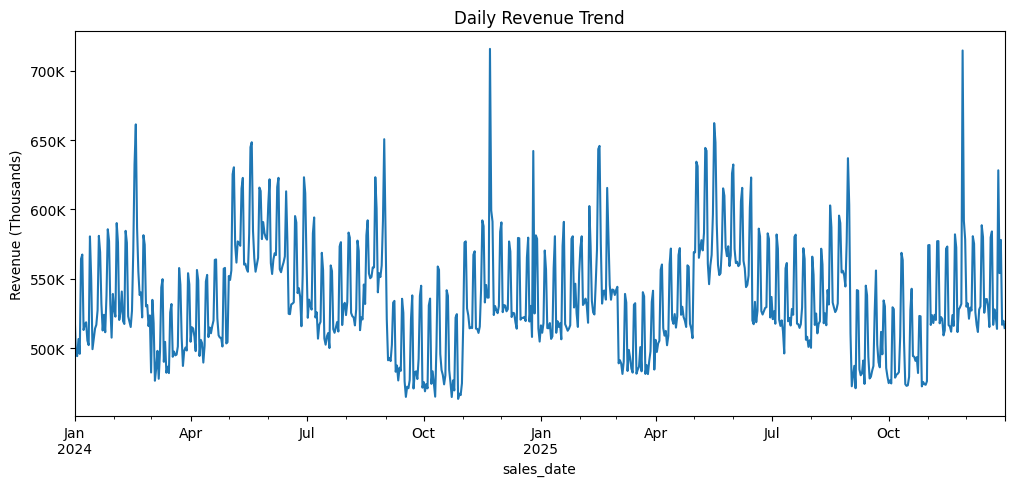

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

daily_trend = daily_sales_df.groupby("sales_date")["net_sales"].sum()

ax = daily_trend.plot(figsize=(12,5), title="Daily Revenue Trend")

# Format Y-axis → Thousands (K)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e3:.0f}K')
)

plt.ylabel("Revenue (Thousands)")
plt.show()

**“Revenue shows seasonal spikes and promotional peaks, especially during high retail periods like winter and promotional events.”**

# **Store Performance Ranking**

In [28]:
store_perf = (
    daily_sales_df.groupby("store_id")[["net_sales", "gross_margin", "units_sold"]]
    .sum()
    .sort_values("net_sales", ascending=False)
)

print(store_perf.head())
print(store_perf.tail())

            net_sales  gross_margin  units_sold
store_id                                       
2051      51885783.70   19820781.94      536265
2006      48062227.55   17865950.01      524841
2047      47100155.75   18043018.36      446933
2034      44641847.26   16553067.33      450342
2046      39009088.81   14823948.12      358385
            net_sales  gross_margin  units_sold
store_id                                       
2055      26376943.86    9895942.44      272103
2058      23342752.20    9027293.71      232245
2037      16956464.21    6422917.74      173237
2049      16480964.19    6490624.44      178158
2013      15185353.80    5886902.50      162587


**Look for:**

**top stores → why strong?**

**bottom stores → why weak?**

...

**We can later connect to:**

**demographics**

**competition**

**weather**

# **Category Performance**

In [29]:
category_perf = (
    daily_sales_df
    .merge(products_df[["product_id", "category"]], on="product_id")
    .groupby("category")[["net_sales", "gross_margin", "units_sold"]]
    .sum()
    .sort_values("net_sales", ascending=False)
)

print(category_perf)

                        net_sales  gross_margin  units_sold
category                                                   
Tools & Hardware     1.809842e+08   77057895.45     1127797
Home Essentials      6.286521e+07   20612575.54     1382060
Automotive           4.995894e+07   15387877.73      830554
Outdoor Living       4.827895e+07   17956211.76      223411
Sports & Recreation  3.143182e+07   12117315.33      150338
Seasonal Summer      1.031234e+07    3660799.47      147287
Seasonal Winter      7.801877e+06    2532046.07       79769


**“Tools & Hardware and Home Essentials drive the largest share of revenue, while seasonal categories show strong variability depending on time of year.”**

# **Promotion Impact**

In [30]:
daily_sales_df["has_promo"] = daily_sales_df["promo_id"].notna()

promo_analysis = (
    daily_sales_df.groupby("has_promo")[["units_sold", "net_sales", "gross_margin"]]
    .mean()
)

print(promo_analysis)

           units_sold    net_sales  gross_margin
has_promo                                       
False       11.659931  1212.446576    507.826625
True        15.245617  1391.073089    425.589102


**We already saw:**

**✔ promo → higher units**

**✔ promo → lower margin**

...

**So Now we can say:**

**“Promotions successfully drive volume, but at the cost of reduced profitability, suggesting a need for optimization rather than blanket discounting.”**

# **Margin Rate (Executive Metric)**

In [31]:
daily_sales_df["margin_rate"] = daily_sales_df["gross_margin"] / daily_sales_df["net_sales"]

print(daily_sales_df["margin_rate"].mean())

0.3724141190236925


**What this tells:**

**overall profitability health**

**We can compare promo vs non-promo margin rate later**

# **Identify Problems**

In [32]:
low_margin = daily_sales_df[daily_sales_df["margin_rate"] < 0.2]

print("Low margin %:", len(low_margin) / len(daily_sales_df) * 100)

Low margin %: 5.993926516672973


**“A portion of sales operate under low margin conditions, likely driven by aggressive promotions or pricing strategies.”**

# **Check Later:**

**Which Categories or Products could it be for?**

# **Project 1: Demand Forecasting**

**Project 1 Goal:**

**“How can we predict future demand to support inventory, pricing, and planning decisions?”**

🟦 **Layer 1 — Business Baseline**

**✔ Moving average**

**✔ Simple trend**

...

**Purpose:**

**sanity check**

**benchmark**

**explainability**

# **Prepare Forecasting Dataset**



**We always need:**

**. Create dataset**

**. Filter dataset**

**. Then apply transformations**

**Aggregate to daily product-level demand (Build forecast dataset)**

In [33]:
forecast_df = (
    daily_sales_df
    .groupby(["sales_date", "product_id"])["units_sold"]
    .sum()
    .reset_index()
)

print(forecast_df.head())

  sales_date  product_id  units_sold
0 2024-01-01       10006         164
1 2024-01-01       10008         134
2 2024-01-01       10010         119
3 2024-01-01       10018          83
4 2024-01-01       10025         316


**Select one product**

In [34]:
sample_product = forecast_df["product_id"].iloc[0]

product_data = forecast_df[
    forecast_df["product_id"] == sample_product
].copy()

# **Create Baseline Forecast (Moving Average)**

**Apply sorting + Moving average**

In [35]:
product_data = product_data.sort_values("sales_date")

product_data["forecast_ma7"] = product_data["units_sold"].rolling(window=7).mean()

# **Visualize One Product**

/tmp/ipykernel_65613/3531586933.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


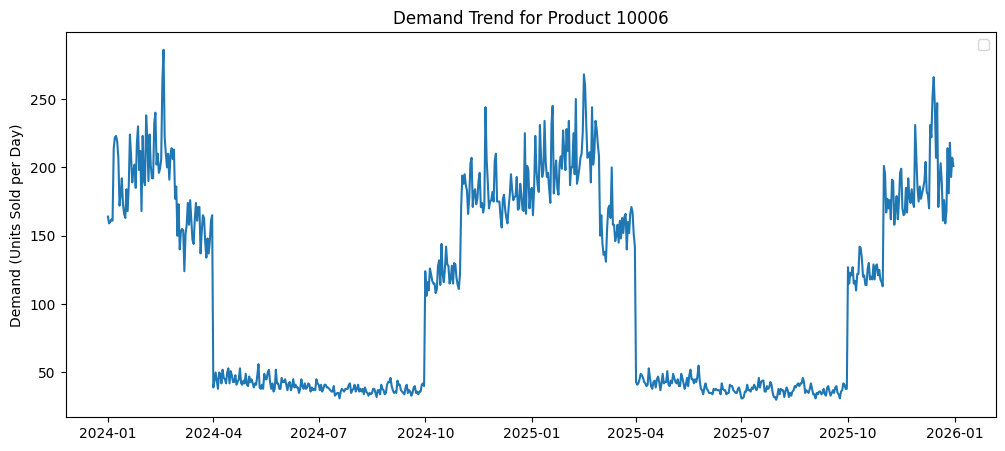

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(product_data["sales_date"], product_data["units_sold"])#, label="Actual")
#plt.plot(product_data["sales_date"], product_data["forecast_ma7"], label="MA7")
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Demand Trend for Product {sample_product}")

plt.legend()
plt.show()

**We should see:**

**- seasonality (winter/summer)**

**- spikes (promotions)**

**- noise (realistic variation)**

**If yes → dataset is very strong**

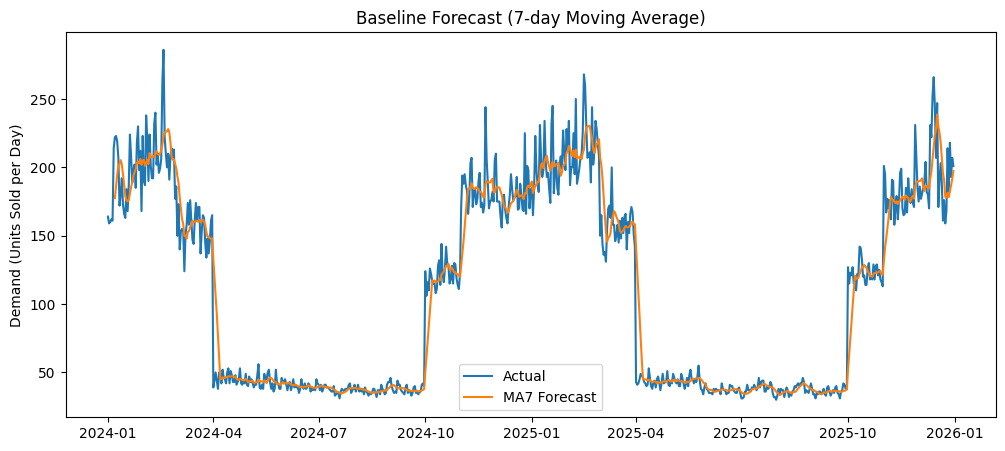

In [37]:
plt.figure(figsize=(12,5))
plt.plot(product_data["sales_date"], product_data["units_sold"], label="Actual")
plt.plot(product_data["sales_date"], product_data["forecast_ma7"], label="MA7 Forecast")

plt.legend()
plt.ylabel("Demand (Units Sold per Day)")
plt.title("Baseline Forecast (7-day Moving Average)")
plt.show()

**“I started with a moving average baseline to establish a simple and interpretable benchmark before introducing more advanced models.”**

# **Evaluate Model**

In [38]:
from sklearn.metrics import mean_absolute_error

df_eval = product_data.dropna()

mae = mean_absolute_error(df_eval["units_sold"], df_eval["forecast_ma7"])

print("MAE:", round(mae, 2))

MAE: 9.75


**MAE = average error in units**

**compare across products later**

# **Add Features**

**To make it more similar to real business forecasting**

In [39]:
forecast_df = forecast_df.merge(
    calendar_df[["date", "month", "is_weekend", "is_holiday"]],
    left_on="sales_date",
    right_on="date",
    how="left"
)

forecast_df = forecast_df.merge(
    products_df[["product_id", "seasonality_type"]],
    on="product_id",
    how="left"
)

**Now the model knows:**

**- weekends**

**- holidays**

**- seasonality type**

**More similar to real-world forecasting**

# **Simple ML Model (Random Forest)**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features
features = ["month", "is_weekend", "is_holiday"]

X = forecast_df[features]
y = forecast_df["units_sold"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

# **Evaluate**

In [41]:
mae_ml = mean_absolute_error(y_test, preds)
print("ML MAE:", round(mae_ml, 2))

ML MAE: 55.82


**“I compared a baseline time-series approach with a machine learning model incorporating calendar features, and evaluated performance using MAE'.”**

# **Check : Example insights to extract:**
1. Seasonality

“Winter products show strong seasonal spikes, indicating the need for pre-season inventory buildup.”

2. Promotions

“Demand spikes during promotional periods suggest forecasting models should incorporate promotion signals.”

3. Forecast usefulness

“Accurate demand forecasts can reduce stockouts and overstock, improving both revenue and working capital efficiency.”

**“I built a demand forecasting pipeline starting with a baseline time-series model and extended it using machine learning with calendar features. I validated performance using MAE and translated results into actionable insights for inventory and promotion planning.”**

**We can improve model later (add weather, promos)**

# **Time Series Model (Prophet)**

In [42]:
!pip install prophet

**“I started with a baseline, then applied a time series model like Prophet to capture seasonality and trends”**

**Below Model:**

**- builds forecast_df**

**- selects one product**

**- creates prophet_df**

**- adds promo_flag correctly**

**- fits Prophet**

**- forecasts 90 days**

**- assumes future promo flag = 0**

**If we forecast 90 days ahead, Prophet will also need promo_flag values for those future rows.**

**For a simple version, we set them to 0 unless we want to simulate future promotions.**

In [43]:
# !pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1. BUILD FORECAST DATASET
# -----------------------------
forecast_df = (
    daily_sales_df
    .groupby(["sales_date", "product_id"], as_index=False)["units_sold"]
    .sum()
)

# -----------------------------
# 2. PICK ONE PRODUCT
# -----------------------------
product_id = forecast_df["product_id"].iloc[0]

# You can also manually set one, e.g.
# product_id = 10012

# -----------------------------
# 3. PREPARE PROPHET INPUT
# -----------------------------
prophet_df = (
    forecast_df[forecast_df["product_id"] == product_id]
    .copy()
    .rename(columns={"sales_date": "ds", "units_sold": "y"})
)

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

# -----------------------------
# 4. CREATE PROMO FLAG FOR THIS PRODUCT
# -----------------------------
promo_flag_df = (
    daily_sales_df[daily_sales_df["product_id"] == product_id]
    .groupby("sales_date")["promo_id"]
    .apply(lambda x: x.notna().any())
    .reset_index(name="promo_flag")
)

promo_flag_df["sales_date"] = pd.to_datetime(promo_flag_df["sales_date"])

# Merge promo flag into prophet_df
prophet_df = prophet_df.merge(
    promo_flag_df,
    left_on="ds",
    right_on="sales_date",
    how="left"
)

prophet_df["promo_flag"] = prophet_df["promo_flag"].fillna(False).astype(int)
prophet_df = prophet_df.drop(columns=["sales_date"])

# -----------------------------
# 5. OPTIONAL: TRAIN / TEST SPLIT
# -----------------------------
# Keep last 30 days as test
train_size = len(prophet_df) - 30
train_df = prophet_df.iloc[:train_size].copy()
test_df = prophet_df.iloc[train_size:].copy()

# -----------------------------
# 6. FIT PROPHET MODEL
# -----------------------------
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.add_regressor("promo_flag")
model.fit(train_df[["ds", "y", "promo_flag"]])

# -----------------------------
# 7. FORECAST TEST PERIOD
# -----------------------------
future_test = test_df[["ds", "promo_flag"]].copy()
forecast_test = model.predict(future_test)

# Evaluate on test set
mae_prophet = mean_absolute_error(test_df["y"], forecast_test["yhat"])
print("Prophet Test MAE:", round(mae_prophet, 2))

# -----------------------------
# 8. FIT ON FULL DATA
# -----------------------------
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

final_model.add_regressor("promo_flag")
final_model.fit(prophet_df[["ds", "y", "promo_flag"]])

# -----------------------------
# 9. FORECAST NEXT 90 DAYS
# -----------------------------
future = final_model.make_future_dataframe(periods=90)

# For historical dates, bring promo_flag from actual data
future = future.merge(
    prophet_df[["ds", "promo_flag"]],
    on="ds",
    how="left"
)

# For future dates, assume no promotion planned yet
future["promo_flag"] = future["promo_flag"].fillna(0).astype(int)

forecast = final_model.predict(future)

'''
# -----------------------------
# 10. PLOT FORECAST
# -----------------------------
fig1 = final_model.plot(forecast)
plt.title(f"Prophet Forecast for Product {product_id}")
plt.show()
'''

'''# Optional components plot
fig2 = final_model.plot_components(forecast)
plt.show()'''

# -----------------------------
# 11. SHOW FORECAST OUTPUT
# -----------------------------
forecast_output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)
print(forecast_output)
'''
# -----------------------------
# 12. OPTIONAL: ACTUAL VS TEST PREDICTION PLOT
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Actual Test")
plt.plot(forecast_test["ds"], forecast_test["yhat"], label="Predicted Test")
plt.title(f"Actual vs Predicted Demand for Product {product_id}")
plt.legend()
plt.show()
'''

Prophet Test MAE: 27.38
            ds        yhat  yhat_lower  yhat_upper
791 2026-03-02  179.999209  158.643038  199.175001
792 2026-03-03  178.522302  156.011059  200.535751
793 2026-03-04  176.600299  155.941840  198.142463
794 2026-03-05  173.178435  152.370798  195.573507
795 2026-03-06  172.802370  150.621329  193.833047
796 2026-03-07  182.556807  160.613280  204.475130
797 2026-03-08  180.034617  158.646103  201.447440
798 2026-03-09  167.327634  145.714722  189.268844
799 2026-03-10  167.071256  145.384444  187.898991
800 2026-03-11  166.287396  144.534250  186.445558
801 2026-03-12  163.878563  141.687600  184.860854
802 2026-03-13  164.350249  142.378555  187.307681
803 2026-03-14  174.750612  154.120007  196.522016
804 2026-03-15  172.640593  150.909878  193.103831
805 2026-03-16  160.085610  139.447049  182.299804
806 2026-03-17  159.700938  136.588557  180.758630
807 2026-03-18  158.495288  136.886026  179.262060
808 2026-03-19  155.365366  134.089518  176.896593
809 202

'\n# -----------------------------\n# 12. OPTIONAL: ACTUAL VS TEST PREDICTION PLOT\n# -----------------------------\nplt.figure(figsize=(12, 5))\nplt.plot(train_df["ds"], train_df["y"], label="Train")\nplt.plot(test_df["ds"], test_df["y"], label="Actual Test")\nplt.plot(forecast_test["ds"], forecast_test["yhat"], label="Predicted Test")\nplt.title(f"Actual vs Predicted Demand for Product {product_id}")\nplt.legend()\nplt.show()\n'

In [44]:
print(prophet_df["ds"].min(), prophet_df["ds"].max())
print(future["ds"].min(), future["ds"].max())
print(len(prophet_df))

2024-01-01 00:00:00 2025-12-31 00:00:00
2024-01-01 00:00:00 2026-03-31 00:00:00
731


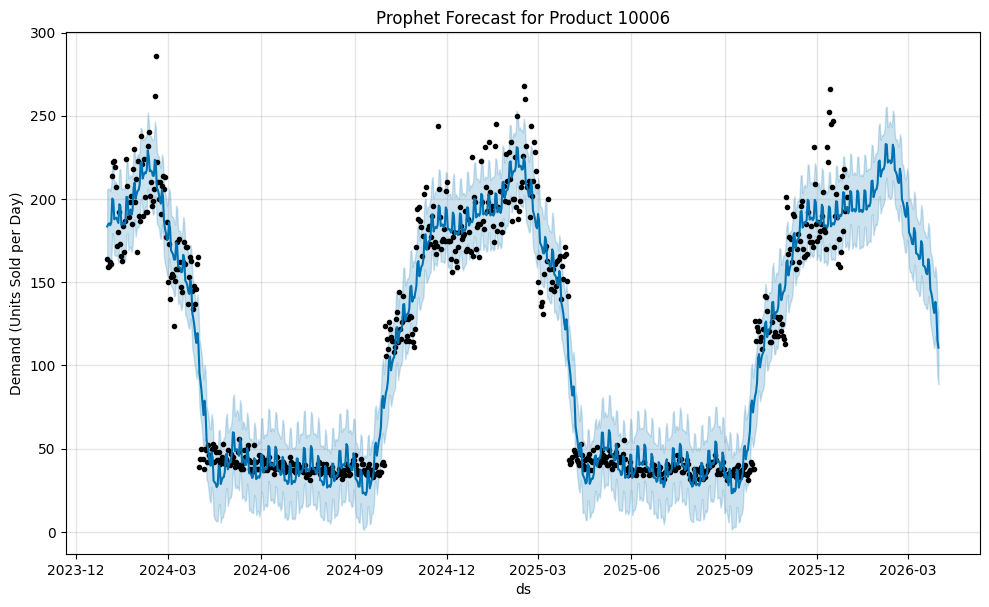

In [45]:
fig1 = final_model.plot(forecast)
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Prophet Forecast for Product {product_id}")
plt.show()

**Strong seasonality captured**

**We clearly see:**

**high demand (winter periods)**

**low demand (summer periods)**

...

**Model understands seasonal structure**

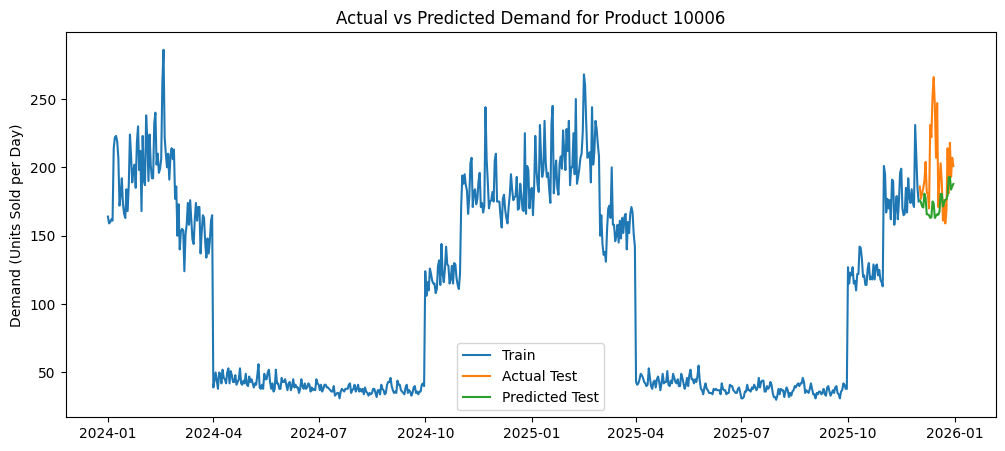

In [46]:
plt.figure(figsize=(12,5))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Actual Test")
plt.plot(forecast_test["ds"], forecast_test["yhat"], label="Predicted Test")
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Actual vs Predicted Demand for Product {product_id}")
plt.legend()
plt.show()

**Prediction follows general level.**

**Green line (prediction) is:**

**- in the correct range**

**- not completely off**

...

**So the Model is not broken.**

⚠️ What is NOT perfect (and that is OK)

...

🔸 Underestimation of spikes

- Orange (actual test) has peaks up to ~250+

- Green (prediction) stays around ~170-190

🔸 Model is:

- too smooth

- missing extreme peaks

...

Why this happens? (This is actually expected with Prophet)

🔸 Prophet models:

- trend

- seasonality

BUT:

🔸 it struggles with:

- sharp spikes

- sudden promo-driven jumps

**“The model captures baseline demand well, but underestimates peak demand driven by promotions or sudden demand surges.”**

**This suggests that incorporating additional features such as promotion intensity or more granular signals could improve performance.”**

In [47]:
print(prophet_df["promo_flag"].value_counts())

promo_flag
1    651
0     80
Name: count, dtype: int64


# **Add Weather to Prophet**

### **Build weather features for the selected product**

**Since my forecast is for one product and the product is sold across stores, the cleanest approach is to create a daily aggregated weather signal across the stores that carry that product.**

Prophet + Weather Test MAE: 27.0


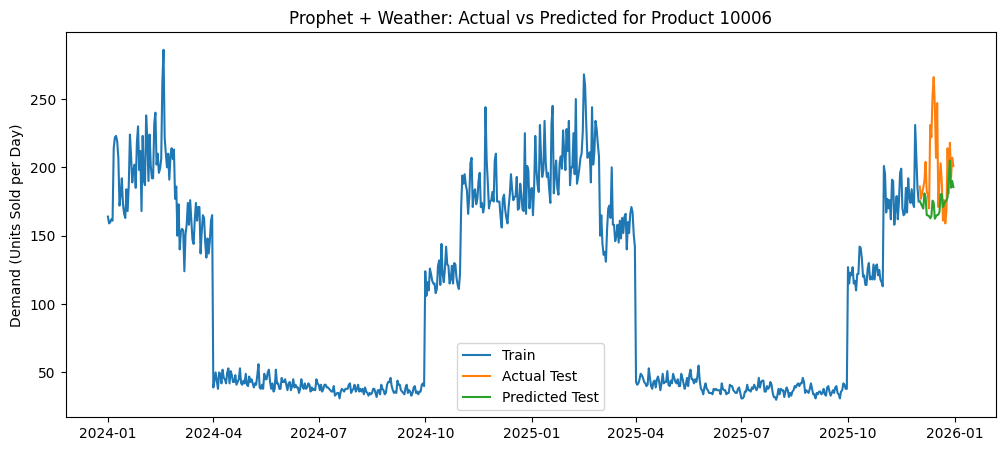

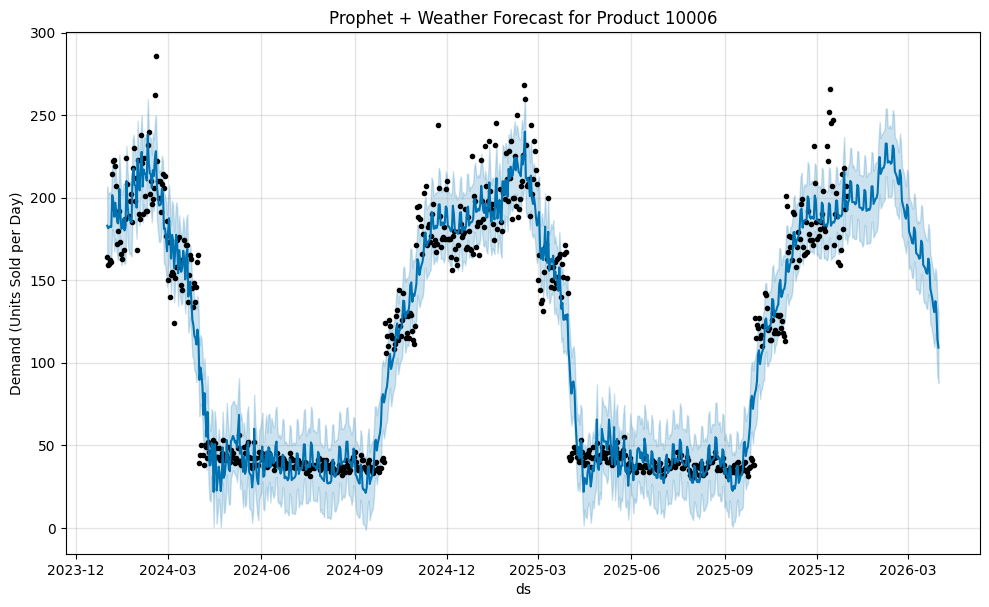

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1. BUILD FORECAST DATASET
# -----------------------------
forecast_df = (
    daily_sales_df
    .groupby(["sales_date", "product_id"], as_index=False)["units_sold"]
    .sum()
)

# Choose one product
product_id = forecast_df["product_id"].iloc[0]

# Prophet base
prophet_df = (
    forecast_df[forecast_df["product_id"] == product_id]
    .copy()
    .rename(columns={"sales_date": "ds", "units_sold": "y"})
)

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

# -----------------------------
# 2. PROMO FLAG FOR THIS PRODUCT
# -----------------------------
promo_flag_df = (
    daily_sales_df[daily_sales_df["product_id"] == product_id]
    .groupby("sales_date")["promo_id"]
    .apply(lambda x: x.notna().any())
    .reset_index(name="promo_flag")
)

promo_flag_df["sales_date"] = pd.to_datetime(promo_flag_df["sales_date"])

prophet_df = prophet_df.merge(
    promo_flag_df,
    left_on="ds",
    right_on="sales_date",
    how="left"
)

prophet_df["promo_flag"] = prophet_df["promo_flag"].fillna(False).astype(int)
prophet_df = prophet_df.drop(columns=["sales_date"])

# -----------------------------
# 3. WEATHER FEATURES
# -----------------------------
# Find stores that carry this product
product_store_ids = assortment_df.loc[
    assortment_df["product_id"] == product_id, "store_id"
].unique()

product_store_cities = stores_df.loc[
    stores_df["store_id"].isin(product_store_ids), "city"
].unique()

# Aggregate weather across those cities per day
weather_product_df = (
    weather_df[weather_df["city"].isin(product_store_cities)]
    .groupby("weather_date", as_index=False)
    .agg(
        avg_temperature_c=("avg_temperature_c", "mean"),
        snowfall_cm=("snowfall_cm", "mean")
    )
)

weather_product_df["weather_date"] = pd.to_datetime(weather_product_df["weather_date"])

# Merge weather into prophet_df
prophet_df = prophet_df.merge(
    weather_product_df,
    left_on="ds",
    right_on="weather_date",
    how="left"
)

prophet_df["avg_temperature_c"] = prophet_df["avg_temperature_c"].fillna(prophet_df["avg_temperature_c"].median())
prophet_df["snowfall_cm"] = prophet_df["snowfall_cm"].fillna(0)
prophet_df = prophet_df.drop(columns=["weather_date"])

# Optional: create a snow-event flag too
prophet_df["snow_event_flag"] = (prophet_df["snowfall_cm"] >= 3).astype(int)

# -----------------------------
# 4. TRAIN / TEST SPLIT
# -----------------------------
train_size = len(prophet_df) - 30
train_df = prophet_df.iloc[:train_size].copy()
test_df = prophet_df.iloc[train_size:].copy()

# -----------------------------
# 5. FIT PROPHET WITH PROMO + WEATHER
# -----------------------------
model_weather = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_weather.add_regressor("promo_flag")
model_weather.add_regressor("avg_temperature_c")
model_weather.add_regressor("snowfall_cm")
model_weather.add_regressor("snow_event_flag")

model_weather.fit(
    train_df[
        ["ds", "y", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]
    ]
)

# -----------------------------
# 6. TEST FORECAST
# -----------------------------
future_test = test_df[
    ["ds", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]
].copy()

forecast_test_weather = model_weather.predict(future_test)

mae_prophet_weather = mean_absolute_error(test_df["y"], forecast_test_weather["yhat"])
print("Prophet + Weather Test MAE:", round(mae_prophet_weather, 2))

# -----------------------------
# 7. FIT FINAL MODEL ON FULL DATA
# -----------------------------
final_model_weather = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

final_model_weather.add_regressor("promo_flag")
final_model_weather.add_regressor("avg_temperature_c")
final_model_weather.add_regressor("snowfall_cm")
final_model_weather.add_regressor("snow_event_flag")

final_model_weather.fit(
    prophet_df[
        ["ds", "y", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]
    ]
)

# -----------------------------
# 8. CREATE FUTURE DATAFRAME
# -----------------------------
future = final_model_weather.make_future_dataframe(periods=90)

# Merge historical regressors
future = future.merge(
    prophet_df[
        ["ds", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]
    ],
    on="ds",
    how="left"
)

# For future dates:
# promo assumed 0 unless planned
future["promo_flag"] = future["promo_flag"].fillna(0).astype(int)

# Extend weather using average by month from historical product weather
monthly_weather = prophet_df.copy()
monthly_weather["month"] = monthly_weather["ds"].dt.month

monthly_weather_avg = (
    monthly_weather.groupby("month", as_index=False)
    .agg(
        avg_temperature_c=("avg_temperature_c", "mean"),
        snowfall_cm=("snowfall_cm", "mean"),
        snow_event_flag=("snow_event_flag", "mean")
    )
)

future["month"] = future["ds"].dt.month
future = future.merge(
    monthly_weather_avg,
    on="month",
    how="left",
    suffixes=("", "_monthly")
)

future["avg_temperature_c"] = future["avg_temperature_c"].fillna(future["avg_temperature_c_monthly"])
future["snowfall_cm"] = future["snowfall_cm"].fillna(future["snowfall_cm_monthly"])
future["snow_event_flag"] = future["snow_event_flag"].fillna(
    (future["snow_event_flag_monthly"] >= 0.5).astype(int)
)

future["avg_temperature_c"] = future["avg_temperature_c"].fillna(prophet_df["avg_temperature_c"].median())
future["snowfall_cm"] = future["snowfall_cm"].fillna(0)
future["snow_event_flag"] = future["snow_event_flag"].fillna(0).astype(int)

future = future.drop(
    columns=[
        "month",
        "avg_temperature_c_monthly",
        "snowfall_cm_monthly",
        "snow_event_flag_monthly"
    ],
    errors="ignore"
)

# -----------------------------
# 9. FINAL FORECAST
# -----------------------------
forecast_weather = final_model_weather.predict(
    future[
        ["ds", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]
    ]
)

# -----------------------------
# 10. PLOTS
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Actual Test")
plt.plot(forecast_test_weather["ds"], forecast_test_weather["yhat"], label="Predicted Test")
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Prophet + Weather: Actual vs Predicted for Product {product_id}")
plt.legend()
plt.show()

fig1 = final_model_weather.plot(forecast_weather)
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Prophet + Weather Forecast for Product {product_id}")
plt.show()

# **Hybrid model for spikes**

The idea is:

Prophet models the baseline seasonal demand

ML model models the remaining spike behavior

...

Actual demand = baseline forecast + spike adjustment

## **Create residuals from Prophet + Weather**

In [49]:
# Align test set with prophet prediction
test_results = test_df.copy()
test_results["prophet_yhat"] = forecast_test_weather["yhat"].values
test_results["residual"] = test_results["y"] - test_results["prophet_yhat"]

print(test_results[["ds", "y", "prophet_yhat", "residual"]].head())

            ds    y  prophet_yhat   residual
701 2025-12-02  186    175.258614  10.741386
702 2025-12-03  177    173.495657   3.504343
703 2025-12-04  181    171.575405   9.424595
704 2025-12-05  185    169.841150  15.158850
705 2025-12-06  190    180.943059   9.056941


# **Train ML model on residuals**

We will use a Random Forest to predict the residual/spike part using:

- promo
- temperature
- snowfall
- snow event

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Add month and weekday features
train_ml = train_df.copy()
test_ml = test_df.copy()

train_ml["month"] = train_ml["ds"].dt.month
train_ml["dayofweek"] = train_ml["ds"].dt.dayofweek

test_ml["month"] = test_ml["ds"].dt.month
test_ml["dayofweek"] = test_ml["ds"].dt.dayofweek

# Get in-sample prophet prediction for train
train_pred = model_weather.predict(
    train_df[["ds", "promo_flag", "avg_temperature_c", "snowfall_cm", "snow_event_flag"]]
)

train_ml["prophet_yhat"] = train_pred["yhat"].values
train_ml["residual"] = train_df["y"].values - train_ml["prophet_yhat"]

# Features for spike adjustment
feature_cols = [
    "promo_flag",
    "avg_temperature_c",
    "snowfall_cm",
    "snow_event_flag",
    "month",
    "dayofweek"
]

X_train = train_ml[feature_cols]
y_train = train_ml["residual"]

X_test = test_ml.assign(
    month=test_ml["ds"].dt.month,
    dayofweek=test_ml["ds"].dt.dayofweek
)[feature_cols]

# Train ML residual model
residual_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

residual_model.fit(X_train, y_train)

# Predict spike adjustment
test_spike_adjustment = residual_model.predict(X_test)

# Hybrid forecast
test_ml["prophet_yhat"] = forecast_test_weather["yhat"].values
test_ml["hybrid_yhat"] = test_ml["prophet_yhat"] + test_spike_adjustment

# Keep forecast non-negative
test_ml["hybrid_yhat"] = test_ml["hybrid_yhat"].clip(lower=0)

# Compare MAE
mae_hybrid = mean_absolute_error(test_df["y"], test_ml["hybrid_yhat"])
print("Prophet + Weather Test MAE:", round(mae_prophet_weather, 2))
print("Hybrid Test MAE:", round(mae_hybrid, 2))

Prophet + Weather Test MAE: 27.0
Hybrid Test MAE: 27.17


In [51]:
print("Max actual:", test_df["y"].max())
print("Max predicted (Prophet):", forecast_test["yhat"].max())
print("Max predicted (Prophet+Weather):", forecast_test_weather["yhat"].max())
print("Max predicted (Hybrid):", test_ml["hybrid_yhat"].max())

Max actual: 266
Max predicted (Prophet): 192.99571876124617
Max predicted (Prophet+Weather): 204.98825397055708
Max predicted (Hybrid): 206.30518950806763


**“While the model performs well on average (as measured by MAE), it underestimates peak demand levels. This is critical because those peaks are often tied to promotions or seasonal events, which are the periods where stockouts are most costly.”**

## **Plot hybrid vs actual**

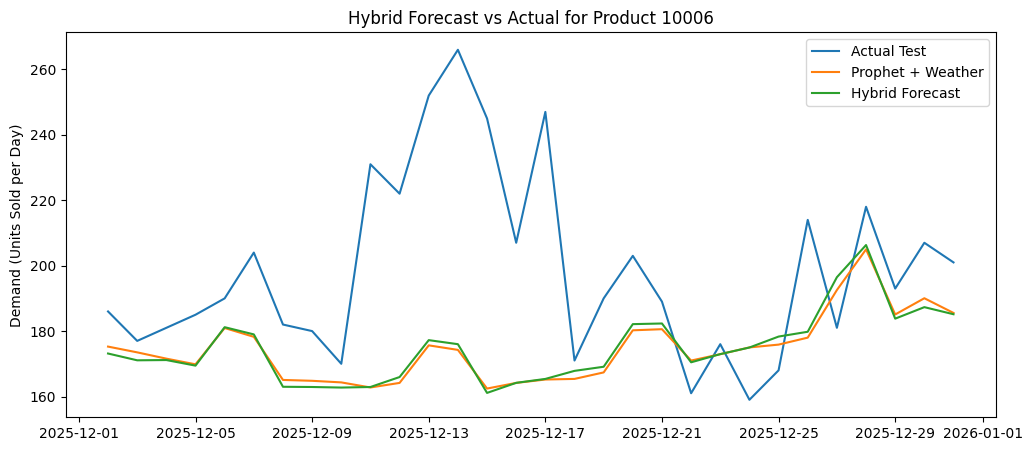

In [52]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="Actual Test")
plt.plot(forecast_test_weather["ds"], forecast_test_weather["yhat"], label="Prophet + Weather")
plt.plot(test_df["ds"], test_ml["hybrid_yhat"], label="Hybrid Forecast")
plt.ylabel("Demand (Units Sold per Day)")
plt.title(f"Hybrid Forecast vs Actual for Product {product_id}")
plt.legend()
plt.show()

**Calculate peak error gap**

In [53]:
peak_gap = test_df["y"].max() - forecast_test_weather["yhat"].max()
print("Peak underestimation gap:", round(peak_gap, 2))

Peak underestimation gap: 61.01


# **Project 2: Promotion Effectiveness**

## **Build promo analysis dataset**

**Bring product category into sales**

In [54]:
promo_analysis_df = daily_sales_df.merge(
    products_df[["product_id", "category", "subcategory"]],
    on="product_id",
    how="left"
)

promo_analysis_df["has_promo"] = promo_analysis_df["promo_id"].notna()

**Merge promo type as well**

In [55]:
promo_analysis_df = promo_analysis_df.merge(
    promotion_df[["promo_id", "promo_type", "flyer_flag", "discount_percent", "discount_amount"]],
    on="promo_id",
    how="left"
)

## **Overall promo vs non-promo comparison**

**First executive view**

In [56]:
overall_promo_comparison = (
    promo_analysis_df
    .groupby("has_promo")[["units_sold", "gross_sales", "net_sales", "gross_margin"]]
    .mean()
)

print(overall_promo_comparison)

           units_sold  gross_sales    net_sales  gross_margin
has_promo                                                    
False       11.659931  1212.446576  1212.446576    507.826625
True        15.245617  1666.084660  1391.073089    425.589102


In [57]:
print(promo_analysis_df.columns)

'''
Look for:

units_sold   ** for using as volume of sales
quantity
qty
'''

Index(['sales_date', 'store_id', 'product_id', 'units_sold', 'unit_price',
       'discount_amount_x', 'gross_sales', 'net_sales', 'cost_of_goods_sold',
       'gross_margin', 'promo_id', 'channel', 'return_flag', 'has_promo',
       'margin_rate', 'category', 'subcategory', 'promo_type', 'flyer_flag',
       'discount_percent', 'discount_amount_y'],
      dtype='object')


'\nLook for:\n\nunits_sold   ** for using as volume of sales\nquantity\nqty\n'

**Calculate margin rate**

In [58]:
promo_margin_rate = (
    promo_analysis_df
    .groupby("has_promo")[["net_sales", "gross_margin"]]
    .sum()
)

promo_margin_rate["margin_rate"] = promo_margin_rate["gross_margin"] / promo_margin_rate["net_sales"]
print(promo_margin_rate)

              net_sales  gross_margin  margin_rate
has_promo                                         
False      2.613538e+08  1.094666e+08     0.418845
True       1.302796e+08  3.985812e+07     0.305943


In [59]:
promo_summary = (
    promo_analysis_df
    .groupby("has_promo")[["net_sales", "gross_margin", "units_sold"]]
    .sum()
)

promo_summary["margin_rate"] = promo_summary["gross_margin"] / promo_summary["net_sales"]

print(promo_summary)

              net_sales  gross_margin  units_sold  margin_rate
has_promo                                                     
False      2.613538e+08  1.094666e+08     2513403     0.418845
True       1.302796e+08  3.985812e+07     1427813     0.305943


**We already saw this pattern:**

**promo days → higher units sold**

**promo days → lower margin**

**Now we formalize it.**

**Key insight: Promo periods are associated with a lower margin rate (30.6% vs 41.9%), suggesting that promotions may boost demand but reduce profitability.**

**Business implication: Future promo strategy should focus on targeted promotions by category, season, and store, instead of broad discounting.**

**Calculate average price per unit & profit per unit**

In [60]:
promo_summary["avg_price"] = promo_summary["net_sales"] / promo_summary["units_sold"]
promo_summary["profit_per_unit"] = promo_summary["gross_margin"] / promo_summary["units_sold"]
print(promo_summary)

              net_sales  gross_margin  units_sold  margin_rate   avg_price  \
has_promo                                                                    
False      2.613538e+08  1.094666e+08     2513403     0.418845  103.984029   
True       1.302796e+08  3.985812e+07     1427813     0.305943   91.244133   

           profit_per_unit  
has_promo                   
False            43.553143  
True             27.915506  


## **Estimate uplift**

In [61]:
promo_uplift = (
    promo_analysis_df
    .groupby("has_promo")["units_sold"]
    .mean()
)

non_promo_avg = promo_uplift.loc[False]
promo_avg = promo_uplift.loc[True]

uplift_pct = ((promo_avg - non_promo_avg) / non_promo_avg) * 100
print("Estimated unit uplift from promotions (%):", round(uplift_pct, 2))

Estimated unit uplift from promotions (%): 30.75


**Promotions increased average unit sales by 30.75%**

In [62]:
print(promo_analysis_df)

       sales_date  store_id  product_id  units_sold  unit_price  \
0      2024-01-01      2001       10204           8       52.41   
1      2024-01-02      2001       10204           9       52.41   
2      2024-01-03      2001       10204           7       52.41   
3      2024-01-04      2001       10204           9       52.41   
4      2024-01-05      2001       10204           9       52.41   
...           ...       ...         ...         ...         ...   
309208 2025-12-27      2051       10026          58       85.60   
309209 2025-12-28      2051       10026          54       85.60   
309210 2025-12-29      2051       10026          49       85.60   
309211 2025-12-30      2051       10026          36       85.60   
309212 2025-12-31      2051       10026          47       71.82   

        discount_amount_x  gross_sales  net_sales  cost_of_goods_sold  \
0                    0.00       419.28     419.28              283.44   
1                    0.00       471.69     471.69

## **Promo type analysis**

In [63]:
promo_type_perf = (
    promo_analysis_df[promo_analysis_df["has_promo"]]
    .groupby("promo_type")[["units_sold", "net_sales", "gross_margin"]]
    .mean()
    .rename(columns={
        "units_sold": "avg_units_sold",
        "net_sales": "avg_net_sales",
        "gross_margin": "avg_gross_margin"
    })
    .sort_values("avg_units_sold", ascending=False)
)

print(promo_type_perf)

            avg_units_sold  avg_net_sales  avg_gross_margin
promo_type                                                 
bogo             18.381674    1475.616063        294.678275
flyer            16.899816    1463.707125        434.249847
pct_off          14.793417    1374.348628        416.693456
loyalty          13.649841    1366.077183        508.525499
dollar_off       12.900437    1277.113229        466.966122


**Add margin rate by propmo type**

In [64]:
promo_type_margin = (
    promo_analysis_df[promo_analysis_df["has_promo"]]
    .groupby("promo_type")[["net_sales", "gross_margin"]]
    .sum()
    .rename(columns={
        "net_sales": "total_net_sales",
        "gross_margin": "total_gross_margin"
    })
)

promo_type_margin["margin_rate"] = (
    promo_type_margin["total_gross_margin"] / promo_type_margin["total_net_sales"]
)

print(promo_type_margin.sort_values("margin_rate", ascending=False))

            total_net_sales  total_gross_margin  margin_rate
promo_type                                                  
loyalty         14181247.24          5279003.21     0.372252
dollar_off      14905188.50          5449961.61     0.365642
pct_off         57160533.79         17330697.52     0.303193
flyer           30988143.54          9193503.51     0.296678
bogo            13044446.00          2604955.95     0.199698


Not all promotions are equal

**Volume winners:**

bogo → highest units (18.38) → On average, each BOGO transaction (or record) sells about 18.38 units

flyer → strong

**Profitability winners:**

loyalty → highest margin rate (37%)

dollar_off → also strong

**Weakest:**

bogo → lowest margin rate (~20%)

**“BOGO promotions drive the highest volume but at the cost of very low profitability, while loyalty-based promotions provide a better balance between volume and margin.”**

What this can tell us: (For Example)

flyer promos drive strong volume

BOGO creates high unit movement but lower profitability

loyalty promos may be more margin-friendly

some promo types are expensive relative to value

## **Category-level promo response**

In [65]:
category_promo_perf = (
    promo_analysis_df
    .groupby(["category", "has_promo"])[["units_sold", "net_sales", "gross_margin"]]
    .mean()
    .reset_index()
)

print(category_promo_perf.head(20))

               category  has_promo  units_sold    net_sales  gross_margin
0            Automotive      False   13.627087   863.467232    296.215912
1            Automotive       True   16.135477   868.907483    197.366751
2       Home Essentials      False   16.228574   776.804537    279.935173
3       Home Essentials       True   20.375565   840.051795    218.756355
4        Outdoor Living      False    7.939261  1917.861970    823.279483
5        Outdoor Living       True   16.597015  3115.379357    902.385532
6       Seasonal Summer      False    6.721940   504.443860    197.737436
7       Seasonal Summer       True    9.354043   568.576912    154.167419
8       Seasonal Winter      False    6.616351   665.927650    240.582022
9       Seasonal Winter       True    8.900664   824.099250    207.068640
10  Sports & Recreation      False    5.533062  1252.425684    541.542766
11  Sports & Recreation       True    8.182740  1522.997519    471.785695
12     Tools & Hardware      False   1

In [66]:
category_uplift_pivot = (
    promo_analysis_df
    .groupby(["category", "has_promo"])["units_sold"]
    .mean()
    .unstack()
)

category_uplift_pivot.columns = ["non_promo_units", "promo_units"]
category_uplift_pivot["uplift_pct"] = (
    (category_uplift_pivot["promo_units"] - category_uplift_pivot["non_promo_units"])
    / category_uplift_pivot["non_promo_units"]
) * 100

print(category_uplift_pivot.sort_values("uplift_pct", ascending=False))

                     non_promo_units  promo_units  uplift_pct
category                                                     
Outdoor Living              7.939261    16.597015  109.049867
Sports & Recreation         5.533062     8.182740   47.888082
Seasonal Summer             6.721940     9.354043   39.156889
Seasonal Winter             6.616351     8.900664   34.525283
Tools & Hardware           10.642556    13.854639   30.181503
Home Essentials            16.228574    20.375565   25.553640
Automotive                 13.627087    16.135477   18.407382


Category sensitivity is VERY different

**Strong promo responders:**

Outdoor Living → +109% (!!)

Sports → +48%

**Weak responders:**

Automotive → +18%

**“Promotion effectiveness varies significantly by category, with Outdoor Living showing over 100% uplift, while Automotive shows much lower sensitivity.”**

This helps us answer:

Which categories benefit most from promotions?

Which categories may not need heavy discounting?

Where are we giving away margin unnecessarily?

Can work as executive decision support.

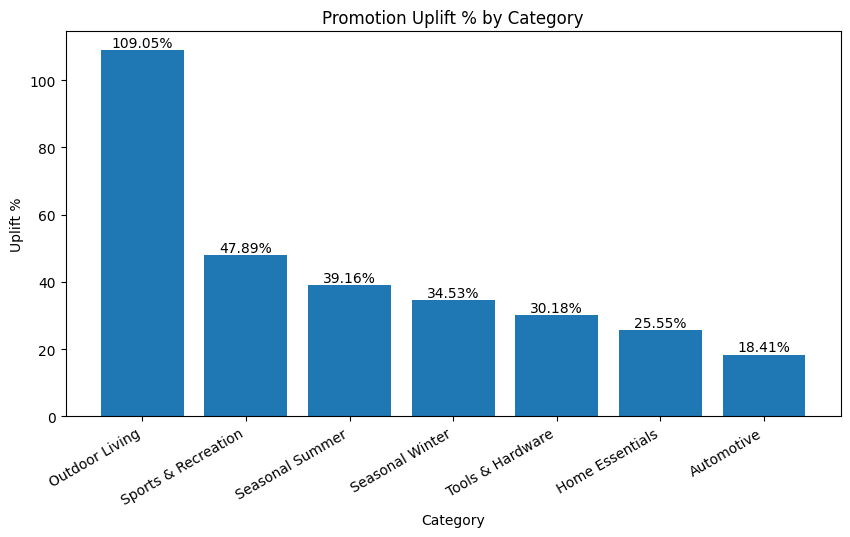

In [67]:
import matplotlib.pyplot as plt

category_uplift_pivot_sorted = category_uplift_pivot.sort_values(by="uplift_pct", ascending=False)
#promo_type_margin_sorted = promo_type_margin.sort_values(by="margin_rate", ascending=False)


plt.figure(figsize=(10, 5))


bars = plt.bar(
    category_uplift_pivot_sorted.index,
    category_uplift_pivot_sorted["uplift_pct"]
)

plt.title("Promotion Uplift % by Category")
plt.xlabel("Category")
plt.ylabel("Uplift %")
plt.xticks(rotation=30, ha="right")

# Add uplift % labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',   # 2 decimal places + %
        ha='center',
        va='bottom'
    )

plt.show()

## **Store-level promo dependence**

In [68]:
store_promo_dependence = (
    promo_analysis_df
    .groupby(["store_id", "has_promo"])["net_sales"]
    .mean()
    .unstack()
)

store_promo_dependence.columns = ["non_promo_net_sales", "promo_net_sales"]
store_promo_dependence["promo_lift_pct"] = (
    (store_promo_dependence["promo_net_sales"] - store_promo_dependence["non_promo_net_sales"])
    / store_promo_dependence["non_promo_net_sales"]
) * 100

print(store_promo_dependence.sort_values("promo_lift_pct", ascending=False).head())

          non_promo_net_sales  promo_net_sales  promo_lift_pct
store_id                                                      
2047              1651.633024      2135.371860       29.288518
2046              1304.329839      1652.594986       26.700696
2034              1154.467691      1451.852581       25.759481
2037               803.754951       999.273423       24.325632
2055               891.703003      1060.209801       18.897189


**This can show that some stores rely more heavily on promotions than others**

Top store uplift ~29%

Meaning: some stores depend heavily on promotions

**“Certain stores exhibit higher dependence on promotions, suggesting opportunities for localized strategy rather than uniform discounting.”**

# **Strategic Insight:**

**“While promotions are effective at driving demand, they should not be applied uniformly. Their impact varies significantly across product categories, promotion types, and stores.”**

Recommendations:

**1. Target promotions by category**

use aggressive promos for:
- Outdoor Living
- Seasonal categories

reduce promos for:
Automotive

**2. Optimize promo types**

reduce use of:
BOGO (low margin)

increase use of:
loyalty / dollar_off

**3. Localize strategy by store**

high promo-dependence stores → optimize pricing

low dependence → preserve margin

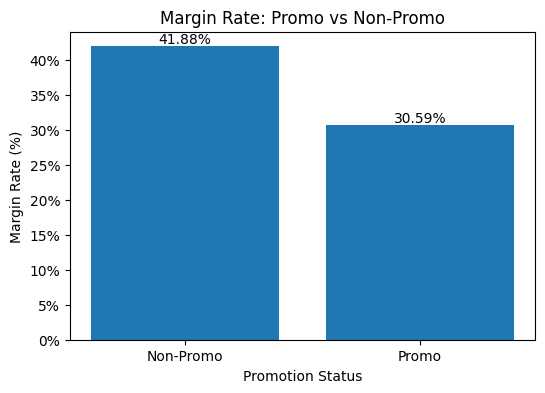

In [69]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(6, 4))

labels = ["Non-Promo", "Promo"]
values = promo_margin_rate["margin_rate"]

bars = plt.bar(labels, values)

plt.title("Margin Rate: Promo vs Non-Promo")
plt.ylabel("Margin Rate (%)")
plt.xlabel("Promotion Status")

# Y-axis → % with 0 decimals
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

# Bar labels → % with 2 decimals
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

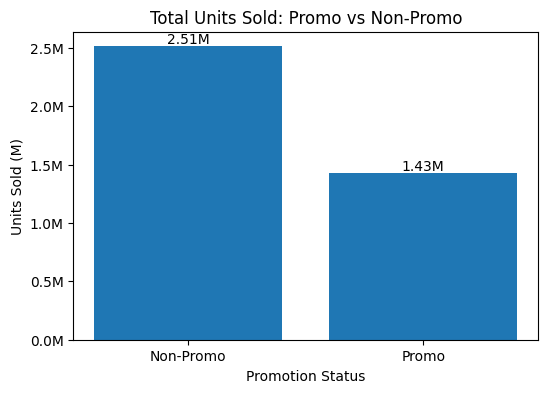

In [70]:
import matplotlib.ticker as ticker

plt.figure(figsize=(6, 4))

labels = ["Non-Promo", "Promo"]
values = promo_summary["units_sold"]

bars = plt.bar(labels, values)

plt.title("Total Units Sold: Promo vs Non-Promo")
plt.ylabel("Units Sold (M)")
plt.xlabel("Promotion Status")

# Y-axis → M (1 decimals)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Bar labels → M (2 decimals)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.show()

In [71]:
promo_vs_nonpromo = (
    promo_analysis_df
    .groupby("has_promo")[["units_sold", "gross_margin"]]
    .mean()
    .reset_index()
)

promo_vs_nonpromo["has_promo"] = promo_vs_nonpromo["has_promo"].map({
    False: "Non-Promo",
    True: "Promo"
})

'''
# Plot: Average Units Sold
plt.figure(figsize=(8, 5))
plt.bar(promo_vs_nonpromo["has_promo"], promo_vs_nonpromo["units_sold"])
plt.title("Average Units Sold: Promo vs Non-Promo")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.show()
'''

'\n# Plot: Average Units Sold\nplt.figure(figsize=(8, 5))\nplt.bar(promo_vs_nonpromo["has_promo"], promo_vs_nonpromo["units_sold"])\nplt.title("Average Units Sold: Promo vs Non-Promo")\nplt.xlabel("Promotion Status")\nplt.ylabel("Average Units Sold")\nplt.show()\n'

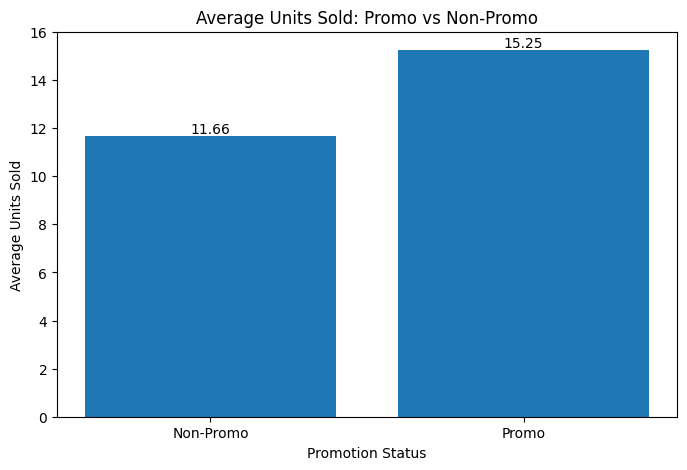

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    promo_vs_nonpromo["has_promo"],
    promo_vs_nonpromo["units_sold"]
)

plt.title("Average Units Sold: Promo vs Non-Promo")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")

# Bar labels → normal values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

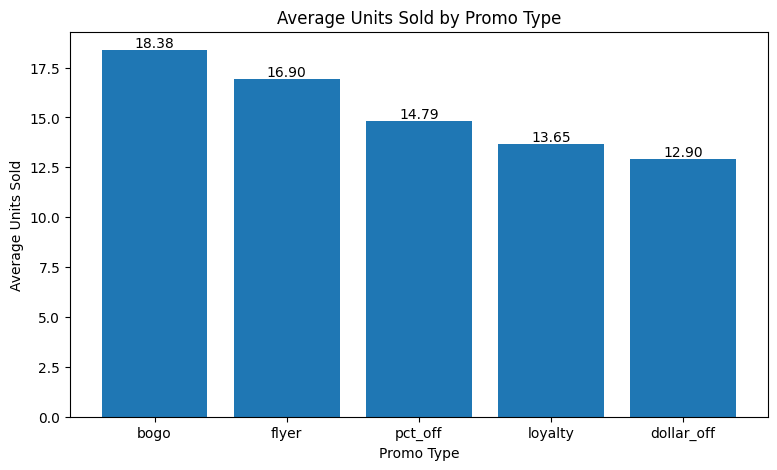

In [73]:
import matplotlib.pyplot as plt

promo_type_units = (
    promo_analysis_df[promo_analysis_df["has_promo"]]
    .groupby("promo_type")["units_sold"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    promo_type_units.index,
    promo_type_units.values
)

plt.title("Average Units Sold by Promo Type")
plt.xlabel("Promo Type")
plt.ylabel("Average Units Sold")

# Add labels on bars (2 decimals)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

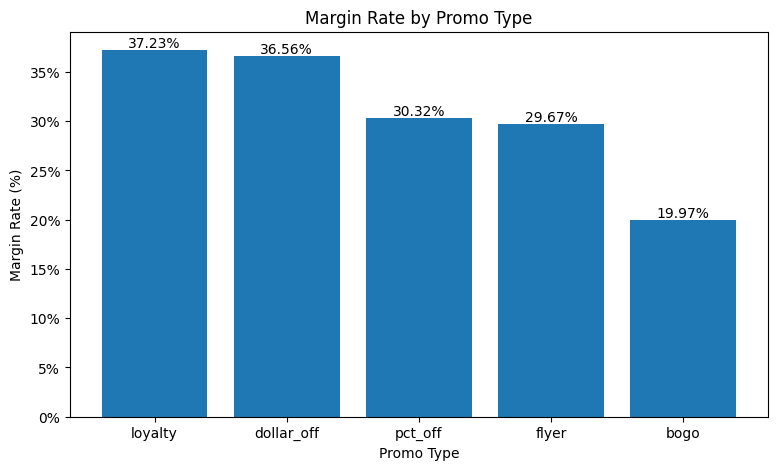

In [74]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Sort data (highest to lowest margin)
promo_type_margin_sorted = promo_type_margin.sort_values(by="margin_rate", ascending=False)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    promo_type_margin_sorted.index,
    promo_type_margin_sorted["margin_rate"]
)

plt.title("Margin Rate by Promo Type")
plt.xlabel("Promo Type")
plt.ylabel("Margin Rate (%)")
#plt.xticks(rotation=45)

# Format Y-axis as % with NO decimals
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

# Add % labels on bars (keep 2 decimals here for precision)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

# **Project 4: Store Perfomance**

In [75]:
store_analysis_df = (
    daily_sales_df
    .groupby("store_id")[["net_sales", "gross_margin", "units_sold"]]
    .sum()
    .reset_index()
)

# Merge store info
store_analysis_df = store_analysis_df.merge(
    stores_df,
    on="store_id",
    how="left"
)

# Merge demographics
store_analysis_df = store_analysis_df.merge(
    demographics_df,
    on="store_id",
    how="left"
)

# Add margin rate
store_analysis_df["margin_rate"] = (
    store_analysis_df["gross_margin"] / store_analysis_df["net_sales"]
)

In [76]:
store_analysis_df = store_analysis_df.sort_values("net_sales", ascending=False)

print(store_analysis_df.head())  # top performers
print(store_analysis_df.tail())  # bottom performers

   store_id    net_sales  gross_margin  units_sold  \
9      2051  51885783.70   19820781.94      536265   
1      2006  48062227.55   17865950.01      524841   
7      2047  47100155.75   18043018.36      446933   
4      2034  44641847.26   16553067.33      450342   
6      2046  39009088.81   14823948.12      358385   

                          store_name         banner          province  \
9    Canadian Tire Montreal Store 10  Canadian Tire            Quebec   
1  Canadian Tire Mississauga Store 6  Canadian Tire           Ontario   
7  Canadian Tire Quebec City Store 6  Canadian Tire            Quebec   
4    Canadian Tire Vancouver Store 2  Canadian Tire  British Columbia   
6        Canadian Tire Laval Store 5  Canadian Tire            Quebec   

          city postal_code   region  ... homeownership_rate  \
9     Montreal     C3N 0R1     East  ...              0.677   
1  Mississauga     J3R 6B9  Central  ...              0.489   
7  Quebec City     A6V 2E1     East  ...       

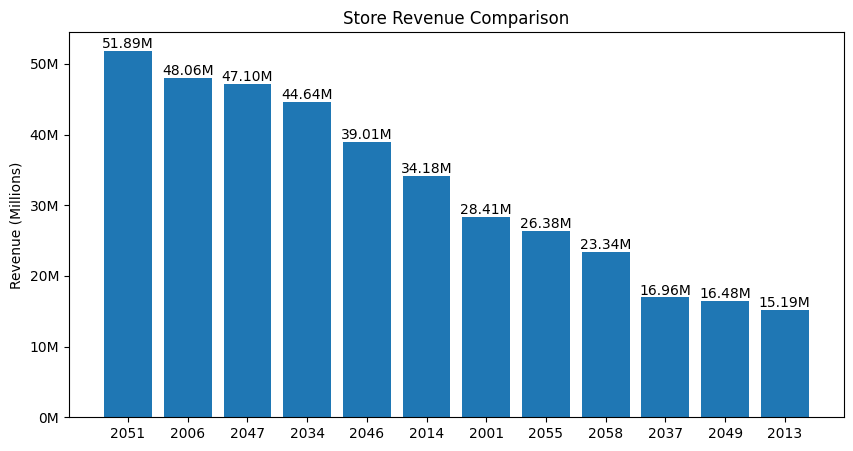

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))

bars = plt.bar(
    store_analysis_df["store_id"].astype(str),
    store_analysis_df["net_sales"]
)

plt.title("Store Revenue Comparison")
#plt.xticks(rotation=45)
plt.ylabel("Revenue (Millions)")

# Format Y-axis to Millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Add labels on top of bars (in Millions)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',           #f'{height:.2f}',   # <-- 2 decimal places
        ha='center',
        va='bottom'
    )

plt.show()

In [78]:
threshold = store_analysis_df["net_sales"].quantile(0.25)

low_perf_stores = store_analysis_df[
    store_analysis_df["net_sales"] <= threshold
]

print(low_perf_stores)

   store_id    net_sales  gross_margin  units_sold  \
5      2037  16956464.21    6422917.74      173237   
8      2049  16480964.19    6490624.44      178158   
2      2013  15185353.80    5886902.50      162587   

                        store_name         banner          province  \
5  Canadian Tire Vancouver Store 5  Canadian Tire  British Columbia   
8      Canadian Tire Laval Store 8  Canadian Tire            Quebec   
2    Canadian Tire London Store 13  Canadian Tire           Ontario   

        city postal_code   region  ... homeownership_rate  \
5  Vancouver     C0G 1S4     West  ...              0.254   
8      Laval     E8H 1X4     East  ...              0.452   
2     London     A2Y 8M5  Central  ...              0.357   

   family_with_children_pct age_25_44_pct  age_45_64_pct  \
5                     0.216         0.347          0.182   
8                     0.297         0.384          0.201   
2                     0.197         0.365          0.284   

   vehicle_o

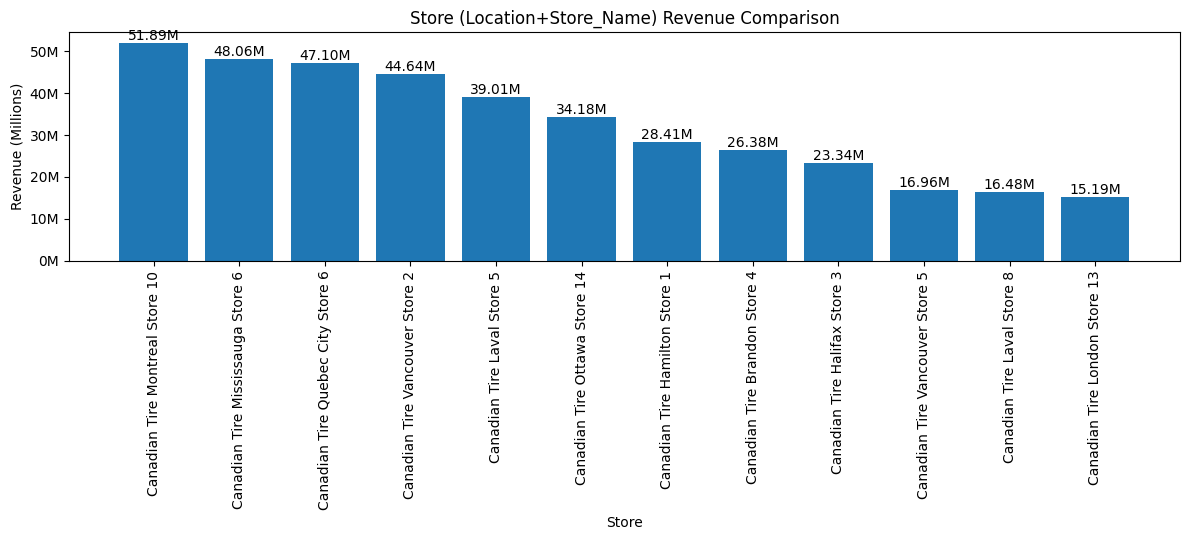

In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Sort by revenue (recommended)
store_sorted = store_analysis_df.sort_values("net_sales", ascending=False)

plt.figure(figsize=(12, 5.5))

bars = plt.bar(
    store_sorted["store_name"],
    store_sorted["net_sales"]
)

plt.title("Store (Location+Store_Name) Revenue Comparison")
plt.xlabel("Store")
plt.ylabel("Revenue (Millions)")

plt.xticks(rotation=90)

# Y-axis → Millions (0 decimals)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Add labels → Millions (2 decimals)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [80]:
# Income buckets
store_analysis_df["income_level"] = pd.qcut(
    store_analysis_df["median_household_income"],
    q=3,
    labels=["Low Income", "Mid Income", "High Income"]
)

# Competition buckets
store_analysis_df["competition_level"] = pd.qcut(
    store_analysis_df["competitor_store_count"],
    q=3,
    labels=["Low Competition", "Medium Competition", "High Competition"]
)

# Store type = use existing trade area type
store_analysis_df["store_type"] = store_analysis_df["trade_area_type"]

In [81]:
print(
    store_analysis_df.groupby("income_level")[["net_sales", "gross_margin", "units_sold"]]
    .mean()
)

                 net_sales  gross_margin  units_sold
income_level                                        
Low Income    3.103536e+07  1.192241e+07   316138.50
Mid Income    2.970556e+07  1.149230e+07   292464.25
High Income   3.716741e+07  1.391647e+07   376701.25


/tmp/ipykernel_65613/1339058393.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_analysis_df.groupby("income_level")[["net_sales", "gross_margin", "units_sold"]]


**“Stores located in higher-income areas generate significantly higher sales, indicating strong purchasing power influence.”**

**Urban vs suburban**

In [82]:
print(
    store_analysis_df.groupby("store_type")[["net_sales", "gross_margin", "units_sold"]]
    .mean()
)

               net_sales  gross_margin     units_sold
store_type                                           
rural       2.739265e+07  1.056508e+07  255431.500000
suburban    4.234031e+07  1.602234e+07  424835.166667
urban       2.070154e+07  8.015127e+06  220335.500000


**“Suburban stores outperform both urban and rural locations, likely due to larger basket sizes and higher household demand.”**

**Competition intensity**

In [83]:
print(
    store_analysis_df.groupby("competition_level")[["net_sales", "gross_margin", "units_sold"]]
    .mean()
)

                       net_sales  gross_margin     units_sold
competition_level                                            
Low Competition     3.542280e+07  1.360425e+07  345261.200000
Medium Competition  3.451743e+07  1.306017e+07  353794.666667
High Competition    2.774176e+07  1.053074e+07  288381.500000


/tmp/ipykernel_65613/4196259859.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_analysis_df.groupby("competition_level")[["net_sales", "gross_margin", "units_sold"]]


**Low competition → highest net sales**  
**High competition → lowest**

**“Stores in highly competitive areas show lower revenue, suggesting market saturation and customer dilution.”**

In [84]:
store_analysis_df["sales_per_sqft"] = (
    store_analysis_df["net_sales"] / store_analysis_df["store_size_sqft"]
)

print(
    store_analysis_df[["store_id", "store_name", "net_sales", "store_size_sqft", "sales_per_sqft"]]
    .sort_values("sales_per_sqft", ascending=False)
    .head()
)

    store_id                         store_name    net_sales  store_size_sqft  \
2       2013      Canadian Tire London Store 13  15185353.80            13060   
11      2058      Canadian Tire Halifax Store 3  23342752.20            22106   
5       2037    Canadian Tire Vancouver Store 5  16956464.21            17287   
7       2047  Canadian Tire Quebec City Store 6  47100155.75            52175   
0       2001     Canadian Tire Hamilton Store 1  28408360.69            36964   

    sales_per_sqft  
2      1162.737657  
11     1055.946449  
5       980.879517  
7       902.734178  
0       768.541302  


**“Some stores generate significantly higher revenue per square foot, indicating more efficient use of space and better product mix.”**

**Promo dependence**

In [85]:
promo_store = (
    daily_sales_df
    .assign(has_promo=daily_sales_df["promo_id"].notna())
    .groupby(["store_id", "has_promo"])["net_sales"]
    .mean()
    .unstack()
)

promo_store["promo_lift_pct"] = (
    (promo_store[True] - promo_store[False]) / promo_store[False]
) * 100

print(promo_store)

has_promo        False         True  promo_lift_pct
store_id                                           
2001       1034.056098  1088.582406        5.273051
2006       1802.266252  1723.147196       -4.389976
2013        826.145035   950.800759       15.088843
2014       1213.066752  1272.777310        4.922281
2034       1154.467691  1451.852581       25.759481
2037        803.754951   999.273423       24.325632
2046       1304.329839  1652.594986       26.700696
2047       1651.633024  2135.371860       29.288518
2049        827.698763   978.215025       18.184908
2051       1378.148516  1600.949293       16.166674
2055        891.703003  1060.209801       18.897189
2058       1332.798874  1325.215907       -0.568951


**Build store segments**

In [86]:
store_analysis_df["performance_segment"] = pd.qcut(
    store_analysis_df["net_sales"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(store_analysis_df[["store_id", "net_sales", "performance_segment"]])

    store_id    net_sales performance_segment
9       2051  51885783.70                High
1       2006  48062227.55                High
7       2047  47100155.75                High
4       2034  44641847.26                High
6       2046  39009088.81              Medium
3       2014  34183388.42              Medium
0       2001  28408360.69              Medium
10      2055  26376943.86              Medium
11      2058  23342752.20                 Low
5       2037  16956464.21                 Low
8       2049  16480964.19                 Low
2       2013  15185353.80                 Low


/tmp/ipykernel_65613/4266981640.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("income_level")["net_sales"]


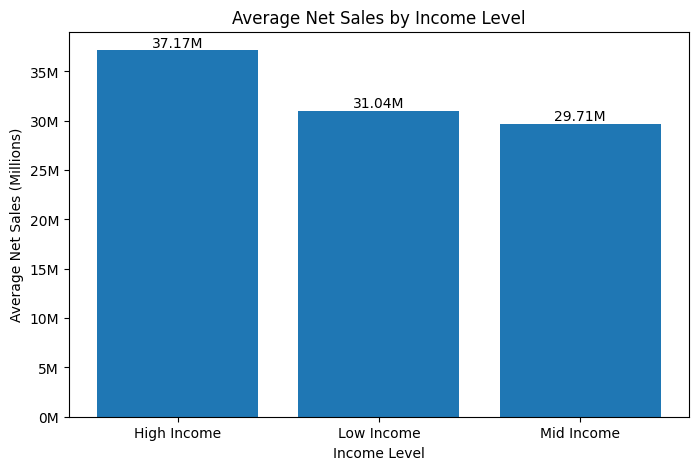

In [87]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

income_perf = (
    store_analysis_df
    .groupby("income_level")["net_sales"]
    .mean()
    .sort_values(ascending=False)   # recommended
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    income_perf.index.astype(str),
    income_perf.values
)

plt.title("Average Net Sales by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Average Net Sales (Millions)")

# Format Y-axis → Millions, 0 decimals
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Add labels on bars → Millions, 2 decimals
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.show()

/tmp/ipykernel_65613/3217181740.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("competition_level")["net_sales"]


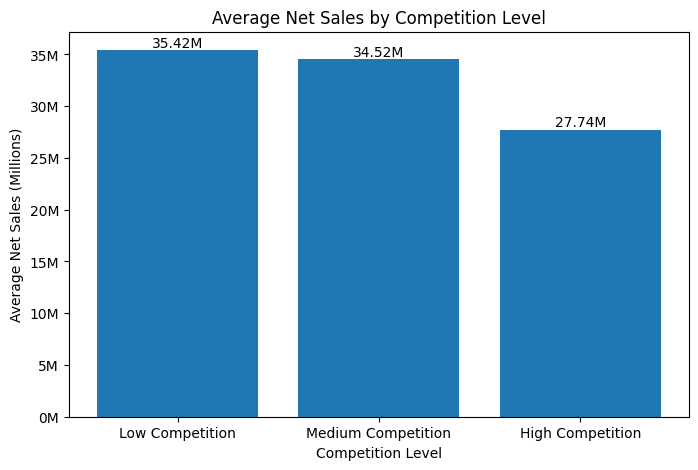

In [88]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

competition_perf = (
    store_analysis_df
    .groupby("competition_level")["net_sales"]
    .mean()
    .sort_values(ascending=False)   # optional but recommended
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    competition_perf.index.astype(str),
    competition_perf.values
)

plt.title("Average Net Sales by Competition Level")
plt.xlabel("Competition Level")
plt.ylabel("Average Net Sales (Millions)")

# Format Y-axis → Millions, 0 decimals
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Add labels on bars → Millions, 2 decimals
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.show()

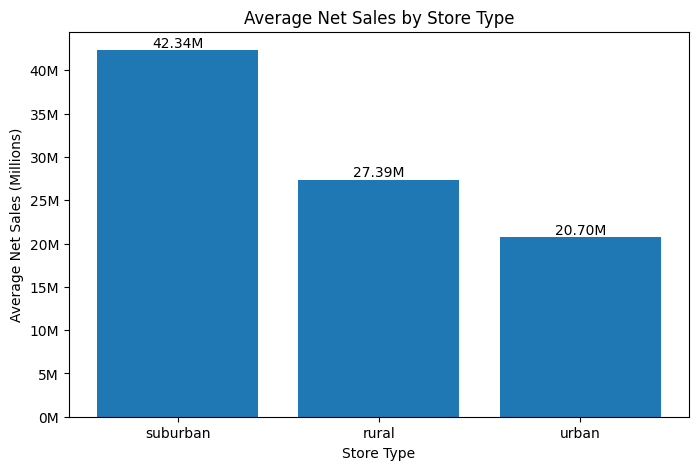

In [89]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

store_type_perf = (
    store_analysis_df
    .groupby("store_type")["net_sales"]
    .mean()
    .sort_values(ascending=False)   # recommended for readability
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    store_type_perf.index.astype(str),
    store_type_perf.values
)

plt.title("Average Net Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Net Sales (Millions)")

# Y-axis → Millions (0 decimals)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Bar labels → Millions (2 decimals)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.show()

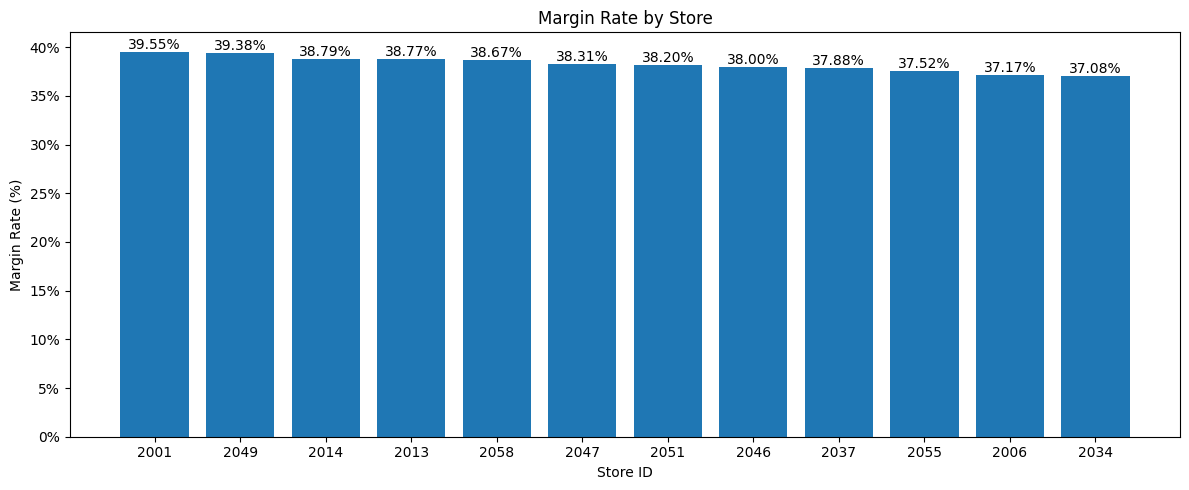

In [90]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plot_df = store_analysis_df.sort_values("margin_rate", ascending=False)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    plot_df["store_id"].astype(str),
    plot_df["margin_rate"]
)

plt.title("Margin Rate by Store")
plt.xlabel("Store ID")
plt.ylabel("Margin Rate (%)")
#plt.xticks(rotation=45, ha="right")

# Y-axis → % with 0 decimals
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

# Bar labels → % with 2 decimals
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

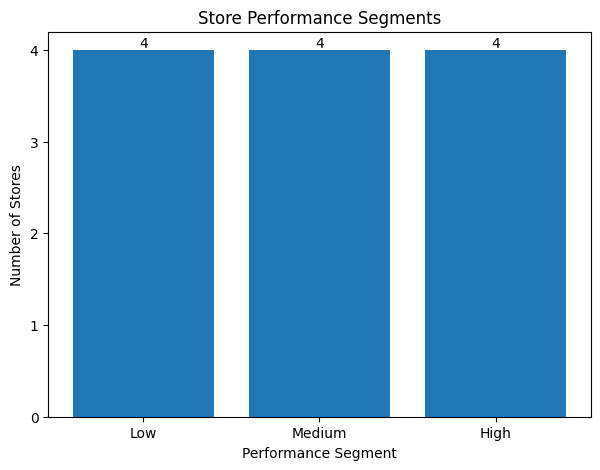

In [91]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

segment_counts = (
    store_analysis_df["performance_segment"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    segment_counts.index.astype(str),
    segment_counts.values
)

plt.title("Store Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Stores")

# Force integer ticks
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Add labels (integers)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

In [92]:
# if we want to change the thresholds for performance segment
'''
import numpy as np

conditions = [
    store_analysis_df["sales_per_sqft"] < 500,
    store_analysis_df["sales_per_sqft"] < 800,
    store_analysis_df["sales_per_sqft"] >= 800
]

labels = ["Low", "Medium", "High"]

store_analysis_df["performance_segment"] = np.select(
    conditions,
    labels,
    default="Unknown"
)
'''

'\nimport numpy as np\n\nconditions = [\n    store_analysis_df["sales_per_sqft"] < 500,\n    store_analysis_df["sales_per_sqft"] < 800,\n    store_analysis_df["sales_per_sqft"] >= 800\n]\n\nlabels = ["Low", "Medium", "High"]\n\nstore_analysis_df["performance_segment"] = np.select(\n    conditions,\n    labels,\n    default="Unknown"\n)\n'

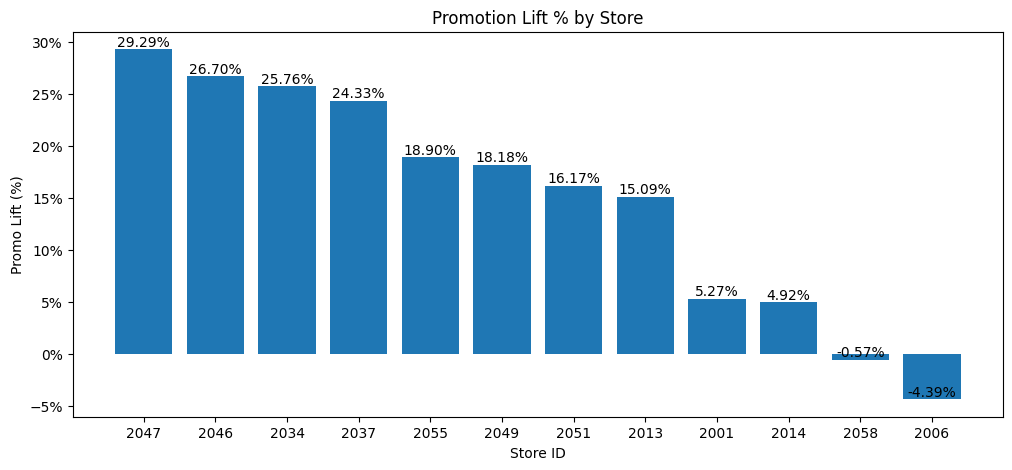

In [93]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Already sorted (good)
promo_store_plot = promo_store.sort_values("promo_lift_pct", ascending=False)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    promo_store_plot.index.astype(str),
    promo_store_plot["promo_lift_pct"]
)

plt.title("Promotion Lift % by Store")
plt.xlabel("Store ID")
plt.ylabel("Promo Lift (%)")
#plt.xticks(rotation=45, ha="right")

# Format Y-axis → % with 0 decimals
# IMPORTANT: assumes values are like 7, 15 (not 0.07)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

# Add labels → % with 2 decimals (NO *100)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [94]:
store_analysis_df.columns

Index(['store_id', 'net_sales', 'gross_margin', 'units_sold', 'store_name',
       'banner', 'province', 'city', 'postal_code', 'region', 'store_format',
       'store_size_sqft', 'opening_date', 'latitude', 'longitude',
       'trade_area_type', 'mall_flag', 'rent_cost_monthly', 'ownership_type',
       'traffic_index', 'basket_size_index', 'seasonal_affinity_index',
       'regional_performance_factor', 'median_household_income',
       'population_density', 'avg_household_size', 'homeownership_rate',
       'family_with_children_pct', 'age_25_44_pct', 'age_45_64_pct',
       'vehicle_ownership_rate', 'competitor_store_count',
       'nearby_big_box_count', 'income_index', 'competition_index',
       'margin_rate', 'income_level', 'competition_level', 'store_type',
       'sales_per_sqft', 'performance_segment'],
      dtype='object')

## **Store Efficiency Comparison**

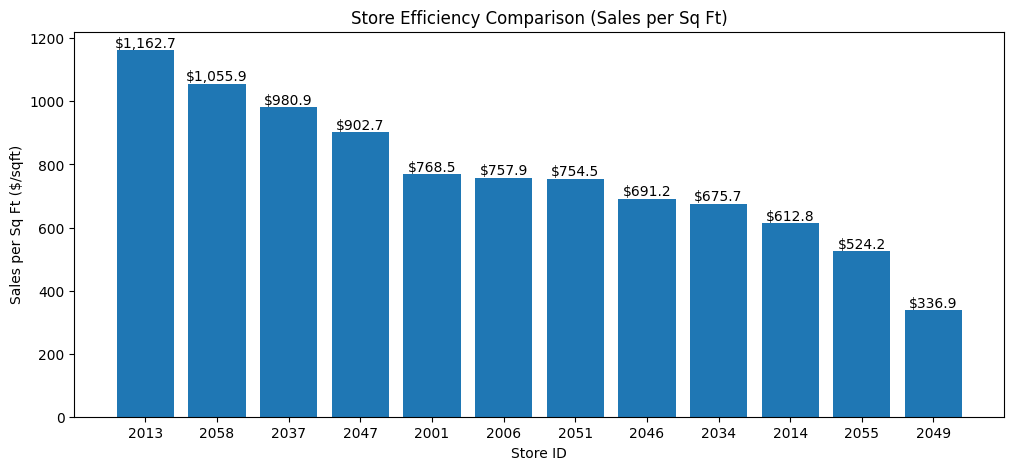

In [95]:
import matplotlib.pyplot as plt

store_efficiency = (
    store_analysis_df[["store_id", "sales_per_sqft"]]
    .sort_values("sales_per_sqft", ascending=False)   # lowest first = underperforming
)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    store_efficiency["store_id"].astype(str),
    store_efficiency["sales_per_sqft"]
)

plt.title("Store Efficiency Comparison (Sales per Sq Ft)")
plt.xlabel("Store ID")
#plt.ylabel("Sales per Sq Ft")
plt.ylabel("Sales per Sq Ft ($/sqft)")
#plt.xticks(rotation=45, ha="right")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.1f}',   # <-- adds $ and comma formatting
        ha='center',
        va='bottom'
    )

plt.show()

## **Compare stores within peer groups.**

**Example: underperforming within income + competition group**

In [96]:
peer_avg = (
    store_analysis_df
    .groupby(["income_level", "competition_level"])["sales_per_sqft"]
    .mean()
    .reset_index()
    .rename(columns={"sales_per_sqft": "peer_avg_sales_per_sqft"})
)

store_peers = store_analysis_df.merge(
    peer_avg,
    on=["income_level", "competition_level"],
    how="left"
)

store_peers["performance_gap"] = (
    store_peers["sales_per_sqft"] - store_peers["peer_avg_sales_per_sqft"]
)

underperforming_stores = store_peers.sort_values("performance_gap", ascending=True)

/tmp/ipykernel_65613/3579944275.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["income_level", "competition_level"])["sales_per_sqft"]


**Chart the gap**

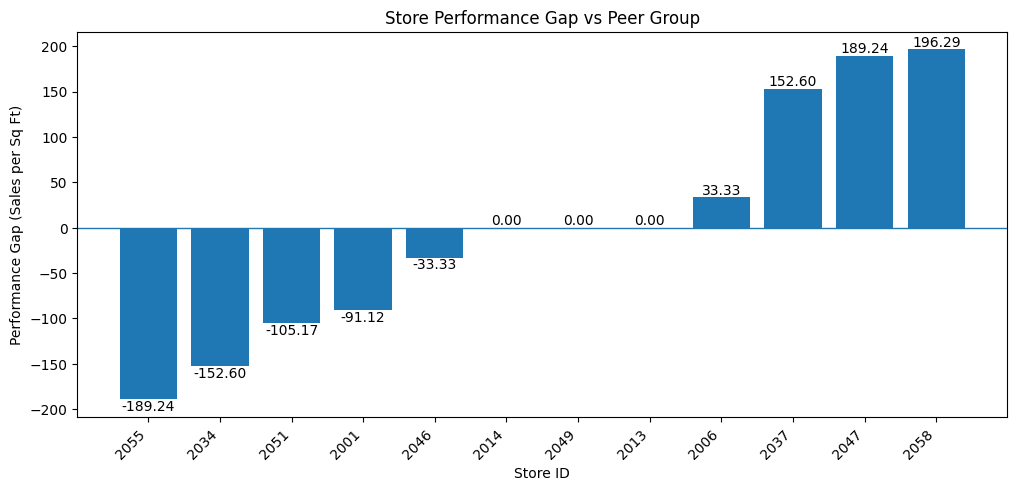

In [97]:
plt.figure(figsize=(12, 5))
bars = plt.bar(
    underperforming_stores["store_id"].astype(str),
    underperforming_stores["performance_gap"]
)

plt.title("Store Performance Gap vs Peer Group")
plt.xlabel("Store ID")
plt.ylabel("Performance Gap (Sales per Sq Ft)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom" if height >= 0 else "top"
    )

plt.axhline(0, linewidth=1)
plt.show()

- Below 0 → underperforming vs similar stores
- Above 0 → outperforming vs similar stores

if we want to say:

“These stores are underperforming after considering local conditions.”

Insight:
High revenue does not necessarily mean high performance. After normalizing for store size and peer conditions, some stores appear to underperform relative to similar locations.

Business implication:
These stores should be prioritized for operational review, localized strategy changes, or space optimization decisions.

**Use performance vs peer group**

we have:

income_level

competition_level

net_sales

define underperformance

In [98]:
peer_avg = (
    store_analysis_df
    .groupby(["income_level", "competition_level"])["net_sales"]
    .mean()
    .reset_index()
    .rename(columns={"net_sales": "peer_avg_sales"})
)

store_peers = store_analysis_df.merge(
    peer_avg,
    on=["income_level", "competition_level"],
    how="left"
)

store_peers["performance_gap"] = (
    store_peers["net_sales"] - store_peers["peer_avg_sales"]
)

/tmp/ipykernel_65613/2686929146.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["income_level", "competition_level"])["net_sales"]


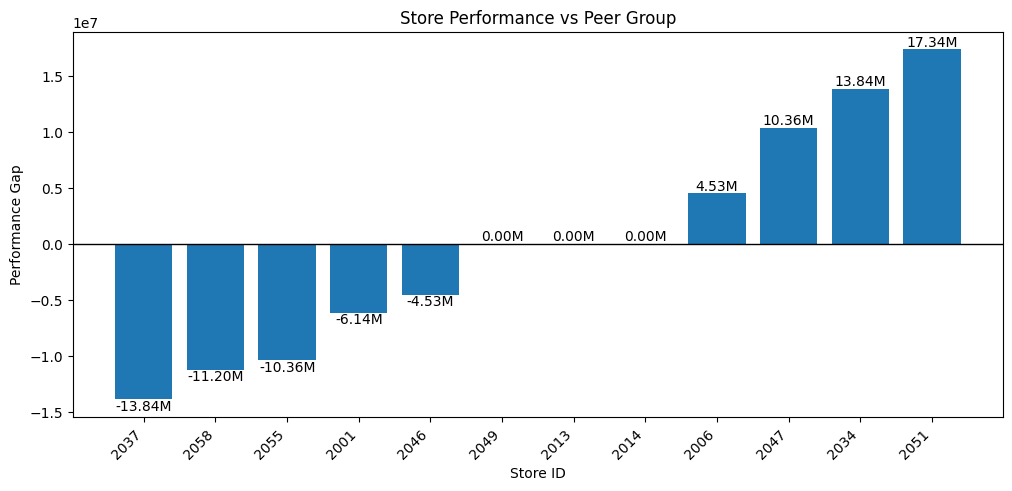

In [99]:
import matplotlib.pyplot as plt

store_peers_sorted = store_peers.sort_values("performance_gap", ascending=True)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    store_peers_sorted["store_id"].astype(str),
    store_peers_sorted["performance_gap"]
)

plt.title("Store Performance vs Peer Group")
plt.xlabel("Store ID")
plt.ylabel("Performance Gap")
plt.xticks(rotation=45, ha="right")

plt.axhline(0, color="black", linewidth=1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

plt.show()

# **Top 5 Stores with LOW Promo Dependence**

## Calculate promo dependence

In [100]:
store_promo = (
    promo_analysis_df
    .groupby(["store_id", "has_promo"])["net_sales"]
    .sum()
    .unstack()
    .fillna(0)
)

store_promo["promo_dependence_pct"] = (
    store_promo[True] / (store_promo[True] + store_promo[False]) * 100
)

## Get top 5 independent stores

In [101]:
top_independent = (
    store_promo.sort_values("promo_dependence_pct", ascending=True)
    .head(5)
)

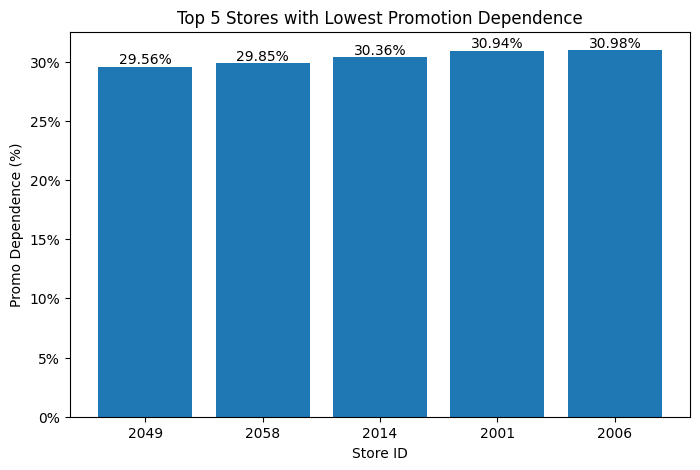

In [102]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(8, 5))

bars = plt.bar(
    top_independent.index.astype(str),
    top_independent["promo_dependence_pct"]
)

plt.title("Top 5 Stores with Lowest Promotion Dependence")
plt.xlabel("Store ID")
plt.ylabel("Promo Dependence (%)")

# Y-axis as %
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

# Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

# **Top 2 Categories with Highest Margin Rate**

## Calculate margin rate by category

In [103]:
category_margin = (
    promo_analysis_df
    .groupby("category")[["net_sales", "gross_margin"]]
    .sum()
)

category_margin["margin_rate"] = (
    category_margin["gross_margin"] / category_margin["net_sales"]
)

## Get top 2

In [104]:
top_categories = category_margin.sort_values("margin_rate", ascending=False).head(2)

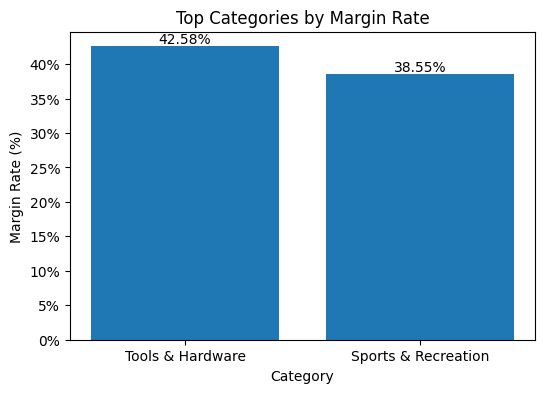

In [105]:
plt.figure(figsize=(6, 4))

bars = plt.bar(
    top_categories.index,
    top_categories["margin_rate"]
)

plt.title("Top Categories by Margin Rate")
plt.xlabel("Category")
plt.ylabel("Margin Rate (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

“These charts show that both store-level promotion dependence and category-level profitability vary significantly, reinforcing that a uniform promotion strategy would be ineffective.”

Executive-level recommendation

Reduce promotions in:
- low-dependence stores

Focus promotions on:
- high-response stores

Prioritize:
- high-margin categories

## **Compute uplift or margin per (store, category)**

In [106]:
store_cat = (
    promo_analysis_df[promo_analysis_df["has_promo"]]
    .groupby(["store_id", "category"])["units_sold"]
    .mean()
    .reset_index()
)

## Filter top 5 stores

In [107]:
top_stores = [2047, 2046, 2034, 2037, 2055]

store_cat = store_cat[store_cat["store_id"].isin(top_stores)]

## Get TOP 2 categories per store

In [108]:
top2_per_store = (
    store_cat.sort_values(["store_id", "units_sold"], ascending=[True, False])
    .groupby("store_id")
    .head(2)
)

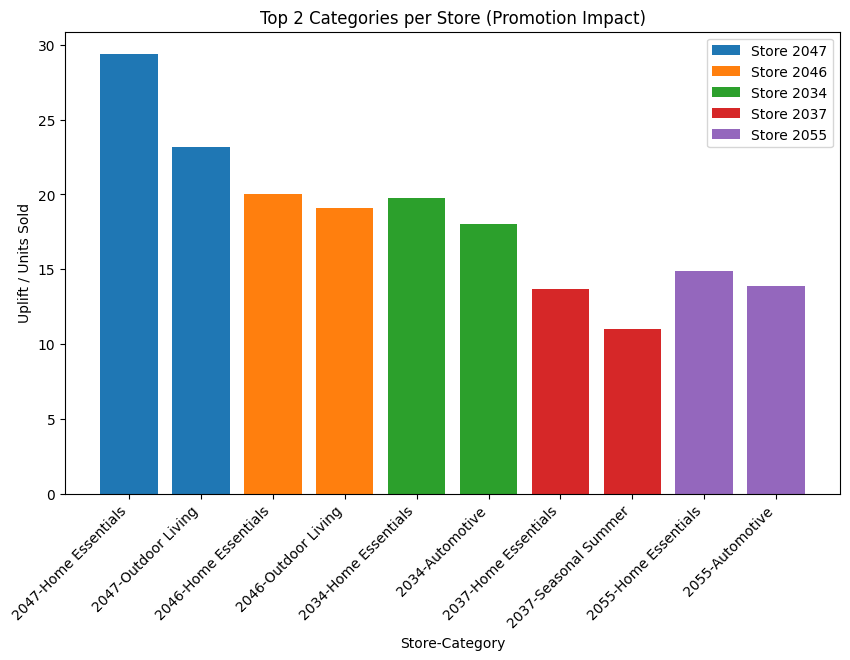

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for store in top_stores:
    subset = top2_per_store[top2_per_store["store_id"] == store]
    plt.bar(
        [f"{store}-{cat}" for cat in subset["category"]],
        subset["units_sold"],
        label=f"Store {store}"
    )

plt.title("Top 2 Categories per Store (Promotion Impact)")
plt.xlabel("Store-Category")
plt.ylabel("Uplift / Units Sold")
plt.xticks(rotation=45, ha="right")

plt.legend()
plt.show()

generate the table

In [110]:
top2_table = (
    top2_per_store
    .groupby("store_id")["category"]
    .apply(list)
    .reset_index()
)

top2_table[["Top 1", "Top 2"]] = pd.DataFrame(
    top2_table["category"].tolist(), index=top2_table.index
)

top2_table = top2_table.drop(columns=["category"])

print(top2_table)

   store_id            Top 1            Top 2
0      2034  Home Essentials       Automotive
1      2037  Home Essentials  Seasonal Summer
2      2046  Home Essentials   Outdoor Living
3      2047  Home Essentials   Outdoor Living
4      2055  Home Essentials       Automotive


**Key idea**

filter categories by:

margin_rate ≥ threshold (e.g., 25%)

Then rank by:

uplift (or units)

## Compute BOTH uplift + margin

In [111]:
store_cat_perf = (
    promo_analysis_df[promo_analysis_df["has_promo"]]
    .groupby(["store_id", "category"])[["net_sales", "gross_margin", "units_sold"]]
    .sum()
    .reset_index()
)

store_cat_perf["margin_rate"] = (
    store_cat_perf["gross_margin"] / store_cat_perf["net_sales"]
)

Add uplift

In [112]:
store_cat_perf["uplift_pct"] = store_cat_perf["units_sold"] / store_cat_perf["units_sold"].mean()

## FILTER by profitability

In [113]:
margin_threshold = 0.25   # 25%

filtered = store_cat_perf[
    store_cat_perf["margin_rate"] >= margin_threshold
]

## Keep only my top stores

In [114]:
top_stores = [2047, 2046, 2034, 2037, 2055]

filtered = filtered[filtered["store_id"].isin(top_stores)]

## Get TOP 2 categories per store (by uplift)

In [115]:
top2_profitable = (
    filtered.sort_values(["store_id", "uplift_pct"], ascending=[True, False])
    .groupby("store_id")
    .head(2)
)

In [116]:
top2_table = (
    top2_profitable
    .groupby("store_id")["category"]
    .apply(list)
    .reset_index()
)

top2_table[["Top 1", "Top 2"]] = pd.DataFrame(
    top2_table["category"].tolist(), index=top2_table.index
)

top2_table = top2_table.drop(columns=["category"])

print(top2_table)

   store_id             Top 1             Top 2
0      2034   Home Essentials  Tools & Hardware
1      2037  Tools & Hardware        Automotive
2      2046  Tools & Hardware    Outdoor Living
3      2047   Home Essentials  Tools & Hardware
4      2055  Tools & Hardware   Home Essentials


## New Table :(with margin rate inside labels)

In [117]:
# Step 1: Create label with category + margin %
top2_profitable["category_with_margin"] = (
    top2_profitable["category"] + " (" +
    (top2_profitable["margin_rate"] * 100).round(2).astype(str) + "%)"
)

# Step 2: Group and collect top 2
top2_table = (
    top2_profitable
    .groupby("store_id")["category_with_margin"]
    .apply(list)
    .reset_index()
)

# Step 3: Split into Top 1 and Top 2
top2_table[["Top 1", "Top 2"]] = pd.DataFrame(
    top2_table["category_with_margin"].tolist(),
    index=top2_table.index
)

# Step 4: Clean up
top2_table = top2_table.drop(columns=["category_with_margin"])

print(top2_table)

   store_id                      Top 1                      Top 2
0      2034   Home Essentials (26.97%)  Tools & Hardware (35.46%)
1      2037  Tools & Hardware (33.51%)        Automotive (31.58%)
2      2046  Tools & Hardware (36.68%)    Outdoor Living (28.34%)
3      2047   Home Essentials (26.61%)  Tools & Hardware (36.26%)
4      2055  Tools & Hardware (33.71%)   Home Essentials (28.64%)


## New Table :(with margin rate inside labels)+ (add uplift)

In [118]:
# Step 1: Create label with category + margin %

top2_profitable["category_label"] = (
    top2_profitable["category"] +
    " (" + (top2_profitable["margin_rate"]*100).round(1).astype(str) + "% margin, " +
    (top2_profitable["uplift_pct"]).round(1).astype(str) + "% uplift)"
)

# Step 2: Group and collect top 2
top2_table = (
    top2_profitable
    .groupby("store_id")["category_label"]
    .apply(list)
    .reset_index()
)

# Step 3: Split into Top 1 and Top 2
top2_table[["Top 1", "Top 2"]] = pd.DataFrame(
    top2_table["category_label"].tolist(),
    index=top2_table.index
)

# Step 4: Clean up
top2_table = top2_table.drop(columns=["category_label"])

print(top2_table)

   store_id                                         Top 1  \
0      2034   Home Essentials (27.0% margin, 2.7% uplift)   
1      2037  Tools & Hardware (33.5% margin, 1.3% uplift)   
2      2046  Tools & Hardware (36.7% margin, 1.9% uplift)   
3      2047   Home Essentials (26.6% margin, 2.8% uplift)   
4      2055  Tools & Hardware (33.7% margin, 2.0% uplift)   

                                          Top 2  
0  Tools & Hardware (35.5% margin, 2.5% uplift)  
1        Automotive (31.6% margin, 0.2% uplift)  
2    Outdoor Living (28.3% margin, 1.0% uplift)  
3  Tools & Hardware (36.3% margin, 2.6% uplift)  
4   Home Essentials (28.6% margin, 1.6% uplift)  


In [119]:
top2_profitable["category_label"] = (
    top2_profitable["category"] +
    " (" + (top2_profitable["margin_rate"]*100).round(1).astype(str) + "% margin, " +
    (top2_profitable["uplift_pct"]).round(1).astype(str) + "% uplift)"
)

print(top2_profitable)

    store_id          category   net_sales  gross_margin  units_sold  \
26      2034   Home Essentials  1989977.15     536789.10       49316   
31      2034  Tools & Hardware  6885644.95    2441632.14       45998   
37      2037  Tools & Hardware  3377966.13    1131810.82       24861   
32      2037        Automotive   249324.91      78739.66        4226   
44      2046  Tools & Hardware  4865616.27    1784941.04       35687   
40      2046    Outdoor Living  2966401.64     840624.36       18779   
46      2047   Home Essentials  2192218.23     583246.42       52668   
51      2047  Tools & Hardware  6907391.39    2504778.13       47506   
70      2055  Tools & Hardware  5067279.90    1708291.31       37421   
65      2055   Home Essentials  1226208.54     351161.91       30456   

    margin_rate  uplift_pct       category_with_margin  \
26     0.269746    2.659544   Home Essentials (26.97%)   
31     0.354597    2.480609  Tools & Hardware (35.46%)   
37     0.335057    1.340720  Tool

### Function >> adds value labels on top of bars

In [120]:
def add_value_labels(ax, fmt="{:.1f}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

## Average Net Sales by Store Type

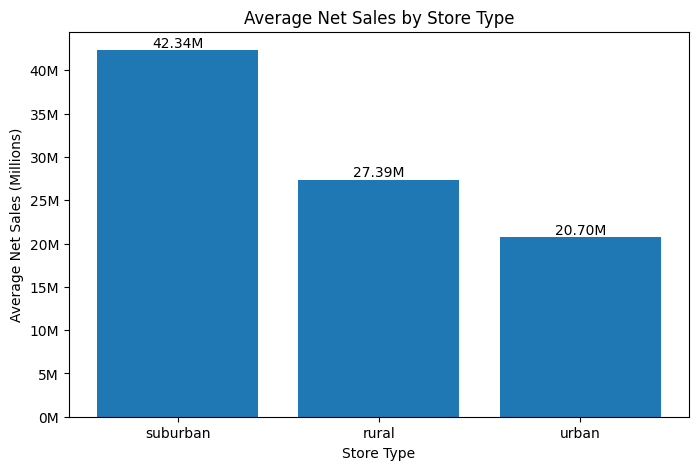

In [121]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Optional: sort
store_type_perf_sorted = store_type_perf.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    store_type_perf_sorted.index.astype(str),
    store_type_perf_sorted.values
)

ax.set_title("Average Net Sales by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Net Sales (Millions)")

# Format Y-axis → Millions, 0 decimals
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# Add labels → Millions, 2 decimals
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height/1e6:.2f}M',
        ha='center',
        va='bottom'
    )

plt.show()

# **Project 4: Scenario Simulator**

In [122]:
print(promo_analysis_df.columns)

Index(['sales_date', 'store_id', 'product_id', 'units_sold', 'unit_price',
       'discount_amount_x', 'gross_sales', 'net_sales', 'cost_of_goods_sold',
       'gross_margin', 'promo_id', 'channel', 'return_flag', 'has_promo',
       'margin_rate', 'category', 'subcategory', 'promo_type', 'flyer_flag',
       'discount_percent', 'discount_amount_y'],
      dtype='object')


## **Build a baseline scenario dataset**

In [123]:
scenario_base_df = (
    promo_analysis_df
    .groupby(
        ["store_id", "category", "promo_type", "has_promo"],
        dropna=False
    )[["units_sold", "net_sales", "gross_margin", "discount_percent"]] #, "discount_amount_y"]]
    .mean()
    .reset_index()
)

scenario_base_df["promo_type"] = scenario_base_df["promo_type"].fillna("No Promo")
scenario_base_df["discount_percent"] = scenario_base_df["discount_percent"].fillna(0)
#scenario_base_df["discount_amount_y"] = scenario_base_df["discount_amount_y"].fillna(0)

print(scenario_base_df.head())

# discount_amount_x = actual discount amount in the sales row [daily_sales_df]
# discount_amount_y = promotion definition amount like "$5 off" [promotion_df]

   store_id    category  promo_type  has_promo  units_sold   net_sales  \
0      2001  Automotive        bogo       True   18.222222  823.883472   
1      2001  Automotive  dollar_off       True   13.247126  721.091667   
2      2001  Automotive       flyer       True   14.235714  774.612429   
3      2001  Automotive     loyalty       True    3.863095  236.893095   
4      2001  Automotive     pct_off       True    8.331250  474.096417   

   gross_margin  discount_percent  
0     64.069306         27.883333  
1    184.664828          0.000000  
2    184.222738         15.707143  
3     75.554345          7.110714  
4    126.348542         12.947500  


We want a table at a practical decision level, for example:

- store
- category
- promo status
- discount level
- average units
- average sales
- average margin

In [124]:
# it can help to avoid confusion
'''
promo_analysis_df = promo_analysis_df.rename(columns={
    "discount_amount_x": "realized_discount_amount",
    "discount_amount_y": "promo_defined_discount_amount"
})
'''

'\npromo_analysis_df = promo_analysis_df.rename(columns={\n    "discount_amount_x": "realized_discount_amount",\n    "discount_amount_y": "promo_defined_discount_amount"\n})\n'

## **Create a simple scenario simulation function**

In [125]:
def simulate_promo_scenario(
    df,
    category=None,
    store_id=None,
    base_discount=10,
    new_discount=20,
    uplift_factor=1.2,
    margin_penalty_factor=1.0
):
    sim_df = df.copy()

    # Filter scenario scope
    if category is not None:
        sim_df = sim_df[sim_df["category"] == category].copy()

    if store_id is not None:
        sim_df = sim_df[sim_df["store_id"] == store_id].copy()

    # Baseline metrics
    baseline_units = sim_df["units_sold"].sum()
    baseline_sales = sim_df["net_sales"].sum()
    baseline_margin = sim_df["gross_margin"].sum()

    # Discount change ratio
    discount_change = max(0, new_discount - base_discount)

    # Simple uplift logic:
    # every extra 1% discount increases units by uplift_factor%
    demand_multiplier = 1 + (discount_change / 100.0) * uplift_factor

    # Margin compression logic:
    # every extra 1% discount reduces margin by margin_penalty_factor%
    margin_multiplier = max(0, 1 - (discount_change / 100.0) * margin_penalty_factor)

    sim_df["sim_units_sold"] = sim_df["units_sold"] * demand_multiplier
    sim_df["sim_net_sales"] = sim_df["net_sales"] * demand_multiplier * (1 - discount_change / 100.0)
    sim_df["sim_gross_margin"] = sim_df["gross_margin"] * demand_multiplier * margin_multiplier

    result = {
        "scope_category": category if category is not None else "All",
        "scope_store_id": store_id if store_id is not None else "All",
        "baseline_units_sold": round(baseline_units, 2),
        "baseline_net_sales": round(baseline_sales, 2),
        "baseline_gross_margin": round(baseline_margin, 2),
        "sim_units_sold": round(sim_df["sim_units_sold"].sum(), 2),
        "sim_net_sales": round(sim_df["sim_net_sales"].sum(), 2),
        "sim_gross_margin": round(sim_df["sim_gross_margin"].sum(), 2)
    }

    result["units_delta_pct"] = round(
        ((result["sim_units_sold"] - result["baseline_units_sold"]) / result["baseline_units_sold"]) * 100,
        2
    ) if result["baseline_units_sold"] > 0 else 0

    result["sales_delta_pct"] = round(
        ((result["sim_net_sales"] - result["baseline_net_sales"]) / result["baseline_net_sales"]) * 100,
        2
    ) if result["baseline_net_sales"] > 0 else 0

    result["margin_delta_pct"] = round(
        ((result["sim_gross_margin"] - result["baseline_gross_margin"]) / result["baseline_gross_margin"]) * 100,
        2
    ) if result["baseline_gross_margin"] > 0 else 0

    return pd.DataFrame([result])

## **Test scenarios**

**Scenario A: Outdoor Living discount increase**

In [126]:
scenario_a = simulate_promo_scenario(
    scenario_base_df,
    category="Outdoor Living",
    base_discount=10,
    new_discount=20,
    uplift_factor=1.5,
    margin_penalty_factor=1.1
)

print(scenario_a)

   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          822.32      155226.08          49075.42   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             15.0              3.5              2.35  


**Scenario B: Automotive discount increase**

In [127]:
scenario_b = simulate_promo_scenario(
    scenario_base_df,
    category="Automotive",
    base_discount=10,
    new_discount=20,
    uplift_factor=0.7,
    margin_penalty_factor=1.1
)

print(scenario_b)

  scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0     Automotive            All               1039.6            55573.47   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               13196.74         1112.37       53517.25          12567.25   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0              7.0             -3.7             -4.77  


## **Compare multiple scenarios together**

In [128]:
scenario_results = pd.concat([scenario_a, scenario_b], ignore_index=True)
print(scenario_results)

   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   
1      Automotive            All              1039.60            55573.47   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          822.32      155226.08          49075.42   
1               13196.74         1112.37       53517.25          12567.25   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             15.0              3.5              2.35  
1              7.0             -3.7             -4.77  


- **Outdoor Living responds more strongly**

- **Automotive gains less volume but still loses margin**

**- That matches Project 2 findings.**

## **Plot scenario comparison**

**Units sold impact**

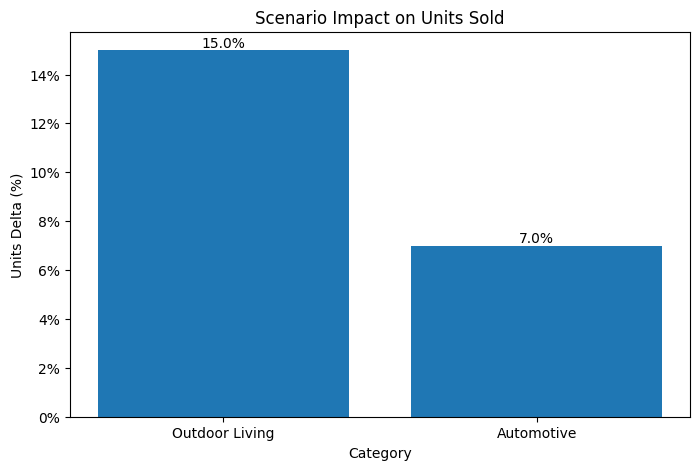

In [129]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

scenario_results_sorted = scenario_results.sort_values(
    by="units_delta_pct", ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    scenario_results_sorted["scope_category"],
    scenario_results_sorted["units_delta_pct"]
)

plt.title("Scenario Impact on Units Sold")
plt.xlabel("Category")
plt.ylabel("Units Delta (%)")
#plt.xticks(rotation=45, ha="right")

# FIXED Y-axis (values already in % form)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

# FIXED labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

**Gross margin impact**

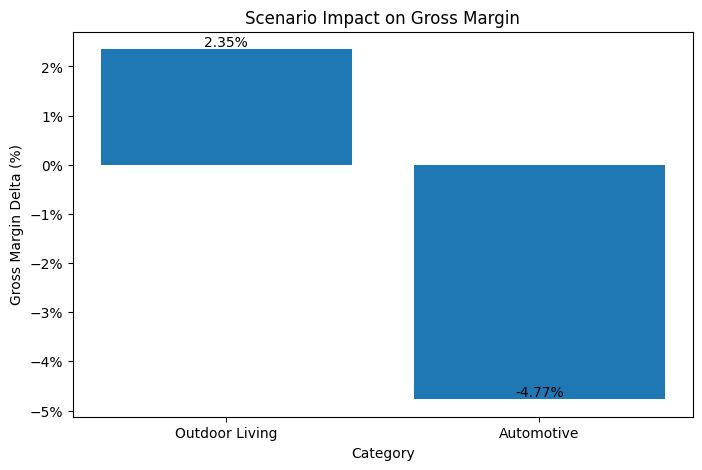

In [130]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Sort for better storytelling
scenario_results_sorted = scenario_results.sort_values(
    by="margin_delta_pct", ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    scenario_results_sorted["scope_category"],
    scenario_results_sorted["margin_delta_pct"]
)

plt.title("Scenario Impact on Gross Margin")
plt.xlabel("Category")
plt.ylabel("Gross Margin Delta (%)")
#plt.xticks(rotation=45, ha="right")

# Format Y-axis → % with 0 decimals
# IMPORTANT: assuming values are already like 7, 15 (not 0.07)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(100, decimals=0))

# Add labels → % with 2 decimals (NO *100 here)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

## **Add an inventory scenario**

To make the project stronger.

Example:
- **What if we increase inventory by 20% for Seasonal Winter products?**

Using the **inventory data**:

In [131]:
inventory_scenario_df = inventory_df.merge(
    products_df[["product_id", "category"]],
    on="product_id",
    how="left"
)

winter_inventory = inventory_scenario_df[inventory_scenario_df["category"] == "Seasonal Winter"].copy()

baseline_stock = winter_inventory["opening_stock"].sum()
sim_stock = baseline_stock * 1.20

print("Baseline opening stock:", round(baseline_stock, 2))
print("Simulated opening stock after +20%:", round(sim_stock, 2))

Baseline opening stock: 651828
Simulated opening stock after +20%: 782193.6


**Add a simple business interpretation**

In [132]:
stock_increase_pct = ((sim_stock - baseline_stock) / baseline_stock) * 100
print("Inventory increase %:", round(stock_increase_pct, 2))

Inventory increase %: 20.0


**“Increasing pre-season winter inventory by 20% reduces stockout risk during expected snow-driven demand spikes.”**

## **Build a scenario summary table**

In [133]:
scenario_summary = pd.DataFrame([
    {
        "scenario": "Outdoor Living discount 10% -> 20%",
        "expected_result": "High unit uplift, moderate margin pressure"
    },
    {
        "scenario": "Automotive discount 10% -> 20%",
        "expected_result": "Low unit uplift, unnecessary margin loss"
    },
    {
        "scenario": "Seasonal Winter inventory +20%",
        "expected_result": "Lower stockout risk during peak season"
    }
])

print(scenario_summary)

                             scenario  \
0  Outdoor Living discount 10% -> 20%   
1      Automotive discount 10% -> 20%   
2      Seasonal Winter inventory +20%   

                              expected_result  
0  High unit uplift, moderate margin pressure  
1    Low unit uplift, unnecessary margin loss  
2      Lower stockout risk during peak season  


- **turn insights into decisions**
- **model trade-offs**
- **advise leadership on actions before they happen**

“In the fourth project, a scenario simulator was built to support **what-if decision making**. Using outputs from **forecasting**, **promotion analysis**, and **store performance analysis**, I modeled how changes in **discounting**, **category targeting**, and **inventory levels** would likely affect **unit sales**, **revenue**, and **margin**. This way, we can move beyond **descriptive analytics** and **simulate the business impact of potential decisions before implementation.**”

Recommendation examples:

- **“Aggressive discounting should be concentrated in categories with high promotional elasticity, such as Outdoor Living, while categories like Automotive should be protected from excessive discounting.”**

- **“Inventory increases should be targeted to categories with forecasted peak demand and high stockout risk, especially weather-sensitive winter products.”**

In [134]:
scenario_summary.to_csv("scenario_summary.csv", index=False)

## **Build simple AI-style interface**

To have a simple AI-style decision assistant,

The idea is:
- user asks a business-style question
- created Python function detects the scenario
- it runs the simulator
- it returns a plain-English recommendation

**Lightweight simulation of an AI assistant:**

- **understands a few business question patterns**
- **runs your scenario logic**
- **explains the result in executive language**

## **make sure the scenario base exists**

In [135]:
scenario_base_df = (
    promo_analysis_df
    .groupby(
        ["store_id", "category", "promo_type", "has_promo"],
        dropna=False
    )[["units_sold", "net_sales", "gross_margin", "discount_percent"]]
    .mean()
    .reset_index()
)

scenario_base_df["promo_type"] = scenario_base_df["promo_type"].fillna("No Promo")
scenario_base_df["discount_percent"] = scenario_base_df["discount_percent"].fillna(0)

print(scenario_base_df.head())

   store_id    category  promo_type  has_promo  units_sold   net_sales  \
0      2001  Automotive        bogo       True   18.222222  823.883472   
1      2001  Automotive  dollar_off       True   13.247126  721.091667   
2      2001  Automotive       flyer       True   14.235714  774.612429   
3      2001  Automotive     loyalty       True    3.863095  236.893095   
4      2001  Automotive     pct_off       True    8.331250  474.096417   

   gross_margin  discount_percent  
0     64.069306         27.883333  
1    184.664828          0.000000  
2    184.222738         15.707143  
3     75.554345          7.110714  
4    126.348542         12.947500  


## **Keep the simulator function**

In [136]:
import pandas as pd
import numpy as np

def simulate_promo_scenario(
    df,
    category=None,
    store_id=None,
    base_discount=10,
    new_discount=20,
    uplift_factor=1.2,
    margin_penalty_factor=1.0
):
    sim_df = df.copy()

    if category is not None:
        sim_df = sim_df[sim_df["category"] == category].copy()

    if store_id is not None:
        sim_df = sim_df[sim_df["store_id"] == store_id].copy()

    baseline_units = sim_df["units_sold"].sum()
    baseline_sales = sim_df["net_sales"].sum()
    baseline_margin = sim_df["gross_margin"].sum()

    discount_change = max(0, new_discount - base_discount)

    demand_multiplier = 1 + (discount_change / 100.0) * uplift_factor
    margin_multiplier = max(0, 1 - (discount_change / 100.0) * margin_penalty_factor)

    sim_df["sim_units_sold"] = sim_df["units_sold"] * demand_multiplier
    sim_df["sim_net_sales"] = sim_df["net_sales"] * demand_multiplier * (1 - discount_change / 100.0)
    sim_df["sim_gross_margin"] = sim_df["gross_margin"] * demand_multiplier * margin_multiplier

    result = {
        "scope_category": category if category is not None else "All",
        "scope_store_id": store_id if store_id is not None else "All",
        "baseline_units_sold": round(baseline_units, 2),
        "baseline_net_sales": round(baseline_sales, 2),
        "baseline_gross_margin": round(baseline_margin, 2),
        "sim_units_sold": round(sim_df["sim_units_sold"].sum(), 2),
        "sim_net_sales": round(sim_df["sim_net_sales"].sum(), 2),
        "sim_gross_margin": round(sim_df["sim_gross_margin"].sum(), 2)
    }

    result["units_delta_pct"] = round(
        ((result["sim_units_sold"] - result["baseline_units_sold"]) / result["baseline_units_sold"]) * 100,
        2
    ) if result["baseline_units_sold"] > 0 else 0

    result["sales_delta_pct"] = round(
        ((result["sim_net_sales"] - result["baseline_net_sales"]) / result["baseline_net_sales"]) * 100,
        2
    ) if result["baseline_net_sales"] > 0 else 0

    result["margin_delta_pct"] = round(
        ((result["sim_gross_margin"] - result["baseline_gross_margin"]) / result["baseline_gross_margin"]) * 100,
        2
    ) if result["baseline_gross_margin"] > 0 else 0

    return pd.DataFrame([result])

## **build the AI-style explanation layer**

In [137]:
def generate_business_recommendation(result_row):
    category = result_row["scope_category"]
    store_id = result_row["scope_store_id"]
    units_delta = result_row["units_delta_pct"]
    sales_delta = result_row["sales_delta_pct"]
    margin_delta = result_row["margin_delta_pct"]

    scope_text = f"category '{category}'" if category != "All" else "the selected portfolio"
    if store_id != "All":
        scope_text += f" in store {store_id}"

    summary = (
        f"For {scope_text}, the simulated scenario suggests units sold may change by "
        f"{units_delta:.2f}%, net sales by {sales_delta:.2f}%, and gross margin by {margin_delta:.2f}%."
    )

    if units_delta > 0 and margin_delta > 0:
        recommendation = (
            "This looks like a favorable scenario, as it improves both demand and profitability. "
            "It may be worth testing in a controlled pilot."
        )
    elif units_delta > 0 and margin_delta < 0:
        recommendation = (
            "This scenario appears to increase demand, but at the cost of lower profitability. "
            "It may be useful for seasonal clearance or traffic-driving periods, but should be applied selectively."
        )
    elif units_delta <= 0 and margin_delta < 0:
        recommendation = (
            "This scenario appears unattractive, as it weakens both demand and margin. "
            "It is not recommended without a stronger strategic reason."
        )
    else:
        recommendation = (
            "This scenario has mixed results. It may support a niche objective, but would require closer review before rollout."
        )

    return summary + " " + recommendation

## **build a simple rule-based question parser**

In [138]:
def ask_decision_assistant(question, scenario_df):
    q = question.lower()

    categories = [
        "automotive",
        "home essentials",
        "outdoor living",
        "seasonal summer",
        "seasonal winter",
        "sports & recreation",
        "tools & hardware"
    ]

    detected_category = None
    for cat in categories:
        if cat in q:
            detected_category = cat.title()
            if cat == "home essentials":
                detected_category = "Home Essentials"
            elif cat == "outdoor living":
                detected_category = "Outdoor Living"
            elif cat == "seasonal summer":
                detected_category = "Seasonal Summer"
            elif cat == "seasonal winter":
                detected_category = "Seasonal Winter"
            elif cat == "sports & recreation":
                detected_category = "Sports & Recreation"
            elif cat == "tools & hardware":
                detected_category = "Tools & Hardware"
            elif cat == "automotive":
                detected_category = "Automotive"
            break

    # discount extraction
    import re
    percents = re.findall(r"(\d+)\s*%", q)
    if len(percents) >= 2:
        base_discount = int(percents[0])
        new_discount = int(percents[1])
    else:
        base_discount = 10
        new_discount = 20

    # category-specific uplift assumptions based on your Project 2 findings
    uplift_map = {
        "Outdoor Living": 1.8,
        "Sports & Recreation": 1.4,
        "Seasonal Summer": 1.35,
        "Seasonal Winter": 1.3,
        "Tools & Hardware": 1.2,
        "Home Essentials": 1.0,
        "Automotive": 0.8
    }

    uplift_factor = uplift_map.get(detected_category, 1.2)
    margin_penalty_factor = 1.0

    result = simulate_promo_scenario(
        scenario_df,
        category=detected_category,
        base_discount=base_discount,
        new_discount=new_discount,
        uplift_factor=uplift_factor,
        margin_penalty_factor=margin_penalty_factor
    )

    explanation = generate_business_recommendation(result.iloc[0])

    return result, explanation

## **Example questions**

In [139]:
result1, explanation1 = ask_decision_assistant(
    "What happens if we increase discount from 10% to 20% for Outdoor Living?",
    scenario_base_df
)

print(result1)
print()
print(explanation1)

   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          843.77      159275.46          50921.44   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             18.0              6.2               6.2  

For category 'Outdoor Living', the simulated scenario suggests units sold may change by 18.00%, net sales by 6.20%, and gross margin by 6.20%. This looks like a favorable scenario, as it improves both demand and profitability. It may be worth testing in a controlled pilot.


In [140]:
result2, explanation2 = ask_decision_assistant(
    "Should we increase discount from 10% to 20% for Automotive?",
    scenario_base_df
)

print(result2)
print()
print(explanation2)

  scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0     Automotive            All               1039.6            55573.47   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               13196.74         1122.77       54017.41          12827.23   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0              8.0             -2.8              -2.8  

For category 'Automotive', the simulated scenario suggests units sold may change by 8.00%, net sales by -2.80%, and gross margin by -2.80%. This scenario appears to increase demand, but at the cost of lower profitability. It may be useful for seasonal clearance or traffic-driving periods, but should be applied selectively.


In [141]:
question = input("Ask a business question: ")

result, explanation = ask_decision_assistant(question, scenario_base_df)

print("\nScenario Result:")
print(result)

print("\nAI-Style Recommendation:")
print(explanation)

Ask a business question: “What happens if we increase discount from 10% to 20% for Outdoor Living?”

Scenario Result:
   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          843.77      159275.46          50921.44   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             18.0              6.2               6.2  

AI-Style Recommendation:
For category 'Outdoor Living', the simulated scenario suggests units sold may change by 18.00%, net sales by 6.20%, and gross margin by 6.20%. This looks like a favorable scenario, as it improves both demand and profitability. It may be worth testing in a controlled pilot.


User asks:

“What happens if we increase discount from 10% to 20% for Outdoor Living?”

System answers:

“For category 'Outdoor Living', the simulated scenario suggests units sold may change by X%, net sales by Y%, and gross margin by Z%. This scenario appears to increase demand, but at the cost of lower profitability. It may be useful for seasonal clearance or traffic-driving periods, but should be applied selectively.

In [142]:
question = "What happens if we increase discount from 10% to 20% for Outdoor Living?"

result, explanation = ask_decision_assistant(question, scenario_base_df)

print("\nScenario Result:")
print(result)

print("\nAI-Style Recommendation:")
print(explanation)


Scenario Result:
   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          843.77      159275.46          50921.44   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             18.0              6.2               6.2  

AI-Style Recommendation:
For category 'Outdoor Living', the simulated scenario suggests units sold may change by 18.00%, net sales by 6.20%, and gross margin by 6.20%. This looks like a favorable scenario, as it improves both demand and profitability. It may be worth testing in a controlled pilot.


In [143]:
question = "What happens if we increase discount from 10% to 20% for Automotive?"

result, explanation = ask_decision_assistant(question, scenario_base_df)

print("\nScenario Result:")
print(result)

print("\nAI-Style Recommendation:")
print(explanation)


Scenario Result:
  scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0     Automotive            All               1039.6            55573.47   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               13196.74         1122.77       54017.41          12827.23   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0              8.0             -2.8              -2.8  

AI-Style Recommendation:
For category 'Automotive', the simulated scenario suggests units sold may change by 8.00%, net sales by -2.80%, and gross margin by -2.80%. This scenario appears to increase demand, but at the cost of lower profitability. It may be useful for seasonal clearance or traffic-driving periods, but should be applied selectively.


In [144]:
question = "What if we increase discount for Seasonal Winter?"

result, explanation = ask_decision_assistant(question, scenario_base_df)

print("\nScenario Result:")
print(result)

print("\nAI-Style Recommendation:")
print(explanation)


Scenario Result:
    scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Seasonal Winter            All               466.97            40264.09   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               10629.73          527.68       40948.58          10810.44   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             13.0              1.7               1.7  

AI-Style Recommendation:
For category 'Seasonal Winter', the simulated scenario suggests units sold may change by 13.00%, net sales by 1.70%, and gross margin by 1.70%. This looks like a favorable scenario, as it improves both demand and profitability. It may be worth testing in a controlled pilot.


In [145]:
questions = [
    "What happens if we increase discount from 10% to 20% for Outdoor Living?",
    "What happens if we increase discount from 10% to 20% for Automotive?",
    "What happens if we increase discount for Seasonal Winter?"
]

for q in questions:
    print("\nQUESTION:", q)
    result, explanation = ask_decision_assistant(q, scenario_base_df)

    print("\nScenario Result:")
    print(result)

    print("\nAI-Style Recommendation:")
    print(explanation)
    print("-" * 60)


QUESTION: What happens if we increase discount from 10% to 20% for Outdoor Living?

Scenario Result:
   scope_category scope_store_id  baseline_units_sold  baseline_net_sales  \
0  Outdoor Living            All               715.06           149976.89   

   baseline_gross_margin  sim_units_sold  sim_net_sales  sim_gross_margin  \
0               47948.62          843.77      159275.46          50921.44   

   units_delta_pct  sales_delta_pct  margin_delta_pct  
0             18.0              6.2               6.2  

AI-Style Recommendation:
For category 'Outdoor Living', the simulated scenario suggests units sold may change by 18.00%, net sales by 6.20%, and gross margin by 6.20%. This looks like a favorable scenario, as it improves both demand and profitability. It may be worth testing in a controlled pilot.
------------------------------------------------------------

QUESTION: What happens if we increase discount from 10% to 20% for Automotive?

Scenario Result:
  scope_category 